In [1]:
###testing R in jyupter 
system("type R")

In [2]:
#package installation 
#install.packages("purrr")
#install.packages("tidyverse")
#conda install r-tidyverse r-purrr bioconductor-edger bioconductor-busparse bioconductor-rtracklayer r-dplyr -y 
#conda install -c conda-forge r-purrr -y
#conda install -c bioconda bioconductor-edger -y
#conda install -c bioconda bioconductor-busparse -y
#conda install -c bioconda bioconductor-rtracklayer -y
#conda install -c conda-forge r-dplyr -y 

library(GOSemSim)
library(clusterProfiler)
library(GO.db)
library(org.Mm.eg.db)  # Adjust for your organism
library(data.table)    # For efficient data manipulation and writing to CSV




GOSemSim v2.26.0  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use GOSemSim in published research, please cite:
- Guangchuang Yu. Gene Ontology Semantic Similarity Analysis Using GOSemSim. In: Kidder B. (eds) Stem Cell Transcriptional Networks. Methods in Molecular Biology, 2020, 2117:207-215. Humana, New York, NY. doi:10.1007/978-1-0716-0301-7_11
- Guangchuang Yu, Fei Li, Yide Qin, Xiaochen Bo, Yibo Wu, Shengqi Wang. GOSemSim: an R package for measuring semantic similarity among GO terms and gene products Bioinformatics 2010, 26(7):976-978. doi:10.1093/bioinformatics/btq064



Registered S3 methods overwritten by 'treeio':
  method              from    
  MRCA.phylo          tidytree
  MRCA.treedata       tidytree
  Nnode.treedata      tidytree
  Ntip.treedata       tidytree
  ancestor.phylo      tidytree
  ancestor.treedata   tidytree
  child.phylo         tidytree
  child.treedata      tidytree
  full_join.phylo     tidytree
  full_join.treedata  tidyt

In [3]:
library(purrr)
library(tidyverse)
library(edgeR)
library(rtracklayer)


Attaching package: ‘purrr’


The following object is masked from ‘package:data.table’:

    transpose


The following object is masked from ‘package:IRanges’:

    reduce


The following object is masked from ‘package:clusterProfiler’:

    simplify


Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%() masks IRanges::%within%()
✖ dplyr::between()      masks data.table::between()
✖ dplyr::collapse()     masks IRanges::collapse()
✖ dplyr::combine()      masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::desc()         masks IRanges::desc()
✖ tidyr::expand()       masks S4Vectors::expand()
✖

In [4]:
library(purrr)
library(tidyverse)

f_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains", pattern = "+featureCounts$", full.names = T)

#f_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "+featureCounts$", full.names = T)

f_files


[1] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/129S1_SvImJ-12.5dpp.1.featureCounts"
  [2] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/129S1_SvImJ-12.5dpp.2.featureCounts"
  [3] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/129S1_SvImJ-12.5dpp.3.featureCounts"
  [4] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/129S1_SvImJ-16.5dpc.1.featureCounts"
  [5] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/129S1_SvImJ-16.5dpc.2.featureCounts"
  [6] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/129S1_SvImJ-20.5dpp.1.featureCounts"
  [7] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/129S1_SvImJ-20.5dpp.2.featureCounts"
  [8] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/129S1_SvImJ-20.5dpp.3.featureCounts"
  [9] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/A_J-12.5dpp.1.featureCounts"        
 [10] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/A_J-12.5dpp.2.featureCounts"        
 [11] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/A_J-12.5dpp.3.featureCounts"        
 [12] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/A_J-16.5dpc.1.featureCounts"        
 [13] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/A_J-16.5dpc.2.featureCounts"        
 [14] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/A_J-16.5dpc.3.featureCounts"        
 [15] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/A_J-20.5dpp.2.featureCounts"        
 [16] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/A_J-20.5dpp.3.featureCounts"        
 [17] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/AKR_J-12.5dpp.1.featureCounts"      
 [18] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/AKR_J-12.5dpp.2.featureCounts"      
 [19] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/AKR_J-16.5dpc.2.featureCounts"      
 [20] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/AKR_J-16.5dpc.3.featureCounts"      
 [21] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/AKR_J-20.5dpp.1.featureCounts"      
 [22] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/AKR_J-20.5dpp.2.featureCounts"      
 [23] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/BALB_cJ-12.5dpp.1.featureCounts"    
 [24] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/BALB_cJ-12.5dpp.2.featureCounts"    
 [25] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/BALB_cJ-12.5dpp.3.featureCounts"    
 [26] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/BALB_cJ-16.5dpc.1.featureCounts"    
 [27] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/BALB_cJ-16.5dpc.2.featureCounts"    
 [28] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/BALB_cJ-16.5dpc.3.featureCounts"    
 [29] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/BALB_cJ-20.5dpp.1.featureCounts"    
 [30] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/BALB_cJ-20.5dpp.2.featureCounts"    
 [31] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains/C3H_HeJ-1

In [5]:
samplenames = tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
samplenames

[1] "129S1_SvImJ-12.5dpp" "129S1_SvImJ-12.5dpp" "129S1_SvImJ-12.5dpp"
  [4] "129S1_SvImJ-16.5dpc" "129S1_SvImJ-16.5dpc" "129S1_SvImJ-20.5dpp"
  [7] "129S1_SvImJ-20.5dpp" "129S1_SvImJ-20.5dpp" "A_J-12.5dpp"        
 [10] "A_J-12.5dpp"         "A_J-12.5dpp"         "A_J-16.5dpc"        
 [13] "A_J-16.5dpc"         "A_J-16.5dpc"         "A_J-20.5dpp"        
 [16] "A_J-20.5dpp"         "AKR_J-12.5dpp"       "AKR_J-12.5dpp"      
 [19] "AKR_J-16.5dpc"       "AKR_J-16.5dpc"       "AKR_J-20.5dpp"      
 [22] "AKR_J-20.5dpp"       "BALB_cJ-12.5dpp"     "BALB_cJ-12.5dpp"    
 [25] "BALB_cJ-12.5dpp"     "BALB_cJ-16.5dpc"     "BALB_cJ-16.5dpc"    
 [28] "BALB_cJ-16.5dpc"     "BALB_cJ-20.5dpp"     "BALB_cJ-20.5dpp"    
 [31] "C3H_HeJ-12.5dpp"     "C3H_HeJ-12.5dpp"     "C3H_HeJ-16.5dpc"    
 [34] "C3H_HeJ-16.5dpc"     "C3H_HeJ-16.5dpc"     "C3H_HeJ-20.5dpp"    
 [37] "C3H_HeJ-20.5dpp"     "C57BL_6NJ-12.5dpp"   "C57BL_6NJ-12.5dpp"  
 [40] "C57BL_6NJ-12.5dpp"   "C57BL_6NJ-16.5dpc"   "C57BL_6NJ-16.5dpc"  
 [43] "C57BL_6NJ-20.5dpp"   "C57BL_6NJ-20.5dpp"   "C57BL_6NJ-20.5dpp"  
 [46] "CAST_EiJ-12.5dpp"    "CAST_EiJ-12.5dpp"    "CAST_EiJ-12.5dpp"   
 [49] "CAST_EiJ-16.5dpc"    "CAST_EiJ-16.5dpc"    "CAST_EiJ-16.5dpc"   
 [52] "CAST_EiJ-20.5dpp"    "CAST_EiJ-20.5dpp"    "CAST_EiJ-20.5dpp"   
 [55] "CBA_J-12.5dpp"       "CBA_J-12.5dpp"       "CBA_J-16.5dpc"      
 [58] "CBA_J-16.5dpc"       "CBA_J-20.5dpp"       "CBA_J-20.5dpp"      
 [61] "DBA_2J-12.5dpp"      "DBA_2J-12.5dpp"      "DBA_2J-16.5dpc"     
 [64] "DBA_2J-16.5dpc"      "DBA_2J-16.5dpc"      "DBA_2J-20.5dpp"     
 [67] "DBA_2J-20.5dpp"      "DBA_2J-20.5dpp"      "FVB_NJ-12.5dpp"     
 [70] "FVB_NJ-12.5dpp"      "FVB_NJ-16.5dpc"      "FVB_NJ-16.5dpc"     
 [73] "FVB_NJ-16.5dpc"      "FVB_NJ-20.5dpp"      "FVB_NJ-20.5dpp"     
 [76] "FVB_NJ-20.5dpp"      "LP_J-12.5dpp"        "LP_J-12.5dpp"       
 [79] "LP_J-16.5dpc"        "LP_J-16.5dpc"        "LP_J-16.5dpc"       
 [82] "LP_J-20.5dpp"        "LP_J-20.5dpp"        "LP_J-20.5dpp"       
 [85] "NOD_ShiLtJ-12.5dpp"  "NOD_ShiLtJ-12.5dpp"  "NOD_ShiLtJ-12.5dpp" 
 [88] "NOD_ShiLtJ-16.5dpc"  "NOD_ShiLtJ-16.5dpc"  "NOD_ShiLtJ-16.5dpc" 
 [91] "NOD_ShiLtJ-20.5dpp"  "NOD_ShiLtJ-20.5dpp"  "NZO_HlLtJ-12.5dpp"  
 [94] "NZO_HlLtJ-12.5dpp"   "NZO_HlLtJ-12.5dpp"   "NZO_HlLtJ-16.5dpc"  
 [97] "NZO_HlLtJ-16.5dpc"   "NZO_HlLtJ-20.5dpp"   "NZO_HlLtJ-20.5dpp"  
[100] "NZO_HlLtJ-20.5dpp"   "PWK_PhJ-12.5dpp"     "PWK_PhJ-12.5dpp"    
[103] "PWK_PhJ-12.5dpp"     "PWK_PhJ-16.5dpc"     "PWK_PhJ-16.5dpc"    
[106] "PWK_PhJ-16.5dpc"     "PWK_PhJ-20.5dpp"     "PWK_PhJ-20.5dpp"    
[109] "PWK_PhJ-20.5dpp"     "SPRET_EiJ-12.5dpp"   "SPRET_EiJ-12.5dpp"  
[112] "SPRET_EiJ-12.5dpp"   "SPRET_EiJ-16.5dpc"   "SPRET_EiJ-16.5dpc"  
[115] "SPRET_EiJ-16.5dpc"   "SPRET_EiJ-20.5dpp"   "SPRET_EiJ-20.5dpp"  
[118] "SPRET_EiJ-20.5dpp"   "WSB_EiJ-12.5dpp"     "WSB_EiJ-12.5dpp"    
[121] "WSB_EiJ-12.5dpp"     "WSB_EiJ-16.5dpc"     "WSB_EiJ-16.5dpc"    
[124] "WSB_EiJ-16.5dpc"     "WSB_EiJ-20.5dpp"     "WSB_EiJ-20.5dpp"

In [6]:
#list of sample names with replicates 
lables = tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T))

lables

[1] "129S1_SvImJ-12.5dpp.1" "129S1_SvImJ-12.5dpp.2" "129S1_SvImJ-12.5dpp.3"
  [4] "129S1_SvImJ-16.5dpc.1" "129S1_SvImJ-16.5dpc.2" "129S1_SvImJ-20.5dpp.1"
  [7] "129S1_SvImJ-20.5dpp.2" "129S1_SvImJ-20.5dpp.3" "A_J-12.5dpp.1"        
 [10] "A_J-12.5dpp.2"         "A_J-12.5dpp.3"         "A_J-16.5dpc.1"        
 [13] "A_J-16.5dpc.2"         "A_J-16.5dpc.3"         "A_J-20.5dpp.2"        
 [16] "A_J-20.5dpp.3"         "AKR_J-12.5dpp.1"       "AKR_J-12.5dpp.2"      
 [19] "AKR_J-16.5dpc.2"       "AKR_J-16.5dpc.3"       "AKR_J-20.5dpp.1"      
 [22] "AKR_J-20.5dpp.2"       "BALB_cJ-12.5dpp.1"     "BALB_cJ-12.5dpp.2"    
 [25] "BALB_cJ-12.5dpp.3"     "BALB_cJ-16.5dpc.1"     "BALB_cJ-16.5dpc.2"    
 [28] "BALB_cJ-16.5dpc.3"     "BALB_cJ-20.5dpp.1"     "BALB_cJ-20.5dpp.2"    
 [31] "C3H_HeJ-12.5dpp.1"     "C3H_HeJ-12.5dpp.2"     "C3H_HeJ-16.5dpc.1"    
 [34] "C3H_HeJ-16.5dpc.2"     "C3H_HeJ-16.5dpc.3"     "C3H_HeJ-20.5dpp.1"    
 [37] "C3H_HeJ-20.5dpp.2"     "C57BL_6NJ-12.5dpp.1"   "C57BL_6NJ-12.5dpp.2"  
 [40] "C57BL_6NJ-12.5dpp.3"   "C57BL_6NJ-16.5dpc.1"   "C57BL_6NJ-16.5dpc.2"  
 [43] "C57BL_6NJ-20.5dpp.1"   "C57BL_6NJ-20.5dpp.2"   "C57BL_6NJ-20.5dpp.3"  
 [46] "CAST_EiJ-12.5dpp.1"    "CAST_EiJ-12.5dpp.2"    "CAST_EiJ-12.5dpp.3"   
 [49] "CAST_EiJ-16.5dpc.1"    "CAST_EiJ-16.5dpc.2"    "CAST_EiJ-16.5dpc.3"   
 [52] "CAST_EiJ-20.5dpp.1"    "CAST_EiJ-20.5dpp.2"    "CAST_EiJ-20.5dpp.3"   
 [55] "CBA_J-12.5dpp.2"       "CBA_J-12.5dpp.3"       "CBA_J-16.5dpc.2"      
 [58] "CBA_J-16.5dpc.3"       "CBA_J-20.5dpp.1"       "CBA_J-20.5dpp.3"      
 [61] "DBA_2J-12.5dpp.1"      "DBA_2J-12.5dpp.3"      "DBA_2J-16.5dpc.1"     
 [64] "DBA_2J-16.5dpc.2"      "DBA_2J-16.5dpc.3"      "DBA_2J-20.5dpp.1"     
 [67] "DBA_2J-20.5dpp.2"      "DBA_2J-20.5dpp.3"      "FVB_NJ-12.5dpp.1"     
 [70] "FVB_NJ-12.5dpp.2"      "FVB_NJ-16.5dpc.1"      "FVB_NJ-16.5dpc.2"     
 [73] "FVB_NJ-16.5dpc.3"      "FVB_NJ-20.5dpp.1"      "FVB_NJ-20.5dpp.2"     
 [76] "FVB_NJ-20.5dpp.3"      "LP_J-12.5dpp.2"        "LP_J-12.5dpp.3"       
 [79] "LP_J-16.5dpc.1"        "LP_J-16.5dpc.2"        "LP_J-16.5dpc.3"       
 [82] "LP_J-20.5dpp.1"        "LP_J-20.5dpp.2"        "LP_J-20.5dpp.3"       
 [85] "NOD_ShiLtJ-12.5dpp.1"  "NOD_ShiLtJ-12.5dpp.2"  "NOD_ShiLtJ-12.5dpp.3" 
 [88] "NOD_ShiLtJ-16.5dpc.1"  "NOD_ShiLtJ-16.5dpc.2"  "NOD_ShiLtJ-16.5dpc.3" 
 [91] "NOD_ShiLtJ-20.5dpp.1"  "NOD_ShiLtJ-20.5dpp.3"  "NZO_HlLtJ-12.5dpp.1"  
 [94] "NZO_HlLtJ-12.5dpp.2"   "NZO_HlLtJ-12.5dpp.3"   "NZO_HlLtJ-16.5dpc.1"  
 [97] "NZO_HlLtJ-16.5dpc.3"   "NZO_HlLtJ-20.5dpp.1"   "NZO_HlLtJ-20.5dpp.2"  
[100] "NZO_HlLtJ-20.5dpp.3"   "PWK_PhJ-12.5dpp.1"     "PWK_PhJ-12.5dpp.2"    
[103] "PWK_PhJ-12.5dpp.3"     "PWK_PhJ-16.5dpc.1"     "PWK_PhJ-16.5dpc.2"    
[106] "PWK_PhJ-16.5dpc.3"     "PWK_PhJ-20.5dpp.1"     "PWK_PhJ-20.5dpp.2"    
[109] "PWK_PhJ-20.5dpp.3"     "SPRET_EiJ-12.5dpp.1"   "SPRET_EiJ-12.5dpp.2"  
[112] "SPRET_EiJ-12.5dpp.3"   "SPRET_EiJ-16.5dpc.1"   "SPRET_EiJ-16.5dpc.2"  
[115] "SPRET_EiJ-16.5dpc.3"   "SPRET_EiJ-20.5dpp.1"   "SPRET_EiJ-20.5dpp.2"  
[118] "SPRET_EiJ-20.5dpp.3"   "WSB_EiJ-12.5dpp.1"     "WSB_EiJ-12.5dpp.2"    
[121] "WSB_EiJ-12.5dpp.3"     "WSB_EiJ-16.5dpc.1"     "WSB_EiJ-16.5dpc.2"    
[124] "WSB_EiJ-16.5dpc.3"     "WSB_EiJ-20.5dpp.2"     "WSB_EiJ-20.5dpp.3"

In [7]:
A129S1_SvImJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/129S1_SvImJ_v3.2.gff3") #import gff3 file 
A129S1_SvImJ <- na.omit(mcols(A129S1_SvImJ)[,c("gene_id","Name",'type')])
A129S1_SvImJ <- A129S1_SvImJ[A129S1_SvImJ$type == 'gene', ]
A129S1_SvImJ

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(A129S1_SvImJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

A129S1_SvImJ_geneName = A129S1_SvImJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(A129S1_SvImJ_geneName) <- A129S1_SvImJ_geneName$gene_id
A129S1_SvImJ_geneName$gene_id <- NULL
A129S1_SvImJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.3.featureCounts')
#A129S1_SvImJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
A129S1_SvImJ_samplenames = c('129S1_SvImJ-P12.5','129S1_SvImJ-P12.5','129S1_SvImJ-P12.5','129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','129S1_SvImJ-P20.5',
'129S1_SvImJ-P20.5','129S1_SvImJ-P20.5')

A129S1_SvImJ_lables = c('129S1_SvImJ-P12.5.1','129S1_SvImJ-P12.5.2','129S1_SvImJ-P12.5.3','129S1_SvImJ-E16.5.1','129S1_SvImJ-E16.5.2','129S1_SvImJ-E16.5.3','129S1_SvImJ-P20.5.1','129S1_SvImJ-P20.5.2','129S1_SvImJ-P20.5.3')

A129S1_SvImJ_raw <- readDGE(A129S1_SvImJ_files, columns = c(1, 7), comment.char = "# Program:featureCounts", sep="\t", group= A129S1_SvImJ_samplenames, labels = A129S1_SvImJ_lables)

library(dplyr)
A129S1_SvImJ_raw$counts <- merge(x=A129S1_SvImJ_raw$counts, y=A129S1_SvImJ_geneName, by = 0,all.x=TRUE ) #left merge 
A129S1_SvImJ_raw$counts['Row.names'] <- NULL
A129S1_SvImJ_raw$counts <- A129S1_SvImJ_raw$counts[!is.na(A129S1_SvImJ_raw$counts$Name),] #remove NA 
A129S1_SvImJ_raw$counts <- A129S1_SvImJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

A129S1_SvImJ_raw$counts <- as.data.frame(A129S1_SvImJ_raw$counts[!duplicated(A129S1_SvImJ_raw$counts$Name), ])  #remove dulicate values 
rownames(A129S1_SvImJ_raw$counts) <- A129S1_SvImJ_raw$counts$Name #set rawname to gene symbloes 
A129S1_SvImJ_raw$counts$Name <- NULL #remove genesybloe columns 
A129S1_SvImJ_raw

In [ ]:
A_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/A_J_v3.2.gff3") #import gff3 file 
A_J <- na.omit(mcols(A_J)[,c("gene_id","Name",'type')])
A_J <- A_J[A_J$type == 'gene', ]
A_J


# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(A_J) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

A_J_geneName = A_J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(A_J_geneName) <- A_J_geneName$gene_id
A_J_geneName$gene_id <- NULL
A_J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.3.featureCounts')
#A_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "A_J.+.featureCounts$", full.names = T)
A_J_samplenames = c('A_J-P12.5','A_J-P12.5','A_J-P12.5','A_J-E16.5','A_J-E16.5','A_J-E16.5','A_J-P20.5','A_J-P20.5','A_J-P20.5')

A_J_lables = c('A_J-P12.5.1','A_J-P12.5.2','A_J-P12.5.3','A_J-E16.5.1','A_J-E16.5.2','A_J-E16.5.3','A_J-P20.5.1','A_J-P20.5.2','A_J-P20.5.3')

A_J_raw <- readDGE(A_J_files, columns = c(1, 7), comment.char = "# Program:featureCounts", sep="\t", group= A_J_samplenames, labels = A_J_lables)
A_J_raw
library(dplyr)
A_J_raw$counts <- merge(x=A_J_raw$counts, y=A_J_geneName, by = 0,all.x=TRUE ) #left merge 
A_J_raw$counts['Row.names'] <- NULL
A_J_raw$counts <- A_J_raw$counts[!is.na(A_J_raw$counts$Name),] #remove NA 
A_J_raw$counts <- A_J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

A_J_raw$counts <- as.data.frame(A_J_raw$counts[!duplicated(A_J_raw$counts$Name), ])  #remove dulicate values 
rownames(A_J_raw$counts) <- A_J_raw$counts$Name #set rawname to gene symbloes 
A_J_raw$counts$Name <- NULL #remove genesybloe columns 
A_J_raw

DataFrame with 20472 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00195002697          XKR4     gene
2     ENSMUSG00195002553           RP1     gene
3     ENSMUSG00195002578         SOX17     gene
4     ENSMUSG00195002659        MRPL15     gene
5     ENSMUSG00195002525        LYPLA1     gene
...                  ...           ...      ...
20468 ENSMUSG00195016023         AMELX     gene
20469 ENSMUSG00195016042          HCCS     gene
20470 ENSMUSG00195016074          rbmx     gene
20471 ENSMUSG00195015519          MID1     gene
20472 ENSMUSG00195015611 4933400A11Rik     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00195002535,HMGB3,gene
ENSMUSG00195002538,RGS20,gene
ENSMUSG00195002741,Gm4737,gene
ENSMUSG00195027030,rpl7,gene
ENSMUSG00195026754,cetn4,gene
ENSMUSG00195027068,Khdc1b,gene
ENSMUSG00195027241,Khdc1b,gene
ENSMUSG00195027352,Khdc1b,gene
ENSMUSG00195000040,rpl13,gene


[1] 847

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
A_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.1.featureCounts,A_J-P12.5,NA,1
A_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.2.featureCounts,A_J-P12.5,NA,1
A_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.3.featureCounts,A_J-P12.5,NA,1
A_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.1.featureCounts,A_J-E16.5,NA,1
A_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.2.featureCounts,A_J-E16.5,NA,1
A_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.3.featureCounts,A_J-E16.5,NA,1
A_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.1.featureCounts,A_J-P20.5,NA,1
A_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.2.featureCounts,A_J-P20.5,NA,1
A_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.3.featureCounts,A_J-P20.5,NA,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
A_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.1.featureCounts,A_J-P12.5,NA,1
A_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.2.featureCounts,A_J-P12.5,NA,1
A_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.3.featureCounts,A_J-P12.5,NA,1
A_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.1.featureCounts,A_J-E16.5,NA,1
A_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.2.featureCounts,A_J-E16.5,NA,1
A_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.3.featureCounts,A_J-E16.5,NA,1
A_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.1.featureCounts,A_J-P20.5,NA,1
A_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.2.featureCounts,A_J-P20.5,NA,1
A_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.3.featureCounts,A_J-P20.5,NA,1


In [ ]:
AKR_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/AKR_J_v3.2.gff3") #import gff3 file 
AKR_J <- na.omit(mcols(AKR_J)[,c("gene_id","Name",'type')])
AKR_J <- AKR_J[AKR_J$type == 'gene', ]
AKR_J

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(AKR_J) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

AKR_J_geneName = AKR_J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(AKR_J_geneName) <- AKR_J_geneName$gene_id
AKR_J_geneName$gene_id <- NULL
AKR_J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.3.featureCounts')
#AKR_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
AKR_J_samplenames = c('AKR_J-P12.5','AKR_J-P12.5','AKR_J-P12.5','AKR_J-E16.5',
'AKR_J-E16.5','AKR_J-E16.5','AKR_J-P20.5','AKR_J-P20.5','AKR_J-P20.5')

AKR_J_lables = c('AKR_J-P12.5.1','AKR_J-P12.5.2','AKR_J-P12.5.3','AKR_J-E16.5.1','AKR_J-E16.5.2','AKR_J-E16.5.3',
'AKR_J-P20.5.1','AKR_J-P20.5.2','AKR_J-P20.5.3')

AKR_J_raw <- readDGE(AKR_J_files, columns = c(1, 7), comment.char = "# Program:featureCounts", sep="\t", group= AKR_J_samplenames, labels = AKR_J_lables)
AKR_J_raw
library(dplyr)
AKR_J_raw$counts <- merge(x=AKR_J_raw$counts, y=AKR_J_geneName, by = 0,all.x=TRUE ) #left merge 
AKR_J_raw$counts['Row.names'] <- NULL
AKR_J_raw$counts <- AKR_J_raw$counts[!is.na(AKR_J_raw$counts$Name),] #remove NA 
AKR_J_raw$counts <- AKR_J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

AKR_J_raw$counts <- as.data.frame(AKR_J_raw$counts[!duplicated(AKR_J_raw$counts$Name), ])  #remove dulicate values 
rownames(AKR_J_raw$counts) <- AKR_J_raw$counts$Name #set rawname to gene symbloes 
AKR_J_raw$counts$Name <- NULL #remove genesybloe columns 
AKR_J_raw

DataFrame with 20391 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00220003361          XKR4     gene
2     ENSMUSG00220003474           RP1     gene
3     ENSMUSG00220003489         SOX17     gene
4     ENSMUSG00220003074        MRPL15     gene
5     ENSMUSG00220003096        LYPLA1     gene
...                  ...           ...      ...
20387 ENSMUSG00220030338         AMELX     gene
20388 ENSMUSG00220030408          HCCS     gene
20389 ENSMUSG00220030465          rbmx     gene
20390 ENSMUSG00220010896          MID1     gene
20391 ENSMUSG00220010941 4933400A11Rik     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00220003122,HMGB3,gene
ENSMUSG00220003127,RGS20,gene
ENSMUSG00220002939,Gm4737,gene
ENSMUSG00220003225,COPS5,gene
ENSMUSG00220008002,rpl7,gene
ENSMUSG00220007908,cetn4,gene
ENSMUSG00220007871,Khdc1b,gene
ENSMUSG00220007935,Khdc1b,gene
ENSMUSG00220008043,Khdc1b,gene


[1] 849

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
AKR_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.1.featureCounts,AKR_J-P12.5,NA,1
AKR_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.2.featureCounts,AKR_J-P12.5,NA,1
AKR_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.3.featureCounts,AKR_J-P12.5,NA,1
AKR_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.1.featureCounts,AKR_J-E16.5,NA,1
AKR_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.2.featureCounts,AKR_J-E16.5,NA,1
AKR_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.3.featureCounts,AKR_J-E16.5,NA,1
AKR_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.1.featureCounts,AKR_J-P20.5,NA,1
AKR_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.2.featureCounts,AKR_J-P20.5,NA,1
AKR_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.3.featureCounts,AKR_J-P20.5,NA,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
AKR_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.1.featureCounts,AKR_J-P12.5,NA,1
AKR_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.2.featureCounts,AKR_J-P12.5,NA,1
AKR_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.3.featureCounts,AKR_J-P12.5,NA,1
AKR_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.1.featureCounts,AKR_J-E16.5,NA,1
AKR_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.2.featureCounts,AKR_J-E16.5,NA,1
AKR_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.3.featureCounts,AKR_J-E16.5,NA,1
AKR_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.1.featureCounts,AKR_J-P20.5,NA,1
AKR_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.2.featureCounts,AKR_J-P20.5,NA,1
AKR_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.3.featureCounts,AKR_J-P20.5,NA,1


In [ ]:
BALB_cJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/BALB_cJ_v3.2.gff3") #import gff3 file 
BALB_cJ <- na.omit(mcols(BALB_cJ)[,c("gene_id","Name",'type')])
BALB_cJ <- BALB_cJ[BALB_cJ$type == 'gene', ]
BALB_cJ

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(BALB_cJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))


BALB_cJ_geneName = BALB_cJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(BALB_cJ_geneName) <- BALB_cJ_geneName$gene_id
BALB_cJ_geneName$gene_id <- NULL
BALB_cJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.3.featureCounts')
#BALB_cJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
BALB_cJ_samplenames = c('BALB_cJ-P12.5','BALB_cJ-P12.5','BALB_cJ-P12.5','BALB_cJ-E16.5',
'BALB_cJ-E16.5','BALB_cJ-E16.5','BALB_cJ-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5')

BALB_cJ_lables = c('BALB_cJ-P12.5.1','BALB_cJ-P12.5.2','BALB_cJ-P12.5.3','BALB_cJ-E16.5.1','BALB_cJ-E16.5.2','BALB_cJ-E16.5.3',
'BALB_cJ-P20.5.1','BALB_cJ-P20.5.2','BALB_cJ-P20.5.3')

BALB_cJ_raw <- readDGE(BALB_cJ_files, columns = c(1, 7), comment.char = "# Program:featureCounts", sep="\t", group= BALB_cJ_samplenames, labels = BALB_cJ_lables)
BALB_cJ_raw
library(dplyr)
BALB_cJ_raw$counts <- merge(x=BALB_cJ_raw$counts, y=BALB_cJ_geneName, by = 0,all.x=TRUE ) #left merge 
BALB_cJ_raw$counts['Row.names'] <- NULL
BALB_cJ_raw$counts <- BALB_cJ_raw$counts[!is.na(BALB_cJ_raw$counts$Name),] #remove NA 
BALB_cJ_raw$counts <- BALB_cJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

BALB_cJ_raw$counts <- as.data.frame(BALB_cJ_raw$counts[!duplicated(BALB_cJ_raw$counts$Name), ])  #remove dulicate values 
rownames(BALB_cJ_raw$counts) <- BALB_cJ_raw$counts$Name #set rawname to gene symbloes 
BALB_cJ_raw$counts$Name <- NULL #remove genesybloe columns 
BALB_cJ_raw

DataFrame with 20490 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00180008421          XKR4     gene
2     ENSMUSG00180008881           RP1     gene
3     ENSMUSG00180008896         SOX17     gene
4     ENSMUSG00180008861        MRPL15     gene
5     ENSMUSG00180008716        LYPLA1     gene
...                  ...           ...      ...
20486 ENSMUSG00180017230          MID1     gene
20487 ENSMUSG00180017318 4933400A11Rik     gene
20488 ENSMUSG00180017370         HSPB7     gene
20489 ENSMUSG00180017573           GSN     gene
20490 ENSMUSG00180017649          ASMT     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00180008759,HMGB3,gene
ENSMUSG00180008765,RGS20,gene
ENSMUSG00180008708,Gm4737,gene
ENSMUSG00180024291,cetn4,gene
ENSMUSG00180024352,Khdc1b,gene
ENSMUSG00180024299,Khdc1b,gene
ENSMUSG00180024328,Khdc1b,gene
ENSMUSG00180001053,rpl13,gene
ENSMUSG00180001099,4931428L18Rik,gene


[1] 844

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
BALB_cJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-12.5dpp.1.featureCounts,BALB_cJ-P12.5,NA,1
BALB_cJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-12.5dpp.2.featureCounts,BALB_cJ-P12.5,NA,1
BALB_cJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-12.5dpp.3.featureCounts,BALB_cJ-P12.5,NA,1
BALB_cJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.1.featureCounts,BALB_cJ-E16.5,NA,1
BALB_cJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.2.featureCounts,BALB_cJ-E16.5,NA,1
BALB_cJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.3.featureCounts,BALB_cJ-E16.5,NA,1
BALB_cJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.1.featureCounts,BALB_cJ-P20.5,NA,1
BALB_cJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.2.featureCounts,BALB_cJ-P20.5,NA,1
BALB_cJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.3.featureCounts,BALB_cJ-P20.5,NA,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
BALB_cJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-12.5dpp.1.featureCounts,BALB_cJ-P12.5,NA,1
BALB_cJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-12.5dpp.2.featureCounts,BALB_cJ-P12.5,NA,1
BALB_cJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-12.5dpp.3.featureCounts,BALB_cJ-P12.5,NA,1
BALB_cJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.1.featureCounts,BALB_cJ-E16.5,NA,1
BALB_cJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.2.featureCounts,BALB_cJ-E16.5,NA,1
BALB_cJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.3.featureCounts,BALB_cJ-E16.5,NA,1
BALB_cJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.1.featureCounts,BALB_cJ-P20.5,NA,1
BALB_cJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.2.featureCounts,BALB_cJ-P20.5,NA,1
BALB_cJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.3.featureCounts,BALB_cJ-P20.5,NA,1


In [ ]:
C3H_HeJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/C3H_HeJ_v3.2.gff3") #import gff3 file 
C3H_HeJ <- na.omit(mcols(C3H_HeJ)[,c("gene_id","Name",'type')])
C3H_HeJ <- C3H_HeJ[C3H_HeJ$type == 'gene', ]
C3H_HeJ

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(C3H_HeJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

C3H_HeJ_geneName = C3H_HeJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(C3H_HeJ_geneName) <- C3H_HeJ_geneName$gene_id
C3H_HeJ_geneName$gene_id <- NULL
C3H_HeJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.3.featureCounts')
#C3H_HeJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
C3H_HeJ_samplenames = c('C3H_HeJ-P12.5','C3H_HeJ-P12.5','C3H_HeJ-P12.5','C3H_HeJ-E16.5',
'C3H_HeJ-E16.5','C3H_HeJ-E16.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5')

C3H_HeJ_lables = c('C3H_HeJ-P12.5.1','C3H_HeJ-P12.5.2','C3H_HeJ-P12.5.3','C3H_HeJ-E16.5.1','C3H_HeJ-E16.5.2','C3H_HeJ-E16.5.3',
'C3H_HeJ-P20.5.1','C3H_HeJ-P20.5.2','C3H_HeJ-P20.5.3')

C3H_HeJ_raw <- readDGE(C3H_HeJ_files, columns = c(1, 7), comment.char = "# Program:featureCounts", sep="\t", group= C3H_HeJ_samplenames, labels = C3H_HeJ_lables)
C3H_HeJ_raw
library(dplyr)
C3H_HeJ_raw$counts <- merge(x=C3H_HeJ_raw$counts, y=C3H_HeJ_geneName, by = 0,all.x=TRUE ) #left merge 
C3H_HeJ_raw$counts['Row.names'] <- NULL
C3H_HeJ_raw$counts <- C3H_HeJ_raw$counts[!is.na(C3H_HeJ_raw$counts$Name),] #remove NA 
C3H_HeJ_raw$counts <- C3H_HeJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

C3H_HeJ_raw$counts <- as.data.frame(C3H_HeJ_raw$counts[!duplicated(C3H_HeJ_raw$counts$Name), ])  #remove dulicate values 
rownames(C3H_HeJ_raw$counts) <- C3H_HeJ_raw$counts$Name #set rawname to gene symbloes 
C3H_HeJ_raw$counts$Name <- NULL #remove genesybloe columns 
C3H_HeJ_raw

DataFrame with 20427 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00175000235        CDCA7L     gene
2     ENSMUSG00175000248          XKR4     gene
3     ENSMUSG00175000083           RP1     gene
4     ENSMUSG00175000092         SOX17     gene
5     ENSMUSG00175000224        MRPL15     gene
...                  ...           ...      ...
20423 ENSMUSG00175010162          HCCS     gene
20424 ENSMUSG00175010173          rbmx     gene
20425 ENSMUSG00175010317          MID1     gene
20426 ENSMUSG00175010348 4933400A11Rik     gene
20427 ENSMUSG00175010363       DYNLRB2     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00175000235,CDCA7L,gene
ENSMUSG00175000275,HMGB3,gene
ENSMUSG00175000278,RGS20,gene
ENSMUSG00175000093,rpl7,gene
ENSMUSG00175000156,cetn4,gene
ENSMUSG00175000187,Khdc1b,gene
ENSMUSG00175000190,Khdc1b,gene
ENSMUSG00175000165,Khdc1b,gene
ENSMUSG00175000648,rpl13,gene


[1] 845

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
C3H_HeJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-12.5dpp.1.featureCounts,C3H_HeJ-P12.5,NA,1
C3H_HeJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-12.5dpp.2.featureCounts,C3H_HeJ-P12.5,NA,1
C3H_HeJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-12.5dpp.3.featureCounts,C3H_HeJ-P12.5,NA,1
C3H_HeJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.1.featureCounts,C3H_HeJ-E16.5,NA,1
C3H_HeJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.2.featureCounts,C3H_HeJ-E16.5,NA,1
C3H_HeJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.3.featureCounts,C3H_HeJ-E16.5,NA,1
C3H_HeJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.1.featureCounts,C3H_HeJ-P20.5,NA,1
C3H_HeJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.2.featureCounts,C3H_HeJ-P20.5,NA,1
C3H_HeJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.3.featureCounts,C3H_HeJ-P20.5,NA,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
C3H_HeJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-12.5dpp.1.featureCounts,C3H_HeJ-P12.5,NA,1
C3H_HeJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-12.5dpp.2.featureCounts,C3H_HeJ-P12.5,NA,1
C3H_HeJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-12.5dpp.3.featureCounts,C3H_HeJ-P12.5,NA,1
C3H_HeJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.1.featureCounts,C3H_HeJ-E16.5,NA,1
C3H_HeJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.2.featureCounts,C3H_HeJ-E16.5,NA,1
C3H_HeJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.3.featureCounts,C3H_HeJ-E16.5,NA,1
C3H_HeJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.1.featureCounts,C3H_HeJ-P20.5,NA,1
C3H_HeJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.2.featureCounts,C3H_HeJ-P20.5,NA,1
C3H_HeJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.3.featureCounts,C3H_HeJ-P20.5,NA,1


In [ ]:
C57BL_6NJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/C57BL_6NJ_v3.2.gff3") #import gff3 file 
C57BL_6NJ <- na.omit(mcols(C57BL_6NJ)[,c("gene_id","Name",'type')])
C57BL_6NJ <- C57BL_6NJ[C57BL_6NJ$type == 'gene', ]
C57BL_6NJ

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(C57BL_6NJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))


C57BL_6NJ_geneName = C57BL_6NJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(C57BL_6NJ_geneName) <- C57BL_6NJ_geneName$gene_id
C57BL_6NJ_geneName$gene_id <- NULL
C57BL_6NJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.3.featureCounts')
#C57BL_6NJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
C57BL_6NJ_samplenames = c('C57BL_6NJ-P12.5','C57BL_6NJ-P12.5','C57BL_6NJ-P12.5','C57BL_6NJ-E16.5',
'C57BL_6NJ-E16.5','C57BL_6NJ-E16.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5')

C57BL_6NJ_lables = c('C57BL_6NJ-P12.5.1','C57BL_6NJ-P12.5.2','C57BL_6NJ-P12.5.3','C57BL_6NJ-E16.5.1','C57BL_6NJ-E16.5.2','C57BL_6NJ-E16.5.3',
'C57BL_6NJ-P20.5.1','C57BL_6NJ-P20.5.2','C57BL_6NJ-P20.5.3')

C57BL_6NJ_raw <- readDGE(C57BL_6NJ_files, columns = c(1, 7), comment.char = "# Program:featureCounts", sep="\t", group= C57BL_6NJ_samplenames, labels = C57BL_6NJ_lables)
C57BL_6NJ_raw
library(dplyr)
C57BL_6NJ_raw$counts <- merge(x=C57BL_6NJ_raw$counts, y=C57BL_6NJ_geneName, by = 0,all.x=TRUE ) #left merge 
C57BL_6NJ_raw$counts['Row.names'] <- NULL
C57BL_6NJ_raw$counts <- C57BL_6NJ_raw$counts[!is.na(C57BL_6NJ_raw$counts$Name),] #remove NA 
C57BL_6NJ_raw$counts <- C57BL_6NJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

C57BL_6NJ_raw$counts <- as.data.frame(C57BL_6NJ_raw$counts[!duplicated(C57BL_6NJ_raw$counts$Name), ])  #remove dulicate values 
rownames(C57BL_6NJ_raw$counts) <- C57BL_6NJ_raw$counts$Name #set rawname to gene symbloes 
C57BL_6NJ_raw$counts$Name <- NULL #remove genesybloe columns 
C57BL_6NJ_raw

DataFrame with 20459 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00215003924          XKR4     gene
2     ENSMUSG00215004064           RP1     gene
3     ENSMUSG00215004070         SOX17     gene
4     ENSMUSG00215004045        MRPL15     gene
5     ENSMUSG00215004089        LYPLA1     gene
...                  ...           ...      ...
20455 ENSMUSG00215015868         AMELX     gene
20456 ENSMUSG00215016025          HCCS     gene
20457 ENSMUSG00215016164          rbmx     gene
20458 ENSMUSG00215016408          MID1     gene
20459 ENSMUSG00215016857 4933400A11Rik     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00215004096,HMGB3,gene
ENSMUSG00215004099,RGS20,gene
ENSMUSG00215003844,Gm4737,gene
ENSMUSG00215009764,cetn4,gene
ENSMUSG00215007914,Khdc1b,gene
ENSMUSG00215008143,Khdc1b,gene
ENSMUSG00215008161,Khdc1b,gene
ENSMUSG00215001024,MT-ND4L,gene
ENSMUSG00215001017,eef1g,gene


[1] 835

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
C57BL_6NJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-12.5dpp.1.featureCounts,C57BL_6NJ-P12.5,NA,1
C57BL_6NJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-12.5dpp.2.featureCounts,C57BL_6NJ-P12.5,NA,1
C57BL_6NJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-12.5dpp.3.featureCounts,C57BL_6NJ-P12.5,NA,1
C57BL_6NJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.1.featureCounts,C57BL_6NJ-E16.5,NA,1
C57BL_6NJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.2.featureCounts,C57BL_6NJ-E16.5,NA,1
C57BL_6NJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.3.featureCounts,C57BL_6NJ-E16.5,NA,1
C57BL_6NJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.1.featureCounts,C57BL_6NJ-P20.5,NA,1
C57BL_6NJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.2.featureCounts,C57BL_6NJ-P20.5,NA,1
C57BL_6NJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.3.featureCounts,C57BL_6NJ-P20.5,NA,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
C57BL_6NJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-12.5dpp.1.featureCounts,C57BL_6NJ-P12.5,NA,1
C57BL_6NJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-12.5dpp.2.featureCounts,C57BL_6NJ-P12.5,NA,1
C57BL_6NJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-12.5dpp.3.featureCounts,C57BL_6NJ-P12.5,NA,1
C57BL_6NJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.1.featureCounts,C57BL_6NJ-E16.5,NA,1
C57BL_6NJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.2.featureCounts,C57BL_6NJ-E16.5,NA,1
C57BL_6NJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.3.featureCounts,C57BL_6NJ-E16.5,NA,1
C57BL_6NJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.1.featureCounts,C57BL_6NJ-P20.5,NA,1
C57BL_6NJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.2.featureCounts,C57BL_6NJ-P20.5,NA,1
C57BL_6NJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.3.featureCounts,C57BL_6NJ-P20.5,NA,1


In [ ]:
CAST_EiJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/CAST_EiJ_v3.2.gff3") #import gff3 file 
CAST_EiJ <- na.omit(mcols(CAST_EiJ)[,c("gene_id","Name",'type')])
CAST_EiJ <- CAST_EiJ[CAST_EiJ$type == 'gene', ]
CAST_EiJ


# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(CAST_EiJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

CAST_EiJ_geneName = CAST_EiJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(CAST_EiJ_geneName) <- CAST_EiJ_geneName$gene_id
CAST_EiJ_geneName$gene_id <- NULL
CAST_EiJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.3.featureCounts')
#CAST_EiJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
CAST_EiJ_samplenames = c('CAST_EiJ-P12.5','CAST_EiJ-P12.5','CAST_EiJ-P12.5','CAST_EiJ-E16.5',
'CAST_EiJ-E16.5','CAST_EiJ-E16.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5')

CAST_EiJ_lables = c('CAST_EiJ-P12.5.1','CAST_EiJ-P12.5.2','CAST_EiJ-P12.5.3','CAST_EiJ-E16.5.1','CAST_EiJ-E16.5.2','CAST_EiJ-E16.5.3',
'CAST_EiJ-P20.5.1','CAST_EiJ-P20.5.2','CAST_EiJ-P20.5.3')

CAST_EiJ_raw <- readDGE(CAST_EiJ_files, columns = c(1, 7), comment.char = "# Program:featureCounts", sep="\t", group= CAST_EiJ_samplenames, labels = CAST_EiJ_lables)
CAST_EiJ_raw
library(dplyr)
CAST_EiJ_raw$counts <- merge(x=CAST_EiJ_raw$counts, y=CAST_EiJ_geneName, by = 0,all.x=TRUE ) #left merge 
CAST_EiJ_raw$counts['Row.names'] <- NULL
CAST_EiJ_raw$counts <- CAST_EiJ_raw$counts[!is.na(CAST_EiJ_raw$counts$Name),] #remove NA 
CAST_EiJ_raw$counts <- CAST_EiJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

CAST_EiJ_raw$counts <- as.data.frame(CAST_EiJ_raw$counts[!duplicated(CAST_EiJ_raw$counts$Name), ])  #remove dulicate values 
rownames(CAST_EiJ_raw$counts) <- CAST_EiJ_raw$counts$Name #set rawname to gene symbloes 
CAST_EiJ_raw$counts$Name <- NULL #remove genesybloe columns 
CAST_EiJ_raw

DataFrame with 20368 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSTCUG00005001819        MROH2A     gene
2     ENSTCUG00005001868         HJURP     gene
3     ENSTCUG00005002045          XKR4     gene
4     ENSTCUG00005001875           RP1     gene
5     ENSTCUG00005001952         SOX17     gene
...                  ...           ...      ...
20364 ENSTCUG00005024214          HCCS     gene
20365 ENSTCUG00005024248          rbmx     gene
20366 ENSTCUG00005023838          PRC1     gene
20367 ENSTCUG00005024102          MID1     gene
20368 ENSTCUG00005024201 4933400A11Rik     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSTCUG00005001819,MROH2A,gene
ENSTCUG00005001868,HJURP,gene
ENSTCUG00005001742,LYPLA1,gene
ENSTCUG00005001771,HMGB3,gene
ENSTCUG00005020648,LY96,gene
ENSTCUG00005020749,Khdc1b,gene
ENSTCUG00005020764,Khdc1b,gene
ENSTCUG00005020792,Khdc1b,gene
ENSTCUG00005020817,Khdc1b,gene


[1] 851

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
CAST_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-12.5dpp.1.featureCounts,CAST_EiJ-P12.5,NA,1
CAST_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-12.5dpp.2.featureCounts,CAST_EiJ-P12.5,NA,1
CAST_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-12.5dpp.3.featureCounts,CAST_EiJ-P12.5,NA,1
CAST_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.1.featureCounts,CAST_EiJ-E16.5,NA,1
CAST_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.2.featureCounts,CAST_EiJ-E16.5,NA,1
CAST_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.3.featureCounts,CAST_EiJ-E16.5,NA,1
CAST_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.1.featureCounts,CAST_EiJ-P20.5,NA,1
CAST_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.2.featureCounts,CAST_EiJ-P20.5,NA,1
CAST_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.3.featureCounts,CAST_EiJ-P20.5,NA,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
CAST_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-12.5dpp.1.featureCounts,CAST_EiJ-P12.5,NA,1
CAST_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-12.5dpp.2.featureCounts,CAST_EiJ-P12.5,NA,1
CAST_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-12.5dpp.3.featureCounts,CAST_EiJ-P12.5,NA,1
CAST_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.1.featureCounts,CAST_EiJ-E16.5,NA,1
CAST_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.2.featureCounts,CAST_EiJ-E16.5,NA,1
CAST_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.3.featureCounts,CAST_EiJ-E16.5,NA,1
CAST_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.1.featureCounts,CAST_EiJ-P20.5,NA,1
CAST_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.2.featureCounts,CAST_EiJ-P20.5,NA,1
CAST_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.3.featureCounts,CAST_EiJ-P20.5,NA,1


In [ ]:
CBA_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/CBA_J_v3.2.gff3") #import gff3 file 
CBA_J <- na.omit(mcols(CBA_J)[,c("gene_id","Name",'type')])
CBA_J <- CBA_J[CBA_J$type == 'gene', ]
CBA_J

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(CBA_J) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

CBA_J_geneName = CBA_J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(CBA_J_geneName) <- CBA_J_geneName$gene_id
CBA_J_geneName$gene_id <- NULL
CBA_J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.3.featureCounts')
#CBA_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
CBA_J_samplenames = c('CBA_J-P12.5','CBA_J-P12.5','CBA_J-P12.5','CBA_J-E16.5',
'CBA_J-E16.5','CBA_J-E16.5','CBA_J-P20.5','CBA_J-P20.5','CBA_J-P20.5')

CBA_J_lables = c('CBA_J-P12.5.1','CBA_J-P12.5.2','CBA_J-P12.5.3','CBA_J-E16.5.1','CBA_J-E16.5.2','CBA_J-E16.5.3',
'CBA_J-P20.5.1','CBA_J-P20.5.2','CBA_J-P20.5.3')

CBA_J_raw <- readDGE(CBA_J_files, columns = c(1, 7), comment.char = "# Program:featureCounts", sep="\t", group= CBA_J_samplenames, labels = CBA_J_lables)
CBA_J_raw
library(dplyr)
CBA_J_raw$counts <- merge(x=CBA_J_raw$counts, y=CBA_J_geneName, by = 0,all.x=TRUE ) #left merge 
CBA_J_raw$counts['Row.names'] <- NULL
CBA_J_raw$counts <- CBA_J_raw$counts[!is.na(CBA_J_raw$counts$Name),] #remove NA 
CBA_J_raw$counts <- CBA_J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

CBA_J_raw$counts <- as.data.frame(CBA_J_raw$counts[!duplicated(CBA_J_raw$counts$Name), ])  #remove dulicate values 
rownames(CBA_J_raw$counts) <- CBA_J_raw$counts$Name #set rawname to gene symbloes 
CBA_J_raw$counts$Name <- NULL #remove genesybloe columns 
CBA_J_raw

DataFrame with 20435 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00210001546          XKR4     gene
2     ENSMUSG00210001575           RP1     gene
3     ENSMUSG00210001604         SOX17     gene
4     ENSMUSG00210001755        MRPL15     gene
5     ENSMUSG00210001766        LYPLA1     gene
...                  ...           ...      ...
20431 ENSMUSG00210028259         AMELX     gene
20432 ENSMUSG00210028307          HCCS     gene
20433 ENSMUSG00210028366          rbmx     gene
20434 ENSMUSG00210027771          MID1     gene
20435 ENSMUSG00210027942 4933400A11Rik     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00210001790,HMGB3,gene
ENSMUSG00210001793,RGS20,gene
ENSMUSG00210002588,rpl7,gene
ENSMUSG00210002745,cetn4,gene
ENSMUSG00210002755,Khdc1b,gene
ENSMUSG00210002563,Khdc1b,gene
ENSMUSG00210002566,Khdc1b,gene
ENSMUSG00210010462,rpl13,gene
ENSMUSG00210010480,MTCH2,gene


[1] 838

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
CBA_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-12.5dpp.1.featureCounts,CBA_J-P12.5,NA,1
CBA_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-12.5dpp.2.featureCounts,CBA_J-P12.5,NA,1
CBA_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-12.5dpp.3.featureCounts,CBA_J-P12.5,NA,1
CBA_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.1.featureCounts,CBA_J-E16.5,NA,1
CBA_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.2.featureCounts,CBA_J-E16.5,NA,1
CBA_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.3.featureCounts,CBA_J-E16.5,NA,1
CBA_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.1.featureCounts,CBA_J-P20.5,NA,1
CBA_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.2.featureCounts,CBA_J-P20.5,NA,1
CBA_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.3.featureCounts,CBA_J-P20.5,NA,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
CBA_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-12.5dpp.1.featureCounts,CBA_J-P12.5,NA,1
CBA_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-12.5dpp.2.featureCounts,CBA_J-P12.5,NA,1
CBA_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-12.5dpp.3.featureCounts,CBA_J-P12.5,NA,1
CBA_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.1.featureCounts,CBA_J-E16.5,NA,1
CBA_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.2.featureCounts,CBA_J-E16.5,NA,1
CBA_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.3.featureCounts,CBA_J-E16.5,NA,1
CBA_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.1.featureCounts,CBA_J-P20.5,NA,1
CBA_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.2.featureCounts,CBA_J-P20.5,NA,1
CBA_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.3.featureCounts,CBA_J-P20.5,NA,1


In [ ]:
DBA_2J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/DBA_2J_v3.2.gff3") #import gff3 file 
DBA_2J <- na.omit(mcols(DBA_2J)[,c("gene_id","Name",'type')])
DBA_2J <- DBA_2J[DBA_2J$type == 'gene', ]
DBA_2J

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(DBA_2J) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

DBA_2J_geneName = DBA_2J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(DBA_2J_geneName) <- DBA_2J_geneName$gene_id
DBA_2J_geneName$gene_id <- NULL
DBA_2J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.3.featureCounts')
#DBA_2J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
DBA_2J_samplenames = c('DBA_2J-P12.5','DBA_2J-P12.5','DBA_2J-P12.5','DBA_2J-E16.5',
'DBA_2J-E16.5','DBA_2J-E16.5','DBA_2J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5')

DBA_2J_lables = c('DBA_2J-P12.5.1','DBA_2J-P12.5.2','DBA_2J-P12.5.3','DBA_2J-E16.5.1','DBA_2J-E16.5.2','DBA_2J-E16.5.3',
'DBA_2J-P20.5.1','DBA_2J-P20.5.2','DBA_2J-P20.5.3')

DBA_2J_raw <- readDGE(DBA_2J_files, columns = c(1, 7), comment.char = "# Program:featureCounts", sep="\t", group= DBA_2J_samplenames, labels = DBA_2J_lables)
DBA_2J_raw
library(dplyr)
DBA_2J_raw$counts <- merge(x=DBA_2J_raw$counts, y=DBA_2J_geneName, by = 0,all.x=TRUE ) #left merge 
DBA_2J_raw$counts['Row.names'] <- NULL
DBA_2J_raw$counts <- DBA_2J_raw$counts[!is.na(DBA_2J_raw$counts$Name),] #remove NA 
DBA_2J_raw$counts <- DBA_2J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

DBA_2J_raw$counts <- as.data.frame(DBA_2J_raw$counts[!duplicated(DBA_2J_raw$counts$Name), ])  #remove dulicate values 
rownames(DBA_2J_raw$counts) <- DBA_2J_raw$counts$Name #set rawname to gene symbloes 
DBA_2J_raw$counts$Name <- NULL #remove genesybloe columns 
DBA_2J_raw

DataFrame with 20744 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00185003942        ugt1a1     gene
2     ENSMUSG00185003991         HJURP     gene
3     ENSMUSG00185003999         HJURP     gene
4     ENSMUSG00185004005        ugt1a1     gene
5     ENSMUSG00185004011        MROH2A     gene
...                  ...           ...      ...
20740 ENSMUSG00185029791         AMELX     gene
20741 ENSMUSG00185029830          HCCS     gene
20742 ENSMUSG00185029875          rbmx     gene
20743 ENSMUSG00185029083          MID1     gene
20744 ENSMUSG00185029146 4933400A11Rik     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00185003942,ugt1a1,gene
ENSMUSG00185003991,HJURP,gene
ENSMUSG00185003999,HJURP,gene
ENSMUSG00185004005,ugt1a1,gene
ENSMUSG00185004011,MROH2A,gene
ENSMUSG00185004210,HMGB3,gene
ENSMUSG00185004215,RGS20,gene
ENSMUSG00185003939,Gm4737,gene
ENSMUSG00185003692,RPL5,gene


[1] 871

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
DBA_2J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-12.5dpp.1.featureCounts,DBA_2J-P12.5,NA,1
DBA_2J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-12.5dpp.2.featureCounts,DBA_2J-P12.5,NA,1
DBA_2J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-12.5dpp.3.featureCounts,DBA_2J-P12.5,NA,1
DBA_2J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.1.featureCounts,DBA_2J-E16.5,NA,1
DBA_2J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.2.featureCounts,DBA_2J-E16.5,NA,1
DBA_2J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.3.featureCounts,DBA_2J-E16.5,NA,1
DBA_2J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.1.featureCounts,DBA_2J-P20.5,NA,1
DBA_2J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.2.featureCounts,DBA_2J-P20.5,NA,1
DBA_2J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.3.featureCounts,DBA_2J-P20.5,NA,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
DBA_2J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-12.5dpp.1.featureCounts,DBA_2J-P12.5,NA,1
DBA_2J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-12.5dpp.2.featureCounts,DBA_2J-P12.5,NA,1
DBA_2J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-12.5dpp.3.featureCounts,DBA_2J-P12.5,NA,1
DBA_2J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.1.featureCounts,DBA_2J-E16.5,NA,1
DBA_2J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.2.featureCounts,DBA_2J-E16.5,NA,1
DBA_2J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.3.featureCounts,DBA_2J-E16.5,NA,1
DBA_2J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.1.featureCounts,DBA_2J-P20.5,NA,1
DBA_2J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.2.featureCounts,DBA_2J-P20.5,NA,1
DBA_2J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.3.featureCounts,DBA_2J-P20.5,NA,1


In [ ]:
FVB_NJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/FVB_NJ_v3.2.gff3") #import gff3 file 
FVB_NJ <- na.omit(mcols(FVB_NJ)[,c("gene_id","Name",'type')])
FVB_NJ <- FVB_NJ[FVB_NJ$type == 'gene', ]
FVB_NJ

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(FVB_NJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

FVB_NJ_geneName = FVB_NJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(FVB_NJ_geneName) <- FVB_NJ_geneName$gene_id
FVB_NJ_geneName$gene_id <- NULL
FVB_NJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.3.featureCounts')
#FVB_NJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
FVB_NJ_samplenames = c('FVB_NJ-P12.5','FVB_NJ-P12.5','FVB_NJ-P12.5','FVB_NJ-E16.5',
'FVB_NJ-E16.5','FVB_NJ-E16.5','FVB_NJ-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5')

FVB_NJ_lables = c('FVB_NJ-P12.5.1','FVB_NJ-P12.5.2','FVB_NJ-P12.5.3','FVB_NJ-E16.5.1','FVB_NJ-E16.5.2','FVB_NJ-E16.5.3',
'FVB_NJ-P20.5.1','FVB_NJ-P20.5.2','FVB_NJ-P20.5.3')

FVB_NJ_raw <- readDGE(FVB_NJ_files, columns = c(1, 7), comment.char = "# Program:featureCounts", sep="\t", group= FVB_NJ_samplenames, labels = FVB_NJ_lables)
FVB_NJ_raw
library(dplyr)
FVB_NJ_raw$counts <- merge(x=FVB_NJ_raw$counts, y=FVB_NJ_geneName, by = 0,all.x=TRUE ) #left merge 
FVB_NJ_raw$counts['Row.names'] <- NULL
FVB_NJ_raw$counts <- FVB_NJ_raw$counts[!is.na(FVB_NJ_raw$counts$Name),] #remove NA 
FVB_NJ_raw$counts <- FVB_NJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

FVB_NJ_raw$counts <- as.data.frame(FVB_NJ_raw$counts[!duplicated(FVB_NJ_raw$counts$Name), ])  #remove dulicate values 
rownames(FVB_NJ_raw$counts) <- FVB_NJ_raw$counts$Name #set rawname to gene symbloes 
FVB_NJ_raw$counts$Name <- NULL #remove genesybloe columns 
FVB_NJ_raw

DataFrame with 20249 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00205004560          XKR4     gene
2     ENSMUSG00205004861           RP1     gene
3     ENSMUSG00205005121         SOX17     gene
4     ENSMUSG00205004846        MRPL15     gene
5     ENSMUSG00205004466        LYPLA1     gene
...                  ...           ...      ...
20245 ENSMUSG00205002553         AMELX     gene
20246 ENSMUSG00205002563          HCCS     gene
20247 ENSMUSG00205002570          rbmx     gene
20248 ENSMUSG00205002644          MID1     gene
20249 ENSMUSG00205002674 4933400A11Rik     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00205004517,HMGB3,gene
ENSMUSG00205004522,RGS20,gene
ENSMUSG00205012700,cetn4,gene
ENSMUSG00205014065,Khdc1b,gene
ENSMUSG00205012720,Khdc1b,gene
ENSMUSG00205012736,Khdc1b,gene
ENSMUSG00205006880,rpl13,gene
ENSMUSG00205006901,MTCH2,gene
ENSMUSG00205006772,SDHAF4,gene


[1] 814

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
FVB_NJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-12.5dpp.1.featureCounts,FVB_NJ-P12.5,NA,1
FVB_NJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-12.5dpp.2.featureCounts,FVB_NJ-P12.5,NA,1
FVB_NJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-12.5dpp.3.featureCounts,FVB_NJ-P12.5,NA,1
FVB_NJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.1.featureCounts,FVB_NJ-E16.5,NA,1
FVB_NJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.2.featureCounts,FVB_NJ-E16.5,NA,1
FVB_NJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.3.featureCounts,FVB_NJ-E16.5,NA,1
FVB_NJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.1.featureCounts,FVB_NJ-P20.5,NA,1
FVB_NJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.2.featureCounts,FVB_NJ-P20.5,NA,1
FVB_NJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.3.featureCounts,FVB_NJ-P20.5,NA,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
FVB_NJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-12.5dpp.1.featureCounts,FVB_NJ-P12.5,NA,1
FVB_NJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-12.5dpp.2.featureCounts,FVB_NJ-P12.5,NA,1
FVB_NJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-12.5dpp.3.featureCounts,FVB_NJ-P12.5,NA,1
FVB_NJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.1.featureCounts,FVB_NJ-E16.5,NA,1
FVB_NJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.2.featureCounts,FVB_NJ-E16.5,NA,1
FVB_NJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.3.featureCounts,FVB_NJ-E16.5,NA,1
FVB_NJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.1.featureCounts,FVB_NJ-P20.5,NA,1
FVB_NJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.2.featureCounts,FVB_NJ-P20.5,NA,1
FVB_NJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.3.featureCounts,FVB_NJ-P20.5,NA,1


In [ ]:
NOD_ShiLtJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/NOD_ShiLtJ_v3.2.gff3") #import gff3 file 
NOD_ShiLtJ <- na.omit(mcols(NOD_ShiLtJ)[,c("gene_id","Name",'type')])
NOD_ShiLtJ <- NOD_ShiLtJ[NOD_ShiLtJ$type == 'gene', ]
NOD_ShiLtJ


# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(NOD_ShiLtJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))


NOD_ShiLtJ_geneName = NOD_ShiLtJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(NOD_ShiLtJ_geneName) <- NOD_ShiLtJ_geneName$gene_id
NOD_ShiLtJ_geneName$gene_id <- NULL
NOD_ShiLtJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.3.featureCounts')
#NOD_ShiLtJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
NOD_ShiLtJ_samplenames = c('NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5','NOD_ShiLtJ-E16.5',
'NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5')

NOD_ShiLtJ_lables = c('NOD_ShiLtJ-P12.5.1','NOD_ShiLtJ-P12.5.2','NOD_ShiLtJ-P12.5.3','NOD_ShiLtJ-E16.5.1','NOD_ShiLtJ-E16.5.2','NOD_ShiLtJ-E16.5.3',
'NOD_ShiLtJ-P20.5.1','NOD_ShiLtJ-P20.5.2','NOD_ShiLtJ-P20.5.3')

NOD_ShiLtJ_raw <- readDGE(NOD_ShiLtJ_files, columns = c(1, 7), comment.char = "# Program:featureCounts", sep="\t", group= NOD_ShiLtJ_samplenames, labels = NOD_ShiLtJ_lables)
NOD_ShiLtJ_raw
library(dplyr)
NOD_ShiLtJ_raw$counts <- merge(x=NOD_ShiLtJ_raw$counts, y=NOD_ShiLtJ_geneName, by = 0,all.x=TRUE ) #left merge 
NOD_ShiLtJ_raw$counts['Row.names'] <- NULL
NOD_ShiLtJ_raw$counts <- NOD_ShiLtJ_raw$counts[!is.na(NOD_ShiLtJ_raw$counts$Name),] #remove NA 
NOD_ShiLtJ_raw$counts <- NOD_ShiLtJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

NOD_ShiLtJ_raw$counts <- as.data.frame(NOD_ShiLtJ_raw$counts[!duplicated(NOD_ShiLtJ_raw$counts$Name), ])  #remove dulicate values 
rownames(NOD_ShiLtJ_raw$counts) <- NOD_ShiLtJ_raw$counts$Name #set rawname to gene symbloes 
NOD_ShiLtJ_raw$counts$Name <- NULL #remove genesybloe columns 
NOD_ShiLtJ_raw

DataFrame with 20402 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00190001012          XKR4     gene
2     ENSMUSG00190001200           RP1     gene
3     ENSMUSG00190001204         SOX17     gene
4     ENSMUSG00190000988        MRPL15     gene
5     ENSMUSG00190001005        LYPLA1     gene
...                  ...           ...      ...
20398 ENSMUSG00190021047          HCCS     gene
20399 ENSMUSG00190021097          rbmx     gene
20400 ENSMUSG00190021319          MID1     gene
20401 ENSMUSG00190021390 4933400A11Rik     gene
20402 ENSMUSG00190021442          ASMT     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00190001007,HMGB3,gene
ENSMUSG00190001008,RGS20,gene
ENSMUSG00190001139,Gm4737,gene
ENSMUSG00190001140,COPS5,gene
ENSMUSG00190026098,cetn4,gene
ENSMUSG00190026909,Khdc1b,gene
ENSMUSG00190026957,Khdc1b,gene
ENSMUSG00190026998,Khdc1b,gene
ENSMUSG00190000039,rpl13,gene


[1] 836

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
NOD_ShiLtJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-12.5dpp.1.featureCounts,NOD_ShiLtJ-P12.5,NA,1
NOD_ShiLtJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-12.5dpp.2.featureCounts,NOD_ShiLtJ-P12.5,NA,1
NOD_ShiLtJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-12.5dpp.3.featureCounts,NOD_ShiLtJ-P12.5,NA,1
NOD_ShiLtJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.1.featureCounts,NOD_ShiLtJ-E16.5,NA,1
NOD_ShiLtJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.2.featureCounts,NOD_ShiLtJ-E16.5,NA,1
NOD_ShiLtJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.3.featureCounts,NOD_ShiLtJ-E16.5,NA,1
NOD_ShiLtJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.1.featureCounts,NOD_ShiLtJ-P20.5,NA,1
NOD_ShiLtJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.2.featureCounts,NOD_ShiLtJ-P20.5,NA,1
NOD_ShiLtJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.3.featureCounts,NOD_ShiLtJ-P20.5,NA,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
NOD_ShiLtJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-12.5dpp.1.featureCounts,NOD_ShiLtJ-P12.5,NA,1
NOD_ShiLtJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-12.5dpp.2.featureCounts,NOD_ShiLtJ-P12.5,NA,1
NOD_ShiLtJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-12.5dpp.3.featureCounts,NOD_ShiLtJ-P12.5,NA,1
NOD_ShiLtJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.1.featureCounts,NOD_ShiLtJ-E16.5,NA,1
NOD_ShiLtJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.2.featureCounts,NOD_ShiLtJ-E16.5,NA,1
NOD_ShiLtJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.3.featureCounts,NOD_ShiLtJ-E16.5,NA,1
NOD_ShiLtJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.1.featureCounts,NOD_ShiLtJ-P20.5,NA,1
NOD_ShiLtJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.2.featureCounts,NOD_ShiLtJ-P20.5,NA,1
NOD_ShiLtJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.3.featureCounts,NOD_ShiLtJ-P20.5,NA,1


In [ ]:
PWK_PhJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/PWK_PhJ_v3.2.gff3") #import gff3 file 
PWK_PhJ <- na.omit(mcols(PWK_PhJ)[,c("gene_id","Name",'type')])
PWK_PhJ <- PWK_PhJ[PWK_PhJ$type == 'gene', ]
PWK_PhJ

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(PWK_PhJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

PWK_PhJ_geneName = PWK_PhJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(PWK_PhJ_geneName) <- PWK_PhJ_geneName$gene_id
PWK_PhJ_geneName$gene_id <- NULL
PWK_PhJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.3.featureCounts')
#PWK_PhJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
PWK_PhJ_samplenames = c('PWK_PhJ-P12.5','PWK_PhJ-P12.5','PWK_PhJ-P12.5','PWK_PhJ-E16.5',
'PWK_PhJ-E16.5','PWK_PhJ-E16.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5')

PWK_PhJ_lables = c('PWK_PhJ-P12.5.1','PWK_PhJ-P12.5.2','PWK_PhJ-P12.5.3','PWK_PhJ-E16.5.1','PWK_PhJ-E16.5.2','PWK_PhJ-E16.5.3',
'PWK_PhJ-P20.5.1','PWK_PhJ-P20.5.2','PWK_PhJ-P20.5.3')

PWK_PhJ_raw <- readDGE(PWK_PhJ_files, columns = c(1, 7), comment.char = "# Program:featureCounts", sep="\t", group= PWK_PhJ_samplenames, labels = PWK_PhJ_lables)
PWK_PhJ_raw
library(dplyr)
PWK_PhJ_raw$counts <- merge(x=PWK_PhJ_raw$counts, y=PWK_PhJ_geneName, by = 0,all.x=TRUE ) #left merge 
PWK_PhJ_raw$counts['Row.names'] <- NULL
PWK_PhJ_raw$counts <- PWK_PhJ_raw$counts[!is.na(PWK_PhJ_raw$counts$Name),] #remove NA 
PWK_PhJ_raw$counts <- PWK_PhJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

PWK_PhJ_raw$counts <- as.data.frame(PWK_PhJ_raw$counts[!duplicated(PWK_PhJ_raw$counts$Name), ])  #remove dulicate values 
rownames(PWK_PhJ_raw$counts) <- PWK_PhJ_raw$counts$Name #set rawname to gene symbloes 
PWK_PhJ_raw$counts$Name <- NULL #remove genesybloe columns 
PWK_PhJ_raw

DataFrame with 20311 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSLUMG00010002333          XKR4     gene
2     ENSLUMG00010002218           RP1     gene
3     ENSLUMG00010002217         SOX17     gene
4     ENSLUMG00010002301        MRPL15     gene
5     ENSLUMG00010002268        LYPLA1     gene
...                  ...           ...      ...
20307 ENSLUMG00010001640          HCCS     gene
20308 ENSLUMG00010001642          rbmx     gene
20309 ENSLUMG00010001632          MID1     gene
20310 ENSLUMG00010001635 4933400A11Rik     gene
20311 ENSLUMG00010001636       DYNLRB2     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSLUMG00010002277,TCEA1,gene
ENSLUMG00010002198,COPS5,gene
ENSLUMG00010021331,Atp5h,gene
ENSLUMG00010020702,PHF5A,gene
ENSLUMG00010021125,WDR83OS,gene
ENSLUMG00010020880,LY96,gene
ENSLUMG00010021734,MRPS33,gene
ENSLUMG00010021671,tra2b,gene
ENSLUMG00010021610,Khdc1b,gene


[1] 871

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
PWK_PhJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-12.5dpp.1.featureCounts,PWK_PhJ-P12.5,NA,1
PWK_PhJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-12.5dpp.2.featureCounts,PWK_PhJ-P12.5,NA,1
PWK_PhJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-12.5dpp.3.featureCounts,PWK_PhJ-P12.5,NA,1
PWK_PhJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.1.featureCounts,PWK_PhJ-E16.5,NA,1
PWK_PhJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.2.featureCounts,PWK_PhJ-E16.5,NA,1
PWK_PhJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.3.featureCounts,PWK_PhJ-E16.5,NA,1
PWK_PhJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.1.featureCounts,PWK_PhJ-P20.5,NA,1
PWK_PhJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.2.featureCounts,PWK_PhJ-P20.5,NA,1
PWK_PhJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.3.featureCounts,PWK_PhJ-P20.5,NA,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
PWK_PhJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-12.5dpp.1.featureCounts,PWK_PhJ-P12.5,NA,1
PWK_PhJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-12.5dpp.2.featureCounts,PWK_PhJ-P12.5,NA,1
PWK_PhJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-12.5dpp.3.featureCounts,PWK_PhJ-P12.5,NA,1
PWK_PhJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.1.featureCounts,PWK_PhJ-E16.5,NA,1
PWK_PhJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.2.featureCounts,PWK_PhJ-E16.5,NA,1
PWK_PhJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.3.featureCounts,PWK_PhJ-E16.5,NA,1
PWK_PhJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.1.featureCounts,PWK_PhJ-P20.5,NA,1
PWK_PhJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.2.featureCounts,PWK_PhJ-P20.5,NA,1
PWK_PhJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.3.featureCounts,PWK_PhJ-P20.5,NA,1


In [ ]:
SPRET_EiJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/SPRET_EiJ_v3.2.gff3") #import gff3 file 
SPRET_EiJ <- na.omit(mcols(SPRET_EiJ)[,c("gene_id","Name",'type')])
SPRET_EiJ <- SPRET_EiJ[SPRET_EiJ$type == 'gene', ]
SPRET_EiJ

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(SPRET_EiJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

SPRET_EiJ_geneName = SPRET_EiJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(SPRET_EiJ_geneName) <- SPRET_EiJ_geneName$gene_id
SPRET_EiJ_geneName$gene_id <- NULL
SPRET_EiJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.3.featureCounts')
#SPRET_EiJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
SPRET_EiJ_samplenames = c('SPRET_EiJ-P12.5','SPRET_EiJ-P12.5','SPRET_EiJ-P12.5','SPRET_EiJ-E16.5',
'SPRET_EiJ-E16.5','SPRET_EiJ-E16.5','SPRET_EiJ-P20.5','SPRET_EiJ-P20.5','SPRET_EiJ-P20.5')

SPRET_EiJ_lables = c('SPRET_EiJ-P12.5.1','SPRET_EiJ-P12.5.2','SPRET_EiJ-P12.5.3','SPRET_EiJ-E16.5.1','SPRET_EiJ-E16.5.2','SPRET_EiJ-E16.5.3',
'SPRET_EiJ-P20.5.1','SPRET_EiJ-P20.5.2','SPRET_EiJ-P20.5.3')

SPRET_EiJ_raw <- readDGE(SPRET_EiJ_files, columns = c(1, 7), comment.char = "# Program:featureCounts", sep="\t", group= SPRET_EiJ_samplenames, labels = SPRET_EiJ_lables)
SPRET_EiJ_raw
library(dplyr)
SPRET_EiJ_raw$counts <- merge(x=SPRET_EiJ_raw$counts, y=SPRET_EiJ_geneName, by = 0,all.x=TRUE ) #left merge 
SPRET_EiJ_raw$counts['Row.names'] <- NULL
SPRET_EiJ_raw$counts <- SPRET_EiJ_raw$counts[!is.na(SPRET_EiJ_raw$counts$Name),] #remove NA 
SPRET_EiJ_raw$counts <- SPRET_EiJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

SPRET_EiJ_raw$counts <- as.data.frame(SPRET_EiJ_raw$counts[!duplicated(SPRET_EiJ_raw$counts$Name), ])  #remove dulicate values 
rownames(SPRET_EiJ_raw$counts) <- SPRET_EiJ_raw$counts$Name #set rawname to gene symbloes 
SPRET_EiJ_raw$counts$Name <- NULL #remove genesybloe columns 
SPRET_EiJ_raw

DataFrame with 19975 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMSPG00010013869          XKR4     gene
2     ENSMSPG00010013465           RP1     gene
3     ENSMSPG00010013678         SOX17     gene
4     ENSMSPG00010013963        MRPL15     gene
5     ENSMSPG00010013304        LYPLA1     gene
...                  ...           ...      ...
19971 ENSMSPG00010025834         BUD13     gene
19972 ENSMSPG00010025902          MID1     gene
19973 ENSMSPG00010026011 4933400A11Rik     gene
19974 ENSMSPG00010025005         CLCN4     gene
19975 ENSMSPG00010025308          WWC3     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMSPG00010012915,DBX2,gene
ENSMSPG00010013107,btf3,gene
ENSMSPG00010025777,rpl6,gene
ENSMSPG00010024791,rpl7,gene
ENSMSPG00010026070,ube2w,gene
ENSMSPG00010026630,rps24,gene
ENSMSPG00010024872,rpl37,gene
ENSMSPG00010000598,NSA2,gene
ENSMSPG00010000621,GAPDH,gene


[1] 820

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
SPRET_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-12.5dpp.1.featureCounts,SPRET_EiJ-P12.5,NA,1
SPRET_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-12.5dpp.2.featureCounts,SPRET_EiJ-P12.5,NA,1
SPRET_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-12.5dpp.3.featureCounts,SPRET_EiJ-P12.5,NA,1
SPRET_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-16.5dpc.1.featureCounts,SPRET_EiJ-E16.5,NA,1
SPRET_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-16.5dpc.2.featureCounts,SPRET_EiJ-E16.5,NA,1
SPRET_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-16.5dpc.3.featureCounts,SPRET_EiJ-E16.5,NA,1
SPRET_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.1.featureCounts,SPRET_EiJ-P20.5,NA,1
SPRET_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.2.featureCounts,SPRET_EiJ-P20.5,NA,1
SPRET_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.3.featureCounts,SPRET_EiJ-P20.5,NA,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
SPRET_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-12.5dpp.1.featureCounts,SPRET_EiJ-P12.5,NA,1
SPRET_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-12.5dpp.2.featureCounts,SPRET_EiJ-P12.5,NA,1
SPRET_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-12.5dpp.3.featureCounts,SPRET_EiJ-P12.5,NA,1
SPRET_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-16.5dpc.1.featureCounts,SPRET_EiJ-E16.5,NA,1
SPRET_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-16.5dpc.2.featureCounts,SPRET_EiJ-E16.5,NA,1
SPRET_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-16.5dpc.3.featureCounts,SPRET_EiJ-E16.5,NA,1
SPRET_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.1.featureCounts,SPRET_EiJ-P20.5,NA,1
SPRET_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.2.featureCounts,SPRET_EiJ-P20.5,NA,1
SPRET_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.3.featureCounts,SPRET_EiJ-P20.5,NA,1


In [ ]:
WSB_EiJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/WSB_EiJ_v3.2.gff3") #import gff3 file 
WSB_EiJ <- na.omit(mcols(WSB_EiJ)[,c("gene_id","Name",'type')])
WSB_EiJ <- WSB_EiJ[WSB_EiJ$type == 'gene', ]
WSB_EiJ
# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(WSB_EiJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))


WSB_EiJ_geneName = WSB_EiJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(WSB_EiJ_geneName) <- WSB_EiJ_geneName$gene_id
WSB_EiJ_geneName$gene_id <- NULL
WSB_EiJ_geneName
WSB_EiJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.3.featureCounts')
#WSB_EiJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
WSB_EiJ_samplenames = c('WSB_EiJ-P12.5','WSB_EiJ-P12.5','WSB_EiJ-P12.5','WSB_EiJ-E16.5',
'WSB_EiJ-E16.5','WSB_EiJ-E16.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5')

WSB_EiJ_lables = c('WSB_EiJ-P12.5.1','WSB_EiJ-P12.5.2','WSB_EiJ-P12.5.3','WSB_EiJ-E16.5.1','WSB_EiJ-E16.5.2','WSB_EiJ-E16.5.3',
'WSB_EiJ-P20.5.1','WSB_EiJ-P20.5.2','WSB_EiJ-P20.5.3')

WSB_EiJ_raw <- readDGE(WSB_EiJ_files, columns = c(1, 7), comment.char = "# Program:featureCounts", sep="\t", group= WSB_EiJ_samplenames, labels = WSB_EiJ_lables)
WSB_EiJ_raw
library(dplyr)
WSB_EiJ_raw$counts <- merge(x=WSB_EiJ_raw$counts, y=WSB_EiJ_geneName, by = 0,all.x=TRUE ) #left merge 
WSB_EiJ_raw$counts['Row.names'] <- NULL
WSB_EiJ_raw$counts <- WSB_EiJ_raw$counts[!is.na(WSB_EiJ_raw$counts$Name),] #remove NA 
WSB_EiJ_raw$counts <- WSB_EiJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))
WSB_EiJ_raw
WSB_EiJ_raw$counts <- as.data.frame(WSB_EiJ_raw$counts[!duplicated(WSB_EiJ_raw$counts$Name), ])  #remove dulicate values 
rownames(WSB_EiJ_raw$counts) <- WSB_EiJ_raw$counts$Name #set rawname to gene symbloes 
WSB_EiJ_raw$counts$Name <- NULL #remove genesybloe columns 
WSB_EiJ_raw

DataFrame with 20295 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSIUOG00005011030      C16orf92     gene
2     ENSIUOG00005011041          XKR4     gene
3     ENSIUOG00005010731           RP1     gene
4     ENSIUOG00005010829         SOX17     gene
5     ENSIUOG00005010349        MRPL15     gene
...                  ...           ...      ...
20291 ENSIUOG00005010896         AMELX     gene
20292 ENSIUOG00005010918          HCCS     gene
20293 ENSIUOG00005010927          rbmx     gene
20294 ENSIUOG00005011018          MID1     gene
20295 ENSIUOG00005011033 4933400A11Rik     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSIUOG00005011030,C16orf92,gene
ENSIUOG00005010410,HMGB3,gene
ENSIUOG00005010417,RGS20,gene
ENSIUOG00005011423,WDR83OS,gene
ENSIUOG00005011429,GAPDH,gene
ENSIUOG00005011567,rpl7,gene
ENSIUOG00005011170,Khdc1b,gene
ENSIUOG00005011294,Khdc1b,gene
ENSIUOG00005011286,Khdc1b,gene


[1] 815

DataFrame with 20295 rows and 1 column
                            Name
                     <character>
ENSIUOG00005011030      C16orf92
ENSIUOG00005011041          XKR4
ENSIUOG00005010731           RP1
ENSIUOG00005010829         SOX17
ENSIUOG00005010349        MRPL15
...                          ...
ENSIUOG00005010896         AMELX
ENSIUOG00005010918          HCCS
ENSIUOG00005010927          rbmx
ENSIUOG00005011018          MID1
ENSIUOG00005011033 4933400A11Rik

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
WSB_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-12.5dpp.1.featureCounts,WSB_EiJ-P12.5,NA,1
WSB_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-12.5dpp.2.featureCounts,WSB_EiJ-P12.5,NA,1
WSB_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-12.5dpp.3.featureCounts,WSB_EiJ-P12.5,NA,1
WSB_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.1.featureCounts,WSB_EiJ-E16.5,NA,1
WSB_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.2.featureCounts,WSB_EiJ-E16.5,NA,1
WSB_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.3.featureCounts,WSB_EiJ-E16.5,NA,1
WSB_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.1.featureCounts,WSB_EiJ-P20.5,NA,1
WSB_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.2.featureCounts,WSB_EiJ-P20.5,NA,1
WSB_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.3.featureCounts,WSB_EiJ-P20.5,NA,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
WSB_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-12.5dpp.1.featureCounts,WSB_EiJ-P12.5,NA,1
WSB_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-12.5dpp.2.featureCounts,WSB_EiJ-P12.5,NA,1
WSB_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-12.5dpp.3.featureCounts,WSB_EiJ-P12.5,NA,1
WSB_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.1.featureCounts,WSB_EiJ-E16.5,NA,1
WSB_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.2.featureCounts,WSB_EiJ-E16.5,NA,1
WSB_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.3.featureCounts,WSB_EiJ-E16.5,NA,1
WSB_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.1.featureCounts,WSB_EiJ-P20.5,NA,1
WSB_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.2.featureCounts,WSB_EiJ-P20.5,NA,1
WSB_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.3.featureCounts,WSB_EiJ-P20.5,NA,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
WSB_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-12.5dpp.1.featureCounts,WSB_EiJ-P12.5,NA,1
WSB_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-12.5dpp.2.featureCounts,WSB_EiJ-P12.5,NA,1
WSB_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-12.5dpp.3.featureCounts,WSB_EiJ-P12.5,NA,1
WSB_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.1.featureCounts,WSB_EiJ-E16.5,NA,1
WSB_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.2.featureCounts,WSB_EiJ-E16.5,NA,1
WSB_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.3.featureCounts,WSB_EiJ-E16.5,NA,1
WSB_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.1.featureCounts,WSB_EiJ-P20.5,NA,1
WSB_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.2.featureCounts,WSB_EiJ-P20.5,NA,1
WSB_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.3.featureCounts,WSB_EiJ-P20.5,NA,1


In [ ]:
NZO_HlLtJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/NZO_HlLtJ_v3.2.gff3") #import gff3 file 
#NZO_HlLtJ_geneName = na.omit(mcols(NZO_HlLtJ)[,c("gene_id","Name",'type')]) #get gene symbloes for respective gene id 
NZO_HlLtJ <- na.omit(mcols(NZO_HlLtJ)[,c("gene_id","Name",'type')])
#colnames(NZO_HlLtJ)[which(names(NZO_HlLtJ) == "Name")] <- "Name" #change columns name
NZO_HlLtJ <- NZO_HlLtJ[NZO_HlLtJ$type == 'gene', ]
NZO_HlLtJ

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(NZO_HlLtJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

NZO_HlLtJ_geneName = NZO_HlLtJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(NZO_HlLtJ_geneName) <- NZO_HlLtJ_geneName$gene_id
NZO_HlLtJ_geneName$gene_id <- NULL
NZO_HlLtJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-16.5dpc.1.featureCounts',
#'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-20.5dpp.3.featureCounts')
#NZO_HlLtJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
NZO_HlLtJ_samplenames = c('NZO_HlLtJ-P12.5','NZO_HlLtJ-P12.5','NZO_HlLtJ-P12.5','NZO_HlLtJ-E16.5',
'NZO_HlLtJ-E16.5','NZO_HlLtJ-P20.5','NZO_HlLtJ-P20.5','NZO_HlLtJ-P20.5')
#'NZO_HlLtJ-E16.5',
NZO_HlLtJ_lables = c('NZO_HlLtJ-P12.5.1','NZO_HlLtJ-P12.5.2','NZO_HlLtJ-P12.5.3','NZO_HlLtJ-E16.5.1','NZO_HlLtJ-E16.5.3',
'NZO_HlLtJ-P20.5.1','NZO_HlLtJ-P20.5.2','NZO_HlLtJ-P20.5.3')
#'NZO_HlLtJ-E16.5.2',
NZO_HlLtJ_raw <- readDGE(NZO_HlLtJ_files, columns = c(1, 7), comment.char = "# Program:featureCounts", sep="\t", group= NZO_HlLtJ_samplenames, labels = NZO_HlLtJ_lables)
NZO_HlLtJ_raw
library(dplyr)
NZO_HlLtJ_raw$counts <- merge(x=NZO_HlLtJ_raw$counts, y=NZO_HlLtJ_geneName, by = 0,all.x=TRUE ) #left merge 
NZO_HlLtJ_raw$counts['Row.names'] <- NULL
NZO_HlLtJ_raw$counts$Name[NZO_HlLtJ_raw$counts$Name == "PARP2"] <- "CCNB1IP1"
NZO_HlLtJ_raw$counts <- NZO_HlLtJ_raw$counts[!is.na(NZO_HlLtJ_raw$counts$Name),] #remove NA 
NZO_HlLtJ_raw$counts <- NZO_HlLtJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

NZO_HlLtJ_raw$counts <- as.data.frame(NZO_HlLtJ_raw$counts[!duplicated(NZO_HlLtJ_raw$counts$Name), ])  #remove dulicate values 
rownames(NZO_HlLtJ_raw$counts) <- NZO_HlLtJ_raw$counts$Name #set rawname to gene symbloes 
NZO_HlLtJ_raw$counts$Name <- NULL #remove genesybloe columns 
NZO_HlLtJ_raw

DataFrame with 20573 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00225000084       MPV17L2     gene
2     ENSMUSG00225000096         HJURP     gene
3     ENSMUSG00225000140        ugt1a1     gene
4     ENSMUSG00225000142         HJURP     gene
5     ENSMUSG00225000071        ugt1a1     gene
...                  ...           ...      ...
20569 ENSMUSG00225038352 4933400A11Rik     gene
20570 ENSMUSG00225038391           NGF     gene
20571 ENSMUSG00225028175         SPHK1     gene
20572 ENSMUSG00225028213           GSN     gene
20573 ENSMUSG00225028240          ASMT     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00225000084,MPV17L2,gene
ENSMUSG00225000096,HJURP,gene
ENSMUSG00225000140,ugt1a1,gene
ENSMUSG00225000142,HJURP,gene
ENSMUSG00225000071,ugt1a1,gene
ENSMUSG00225000075,HJURP,gene
ENSMUSG00225000088,TCEA1,gene
ENSMUSG00225000090,HMGB3,gene
ENSMUSG00225000092,RGS20,gene


[1] 840

An object of class "DGEList"
$samples
                                                                                                                                         files
NZO_HlLtJ-P12.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-12.5dpp.1.featureCounts
NZO_HlLtJ-P12.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-12.5dpp.2.featureCounts
NZO_HlLtJ-P12.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-12.5dpp.3.featureCounts
NZO_HlLtJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-16.5dpc.1.featureCounts
NZO_HlLtJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-16.5dpc.3.featureCounts
NZO_HlLtJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-20.5dpp.1.featureCounts
NZO_HlLtJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-20.5dpp.2.featureCounts
NZO_HlLtJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-20.5dpp.3.featureCounts
                            group lib.size norm.factors
NZO_HlLtJ-P12.5.1 NZO_HlLtJ-P12.5       NA            1
NZO_HlLtJ-P12.5.2 NZO_HlLtJ-P12.5       NA            1
NZO_HlLtJ-P12.5.3 NZO_HlLtJ-P12.5       NA            1
NZO_HlLtJ-E16.5.1 NZO_HlLtJ-E16.5       NA            1
NZO_HlLtJ-E16.5.3 NZO_HlLtJ-E16.5       NA            1
NZO_HlLtJ-P20.5.1 NZO_HlLtJ-P20.5       NA            1
NZO_HlLtJ-P20.5.2 NZO_HlLtJ-P20.5       NA            1
NZO_HlLtJ-P20.5.3 NZO_HlLtJ-P20.5       NA            1

$counts
                    Samples
Tags                 NZO_HlLtJ-P12.5.1 NZO_HlLtJ-P12.5.2 NZO_HlLtJ-P12.5.3
  ENSMUSG00225000084            424.89            363.88            471.17
  ENSMUSG00225000096           1674.89           1632.66           1715.66
  ENSMUSG00225000140             10.12              4.48              8.98
  ENSMUSG00225000142           1598.19           1493.82           1520.24
  ENSMUSG00225000071             23.37             14.87             22.08
                    Samples
Tags                 NZO_HlLtJ-E16.5.1 NZO_HlLtJ-E16.5.3 NZO_HlLtJ-P20.5.1
  ENSMUSG00225000084            448.35            431.67            416.71
  ENSMUSG00225000096           2749.25           2757.51           1284.44
  ENSMUSG00225000140              1.58              3.40             14.95
  ENSMUSG00225000142           2316.74           2335.10           1110.36
  ENSMUSG00225000071              2.72              1.95             33.88
                    Samples
Tags                 NZO_HlLtJ-P20.5.2 NZO_HlLtJ-P20.5.3
  ENSMUSG00225000084            550.57            483.18
  ENSMUSG00225000096           1361.28           1414.98
  ENSMUSG00225000140             12.45             10.47
  ENSMUSG00225000142           1150.19           1211.39
  ENSMUSG00225000071             24.50             27.15
26279 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                         files
NZO_HlLtJ-P12.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-12.5dpp.1.featureCounts
NZO_HlLtJ-P12.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-12.5dpp.2.featureCounts
NZO_HlLtJ-P12.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-12.5dpp.3.featureCounts
NZO_HlLtJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-16.5dpc.1.featureCounts
NZO_HlLtJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-16.5dpc.3.featureCounts
NZO_HlLtJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-20.5dpp.1.featureCounts
NZO_HlLtJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-20.5dpp.2.featureCounts
NZO_HlLtJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-20.5dpp.3.featureCounts
                            group lib.size norm.factors
NZO_HlLtJ-P12.5.1 NZO_HlLtJ-P12.5       NA            1
NZO_HlLtJ-P12.5.2 NZO_HlLtJ-P12.5       NA            1
NZO_HlLtJ-P12.5.3 NZO_HlLtJ-P12.5       NA            1
NZO_HlLtJ-E16.5.1 NZO_HlLtJ-E16.5       NA            1
NZO_HlLtJ-E16.5.3 NZO_HlLtJ-E16.5       NA            1
NZO_HlLtJ-P20.5.1 NZO_HlLtJ-P20.5       NA            1
NZO_HlLtJ-P20.5.2 NZO_HlLtJ-P20.5       NA            1
NZO_HlLtJ-P20.5.3 NZO_HlLtJ-P20.5       NA            1

$counts
              NZO_HlLtJ-P12.5.1 NZO_HlLtJ-P12.5.2 NZO_HlLtJ-P12.5.3
0610007P14Rik           1420.50           1382.50           1503.50
0610009B22Rik            562.50            533.00            642.00
0610009O20Rik           1398.60           1325.18           1558.60
0610010F05Rik           3337.53           3071.25           4035.75
0610010K14Rik            961.50            949.00            991.50
              NZO_HlLtJ-E16.5.1 NZO_HlLtJ-E16.5.3 NZO_HlLtJ-P20.5.1
0610007P14Rik           2065.50           2044.50           1047.50
0610009B22Rik            813.00            760.00           1062.00
0610009O20Rik           1913.06           1868.53           2450.35
0610010F05Rik           1735.00           1723.25           4706.25
0610010K14Rik           1004.00           1071.00            611.50
              NZO_HlLtJ-P20.5.2 NZO_HlLtJ-P20.5.3
0610007P14Rik           1052.50           1116.00
0610009B22Rik           1072.00            924.00
0610009O20Rik           2655.26           2497.97
0610010F05Rik           4342.83           4475.14
0610010K14Rik            557.50            567.00
18912 more rows ...

In [ ]:
mm39 <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/ref_genome/Mus_musculus.GRCm39.110.gff3") #import gff3 file 

mm39 = na.omit(mcols(mm39)[,c("gene_id","Name",'type')]) #get gene symbloes for respective gene id 
mm39
#LP_J <- na.omit(mcols(LP_J)[,c("gene_id","Name",'type')])
#colnames(LP_J)[which(names(LP_J) == "Name")] <- "Name" #change columns name
mm39 <- mm39[mm39$type == 'gene', ]
mm39

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(mm39) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))



DataFrame with 56631 rows and 3 columns
                 gene_id          Name       type
             <character>   <character>   <factor>
1     ENSMUSG00000102693 4933401J01Rik gene      
2     ENSMUSG00000064842       Gm26206 ncRNA_gene
3     ENSMUSG00000051951          Xkr4 gene      
4     ENSMUSG00000102851       Gm18956 pseudogene
5     ENSMUSG00000103377       Gm37180 gene      
...                  ...           ...        ...
56627 ENSMUSG00000099399       Gm28301 ncRNA_gene
56628 ENSMUSG00000095366       Gm21860 ncRNA_gene
56629 ENSMUSG00000095134      Mid1-ps1 pseudogene
56630 ENSMUSG00000096768       Gm47283 ncRNA_gene
56631 ENSMUSG00000099871       Gm21742 pseudogene

DataFrame with 25334 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00000102693 4933401J01Rik     gene
2     ENSMUSG00000051951          Xkr4     gene
3     ENSMUSG00000103377       Gm37180     gene
4     ENSMUSG00000104017       Gm37363     gene
5     ENSMUSG00000103025       Gm37686     gene
...                  ...           ...      ...
25330 ENSMUSG00000099856       Gm20906     gene
25331 ENSMUSG00000101915       Gm28102     gene
25332 ENSMUSG00000102045       Gm21294     gene
25333 ENSMUSG00000100608       Gm21996     gene
25334 ENSMUSG00000096178       Gm20837     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00000026064,Ptp4a1,gene
ENSMUSG00000117310,Ptp4a1,gene
ENSMUSG00000026276,Septin2,gene
ENSMUSG00000116048,Septin2,gene
ENSMUSG00000115958,Gm28040,gene
ENSMUSG00000098306,Gm28040,gene
ENSMUSG00000025408,Ddit3,gene
ENSMUSG00000116429,Ddit3,gene
ENSMUSG00000020807,4933427D14Rik,gene


[1] 19

In [ ]:
LP_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/LP_J_v3.2.gff3") #import gff3 file 
LP_J = na.omit(mcols(LP_J)[,c("gene_id","Name",'type')]) #get gene symbloes for respective gene id 
#LP_J <- na.omit(mcols(LP_J)[,c("gene_id","Name",'type')])
#colnames(LP_J)[which(names(LP_J) == "Name")] <- "Name" #change columns name
LP_J <- LP_J[LP_J$type == 'gene', ]
LP_J

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(LP_J) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

LP_J_geneName = LP_J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(LP_J_geneName) <- LP_J_geneName$gene_id
LP_J_geneName$gene_id <- NULL
LP_J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-20.5dpp.3.featureCounts')
#LP_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
LP_J_samplenames = c('LP_J-P12.5','LP_J-P12.5','LP_J-P12.5','LP_J-E16.5',
'LP_J-E16.5','LP_J-E16.5','LP_J-P20.5','LP_J-P20.5','LP_J-P20.5')

LP_J_lables = c('LP_J-P12.5.1','LP_J-P12.5.2','LP_J-P12.5.3','LP_J-E16.5.1','LP_J-E16.5.2','LP_J-E16.5.3',
'LP_J-P20.5.1','LP_J-P20.5.2','LP_J-P20.5.3')

LP_J_raw <- readDGE(LP_J_files, columns = c(1, 7), comment.char = "# Program:featureCounts", sep="\t", group= LP_J_samplenames, labels = LP_J_lables)
#LP_J_raw
library(dplyr)
LP_J_raw$counts <- merge(x=LP_J_raw$counts, y=LP_J_geneName, by = 0,all.x=TRUE ) #left merge 
LP_J_raw$counts['Row.names'] <- NULL
# Replace "old_value" with "new_value" in the "Name" column
#LP_J_raw$Name[LP_J_raw$Name == "PARP2"] #<- "CCNB1IP1"

LP_J_raw$counts <- LP_J_raw$counts[!is.na(LP_J_raw$counts$Name),] #remove NA 
LP_J_raw$counts[LP_J_raw$counts$Name == "PARP2", ]
LP_J_raw$counts[LP_J_raw$counts$Name == "CCNB1IP1", ]
# Replace "old_value" with "new_value" in the "ColumnName" column
#LP_J_raw$Name <- ifelse(LP_J_raw$Name == "PARP2", "CCNB1IP1", LP_J_raw$Name)
LP_J_raw$counts$Name[LP_J_raw$counts$Name == "PARP2"] <- "CCNB1IP1"
LP_J_raw$counts[LP_J_raw$counts$Name == "CCNB1IP1", ]
LP_J_raw$counts[LP_J_raw$counts$Name == "PARP2", ]
LP_J_raw$counts <- LP_J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))
LP_J_raw$counts[LP_J_raw$counts$Name == "CCNB1IP1", ]
#LP_J_raw$counts[LP_J_raw$counts$Name == "LUZP4", ]
LP_J_raw$counts <- as.data.frame(LP_J_raw$counts[!duplicated(LP_J_raw$counts$Name), ])  #remove dulicate values 
#LP_J_raw$counts[LP_J_raw$counts$Name == "LUZP4", ]
rownames(LP_J_raw$counts) <- LP_J_raw$counts$Name #set rawname to gene symbloes 
LP_J_raw$counts$Name <- NULL #remove genesybloe columns 
LP_J_raw

DataFrame with 20584 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00230001954        ugt1a1     gene
2     ENSMUSG00230001994        MROH2A     gene
3     ENSMUSG00230002012         HJURP     gene
4     ENSMUSG00230002276          XKR4     gene
5     ENSMUSG00230001712           RP1     gene
...                  ...           ...      ...
20580 ENSMUSG00230025268          MID1     gene
20581 ENSMUSG00230025421 4933400A11Rik     gene
20582 ENSMUSG00230025630          glsa     gene
20583 ENSMUSG00230025776           GSN     gene
20584 ENSMUSG00230025861          ASMT     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00230001954,ugt1a1,gene
ENSMUSG00230001994,MROH2A,gene
ENSMUSG00230002012,HJURP,gene
ENSMUSG00230001779,TCEA1,gene
ENSMUSG00230001786,HMGB3,gene
ENSMUSG00230001800,RGS20,gene
ENSMUSG00230001684,Gm4737,gene
ENSMUSG00230002131,COPS5,gene
ENSMUSG00230015720,RPL5,gene


[1] 881

,LP_J-P12.5.1,LP_J-P12.5.2,LP_J-P12.5.3,LP_J-E16.5.1,LP_J-E16.5.2,LP_J-E16.5.3,LP_J-P20.5.1,LP_J-P20.5.2,LP_J-P20.5.3,Name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
24322,281837.5,290733,274963.1,290833.4,260175,281042,178826.4,178653.2,229725.9,PARP2


,LP_J-P12.5.1,LP_J-P12.5.2,LP_J-P12.5.3,LP_J-E16.5.1,LP_J-E16.5.2,LP_J-E16.5.3,LP_J-P20.5.1,LP_J-P20.5.2,LP_J-P20.5.3,Name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
24320,701,530.5,478.5,283,291,246,742,668,875.35,CCNB1IP1


,LP_J-P12.5.1,LP_J-P12.5.2,LP_J-P12.5.3,LP_J-E16.5.1,LP_J-E16.5.2,LP_J-E16.5.3,LP_J-P20.5.1,LP_J-P20.5.2,LP_J-P20.5.3,Name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
24320,701.0,530.5,478.5,283.0,291,246,742.0,668.0,875.35,CCNB1IP1
24322,281837.5,290733.0,274963.1,290833.4,260175,281042,178826.4,178653.2,229725.85,CCNB1IP1


LP_J-P12.5.1,LP_J-P12.5.2,LP_J-P12.5.3,LP_J-E16.5.1,LP_J-E16.5.2,LP_J-E16.5.3,LP_J-P20.5.1,LP_J-P20.5.2,LP_J-P20.5.3,Name
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>


Name,LP_J-P12.5.1,LP_J-P12.5.2,LP_J-P12.5.3,LP_J-E16.5.1,LP_J-E16.5.2,LP_J-E16.5.3,LP_J-P20.5.1,LP_J-P20.5.2,LP_J-P20.5.3
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CCNB1IP1,282538.5,291263.5,275441.6,291116.4,260466,281288,179568.4,179321.2,230601.2


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
LP_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-12.5dpp.1.featureCounts,LP_J-P12.5,NA,1
LP_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-12.5dpp.2.featureCounts,LP_J-P12.5,NA,1
LP_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-12.5dpp.3.featureCounts,LP_J-P12.5,NA,1
LP_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-16.5dpc.1.featureCounts,LP_J-E16.5,NA,1
LP_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-16.5dpc.2.featureCounts,LP_J-E16.5,NA,1
LP_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-16.5dpc.3.featureCounts,LP_J-E16.5,NA,1
LP_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-20.5dpp.1.featureCounts,LP_J-P20.5,NA,1
LP_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-20.5dpp.2.featureCounts,LP_J-P20.5,NA,1
LP_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-20.5dpp.3.featureCounts,LP_J-P20.5,NA,1


In [ ]:
# Create a function to count rows with values greater than 1 in a column
count_rows_with_values_greater_than_1 <- function(column) {
  sum(column > 1)
}

# Apply the function to each column in the data frame
counts <- sapply(LP_J_raw$counts, count_rows_with_values_greater_than_1)

# Create a data frame with column names and counts
result_df <- data.frame(Column_Name = names(counts), Count = counts)
result_df

,Column_Name,Count
,<chr>,<int>
LP_J-P12.5.1,LP_J-P12.5.1,NA
LP_J-P12.5.2,LP_J-P12.5.2,NA
LP_J-P12.5.3,LP_J-P12.5.3,NA
LP_J-E16.5.1,LP_J-E16.5.1,NA
LP_J-E16.5.2,LP_J-E16.5.2,NA
LP_J-E16.5.3,LP_J-E16.5.3,NA
LP_J-P20.5.1,LP_J-P20.5.1,NA
LP_J-P20.5.2,LP_J-P20.5.2,NA
LP_J-P20.5.3,LP_J-P20.5.3,NA


In [ ]:
library(edgeR)

# Combine two DGEList objects
# Assuming you have a list of DGEList objects: dge_list
dge_list <- list(A129S1_SvImJ_raw, 
    A_J_raw,
    AKR_J_raw, 
    BALB_cJ_raw,
    C3H_HeJ_raw,
    C57BL_6NJ_raw,
    CAST_EiJ_raw,
    CBA_J_raw,
    DBA_2J_raw,
    FVB_NJ_raw,
    LP_J_raw,
    NOD_ShiLtJ_raw,
    NZO_HlLtJ_raw,
    PWK_PhJ_raw,
    SPRET_EiJ_raw,
    WSB_EiJ_raw)  # List of DGEList objects
gene_lists <- lapply(dge_list, rownames)

# Find common genes across all gene lists
common_genes <- Reduce(intersect, gene_lists)


all_strains_dge <- cbind(A129S1_SvImJ_raw$counts[common_genes,], 
        A_J_raw$counts[common_genes,],
        AKR_J_raw$counts[common_genes,], 
        BALB_cJ_raw$counts[common_genes,],
        C3H_HeJ_raw$counts[common_genes,],
        C57BL_6NJ_raw$counts[common_genes,],
        CAST_EiJ_raw$counts[common_genes,],
        CBA_J_raw$counts[common_genes,],
        DBA_2J_raw$counts[common_genes,],
        FVB_NJ_raw$counts[common_genes,], 
        LP_J_raw$counts[common_genes,],
        NOD_ShiLtJ_raw$counts[common_genes,],
        NZO_HlLtJ_raw$counts[common_genes,],
        PWK_PhJ_raw$counts[common_genes,],
        SPRET_EiJ_raw$counts[common_genes,],
        WSB_EiJ_raw$counts[common_genes,])
all_strains_dge

,129S1_SvImJ-P12.5.1,129S1_SvImJ-P12.5.2,129S1_SvImJ-P12.5.3,129S1_SvImJ-E16.5.1,129S1_SvImJ-E16.5.2,129S1_SvImJ-E16.5.3,129S1_SvImJ-P20.5.1,129S1_SvImJ-P20.5.2,129S1_SvImJ-P20.5.3,A_J-P12.5.1,⋯,SPRET_EiJ-P20.5.3,WSB_EiJ-P12.5.1,WSB_EiJ-P12.5.2,WSB_EiJ-P12.5.3,WSB_EiJ-E16.5.1,WSB_EiJ-E16.5.2,WSB_EiJ-E16.5.3,WSB_EiJ-P20.5.1,WSB_EiJ-P20.5.2,WSB_EiJ-P20.5.3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0610007P14Rik,1230.00,1233.50,1335.00,1680.50,1897.00,1647.00,752.50,759.00,761.00,3019.00,⋯,552.65,1262.50,1215.50,1270.00,1574.50,1452.00,1787.50,1182.50,1108.50,1109.00
0610009B22Rik,395.00,390.00,408.00,467.25,547.00,460.25,918.00,1021.00,710.00,362.00,⋯,462.00,435.00,411.00,440.00,532.00,515.00,683.00,587.00,594.00,617.00
0610010F05Rik,3900.83,3888.25,3582.75,1398.60,1751.50,1737.00,4896.50,5130.50,4971.75,3611.33,⋯,3890.56,3332.25,2658.92,3089.33,1621.25,1673.75,2012.58,4390.42,3760.75,3660.00
0610010K14Rik,839.50,760.50,934.50,996.50,995.00,945.00,435.00,423.00,394.00,691.00,⋯,763.50,655.00,597.50,622.00,735.50,626.00,622.00,537.00,506.00,492.50
0610037L13Rik,862.00,994.50,1133.00,1471.00,1500.00,1447.75,1769.00,1733.50,1523.00,848.00,⋯,973.75,941.00,869.00,1049.50,1492.00,1509.00,1465.00,1434.50,1220.50,1170.00
0610040J01Rik,100.09,62.63,82.89,201.20,250.13,291.92,29.70,46.65,30.40,53.00,⋯,14.00,45.00,92.50,54.00,142.00,93.50,106.02,31.00,40.30,34.00
1110002E22Rik,5.00,6.50,2.00,14.50,17.50,14.00,2.00,3.17,3.00,0.50,⋯,1.00,4.50,2.00,1.50,22.50,19.50,13.50,2.00,0.00,3.00
1110004F10Rik,2832.50,3073.50,2799.53,2444.35,2928.50,2792.90,4146.53,4333.00,4345.83,2714.29,⋯,3698.16,2945.79,2657.28,2844.92,3167.03,3163.34,3305.28,3870.85,3711.89,3645.65
1110008F13Rik,1572.21,1398.09,1639.09,1901.14,2146.10,1936.77,816.54,854.03,854.33,1213.03,⋯,1542.00,1770.17,1712.27,1872.50,1645.00,1595.50,1772.50,1282.00,1335.50,1348.08


In [ ]:
all_strains_dge <- all_strains_dge[row.names(all_strains_dge) != 'CCNB1IP1', ]

In [ ]:

# Write the DataFrame to the CSV file
write.csv(all_strains_dge, file = 'all_sample_count.csv', row.names = TRUE)

In [ ]:

all_strains_dge <- all_strains_dge[!rowSums(is.na(all_strains_dge)) > 0, ]  #Removing genes with missing values:

In [ ]:
all_strains_dge

,129S1_SvImJ-P12.5.1,129S1_SvImJ-P12.5.2,129S1_SvImJ-P12.5.3,129S1_SvImJ-E16.5.1,129S1_SvImJ-E16.5.2,129S1_SvImJ-E16.5.3,129S1_SvImJ-P20.5.1,129S1_SvImJ-P20.5.2,129S1_SvImJ-P20.5.3,A_J-P12.5.1,⋯,SPRET_EiJ-P20.5.3,WSB_EiJ-P12.5.1,WSB_EiJ-P12.5.2,WSB_EiJ-P12.5.3,WSB_EiJ-E16.5.1,WSB_EiJ-E16.5.2,WSB_EiJ-E16.5.3,WSB_EiJ-P20.5.1,WSB_EiJ-P20.5.2,WSB_EiJ-P20.5.3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0610007P14Rik,1230.00,1233.50,1335.00,1680.50,1897.00,1647.00,752.50,759.00,761.00,3019.00,⋯,552.65,1262.50,1215.50,1270.00,1574.50,1452.00,1787.50,1182.50,1108.50,1109.00
0610009B22Rik,395.00,390.00,408.00,467.25,547.00,460.25,918.00,1021.00,710.00,362.00,⋯,462.00,435.00,411.00,440.00,532.00,515.00,683.00,587.00,594.00,617.00
0610010F05Rik,3900.83,3888.25,3582.75,1398.60,1751.50,1737.00,4896.50,5130.50,4971.75,3611.33,⋯,3890.56,3332.25,2658.92,3089.33,1621.25,1673.75,2012.58,4390.42,3760.75,3660.00
0610010K14Rik,839.50,760.50,934.50,996.50,995.00,945.00,435.00,423.00,394.00,691.00,⋯,763.50,655.00,597.50,622.00,735.50,626.00,622.00,537.00,506.00,492.50
0610037L13Rik,862.00,994.50,1133.00,1471.00,1500.00,1447.75,1769.00,1733.50,1523.00,848.00,⋯,973.75,941.00,869.00,1049.50,1492.00,1509.00,1465.00,1434.50,1220.50,1170.00
0610040J01Rik,100.09,62.63,82.89,201.20,250.13,291.92,29.70,46.65,30.40,53.00,⋯,14.00,45.00,92.50,54.00,142.00,93.50,106.02,31.00,40.30,34.00
1110002E22Rik,5.00,6.50,2.00,14.50,17.50,14.00,2.00,3.17,3.00,0.50,⋯,1.00,4.50,2.00,1.50,22.50,19.50,13.50,2.00,0.00,3.00
1110004F10Rik,2832.50,3073.50,2799.53,2444.35,2928.50,2792.90,4146.53,4333.00,4345.83,2714.29,⋯,3698.16,2945.79,2657.28,2844.92,3167.03,3163.34,3305.28,3870.85,3711.89,3645.65
1110008F13Rik,1572.21,1398.09,1639.09,1901.14,2146.10,1936.77,816.54,854.03,854.33,1213.03,⋯,1542.00,1770.17,1712.27,1872.50,1645.00,1595.50,1772.50,1282.00,1335.50,1348.08


In [ ]:

combined_dge <- DGEList(counts = all_strains_dge)

samplenames <- c('129S1_SvImJ-P12.5','129S1_SvImJ-P12.5','129S1_SvImJ-P12.5',
'129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','129S1_SvImJ-E16.5',
'129S1_SvImJ-P20.5','129S1_SvImJ-P20.5','129S1_SvImJ-P20.5',
'A_J-P12.5','A_J-P12.5','A_J-P12.5',
'A_J-E16.5','A_J-E16.5','A_J-E16.5',
'A_J-P20.5','A_J-P20.5','A_J-P20.5',
'AKR_J-P12.5','AKR_J-P12.5','AKR_J-P12.5',
'AKR_J-E16.5','AKR_J-E16.5','AKR_J-E16.5',
'AKR_J-P20.5','AKR_J-P20.5','AKR_J-P20.5',
'BALB_cJ-P12.5','BALB_cJ-P12.5','BALB_cJ-P12.5',
'BALB_cJ-E16.5','BALB_cJ-E16.5','BALB_cJ-E16.5',
'BALB_cJ-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5',
'C3H_HeJ-P12.5','C3H_HeJ-P12.5','C3H_HeJ-P12.5',
'C3H_HeJ-E16.5','C3H_HeJ-E16.5','C3H_HeJ-E16.5',
'C3H_HeJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5',
'C57BL_6NJ-P12.5','C57BL_6NJ-P12.5','C57BL_6NJ-P12.5',
'C57BL_6NJ-E16.5','C57BL_6NJ-E16.5','C57BL_6NJ-E16.5',
'C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5',
'CAST_EiJ-P12.5','CAST_EiJ-P12.5','CAST_EiJ-P12.5',
'CAST_EiJ-E16.5','CAST_EiJ-E16.5','CAST_EiJ-E16.5',
'CAST_EiJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5',
'CBA_J-P12.5','CBA_J-P12.5','CBA_J-P12.5',
'CBA_J-E16.5','CBA_J-E16.5','CBA_J-E16.5',
'CBA_J-P20.5','CBA_J-P20.5','CBA_J-P20.5',
'DBA_2J-P12.5','DBA_2J-P12.5','DBA_2J-P12.5',
'DBA_2J-E16.5','DBA_2J-E16.5','DBA_2J-E16.5',
'DBA_2J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5',
'FVB_NJ-P12.5','FVB_NJ-P12.5','FVB_NJ-P12.5',
'FVB_NJ-E16.5','FVB_NJ-E16.5','FVB_NJ-E16.5','
FVB_NJ-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5',
'LP_J-P12.5','LP_J-P12.5','LP_J-P12.5',
'LP_J-E16.5','LP_J-E16.5','LP_J-E16.5',
'LP_J-P20.5','LP_J-P20.5','LP_J-P20.5',
'NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5',
'NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5',
'NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5',
'NZO_HlLtJ-P12.5','NZO_HlLtJ-P12.5','NZO_HlLtJ-P12.5',
'NZO_HlLtJ-E16.5','NZO_HlLtJ-E16.5',#'NZO_HlLtJ-E16.5',
'NZO_HlLtJ-P20.5','NZO_HlLtJ-P20.5','NZO_HlLtJ-P20.5',
'PWK_PhJ-P12.5','PWK_PhJ-P12.5','PWK_PhJ-P12.5',
'PWK_PhJ-E16.5','PWK_PhJ-E16.5','PWK_PhJ-E16.5',
'PWK_PhJ-P20.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5',
'SPRET_EiJ-P12.5','SPRET_EiJ-P12.5','SPRET_EiJ-P12.5',
'SPRET_EiJ-E16.5','SPRET_EiJ-E16.5','SPRET_EiJ-E16.5',
'SPRET_EiJ-P20.5','SPRET_EiJ-P20.5','SPRET_EiJ-P20.5',
'WSB_EiJ-P12.5','WSB_EiJ-P12.5','WSB_EiJ-P12.5',
'WSB_EiJ-E16.5','WSB_EiJ-E16.5','WSB_EiJ-E16.5',
'WSB_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5')
samplenames


combined_dge$samples$group <- samplenames

combined_dge$samples

[1] "129S1_SvImJ-P12.5" "129S1_SvImJ-P12.5" "129S1_SvImJ-P12.5"
  [4] "129S1_SvImJ-E16.5" "129S1_SvImJ-E16.5" "129S1_SvImJ-E16.5"
  [7] "129S1_SvImJ-P20.5" "129S1_SvImJ-P20.5" "129S1_SvImJ-P20.5"
 [10] "A_J-P12.5"         "A_J-P12.5"         "A_J-P12.5"        
 [13] "A_J-E16.5"         "A_J-E16.5"         "A_J-E16.5"        
 [16] "A_J-P20.5"         "A_J-P20.5"         "A_J-P20.5"        
 [19] "AKR_J-P12.5"       "AKR_J-P12.5"       "AKR_J-P12.5"      
 [22] "AKR_J-E16.5"       "AKR_J-E16.5"       "AKR_J-E16.5"      
 [25] "AKR_J-P20.5"       "AKR_J-P20.5"       "AKR_J-P20.5"      
 [28] "BALB_cJ-P12.5"     "BALB_cJ-P12.5"     "BALB_cJ-P12.5"    
 [31] "BALB_cJ-E16.5"     "BALB_cJ-E16.5"     "BALB_cJ-E16.5"    
 [34] "BALB_cJ-P20.5"     "BALB_cJ-P20.5"     "BALB_cJ-P20.5"    
 [37] "C3H_HeJ-P12.5"     "C3H_HeJ-P12.5"     "C3H_HeJ-P12.5"    
 [40] "C3H_HeJ-E16.5"     "C3H_HeJ-E16.5"     "C3H_HeJ-E16.5"    
 [43] "C3H_HeJ-P20.5"     "C3H_HeJ-P20.5"     "C3H_HeJ-P20.5"    
 [46] "C57BL_6NJ-P12.5"   "C57BL_6NJ-P12.5"   "C57BL_6NJ-P12.5"  
 [49] "C57BL_6NJ-E16.5"   "C57BL_6NJ-E16.5"   "C57BL_6NJ-E16.5"  
 [52] "C57BL_6NJ-P20.5"   "C57BL_6NJ-P20.5"   "C57BL_6NJ-P20.5"  
 [55] "CAST_EiJ-P12.5"    "CAST_EiJ-P12.5"    "CAST_EiJ-P12.5"   
 [58] "CAST_EiJ-E16.5"    "CAST_EiJ-E16.5"    "CAST_EiJ-E16.5"   
 [61] "CAST_EiJ-P20.5"    "CAST_EiJ-P20.5"    "CAST_EiJ-P20.5"   
 [64] "CBA_J-P12.5"       "CBA_J-P12.5"       "CBA_J-P12.5"      
 [67] "CBA_J-E16.5"       "CBA_J-E16.5"       "CBA_J-E16.5"      
 [70] "CBA_J-P20.5"       "CBA_J-P20.5"       "CBA_J-P20.5"      
 [73] "DBA_2J-P12.5"      "DBA_2J-P12.5"      "DBA_2J-P12.5"     
 [76] "DBA_2J-E16.5"      "DBA_2J-E16.5"      "DBA_2J-E16.5"     
 [79] "DBA_2J-P20.5"      "DBA_2J-P20.5"      "DBA_2J-P20.5"     
 [82] "FVB_NJ-P12.5"      "FVB_NJ-P12.5"      "FVB_NJ-P12.5"     
 [85] "FVB_NJ-E16.5"      "FVB_NJ-E16.5"      "FVB_NJ-E16.5"     
 [88] "\nFVB_NJ-P20.5"    "FVB_NJ-P20.5"      "FVB_NJ-P20.5"     
 [91] "LP_J-P12.5"        "LP_J-P12.5"        "LP_J-P12.5"       
 [94] "LP_J-E16.5"        "LP_J-E16.5"        "LP_J-E16.5"       
 [97] "LP_J-P20.5"        "LP_J-P20.5"        "LP_J-P20.5"       
[100] "NOD_ShiLtJ-P12.5"  "NOD_ShiLtJ-P12.5"  "NOD_ShiLtJ-P12.5" 
[103] "NOD_ShiLtJ-E16.5"  "NOD_ShiLtJ-E16.5"  "NOD_ShiLtJ-E16.5" 
[106] "NOD_ShiLtJ-P20.5"  "NOD_ShiLtJ-P20.5"  "NOD_ShiLtJ-P20.5" 
[109] "NZO_HlLtJ-P12.5"   "NZO_HlLtJ-P12.5"   "NZO_HlLtJ-P12.5"  
[112] "NZO_HlLtJ-E16.5"   "NZO_HlLtJ-E16.5"   "NZO_HlLtJ-P20.5"  
[115] "NZO_HlLtJ-P20.5"   "NZO_HlLtJ-P20.5"   "PWK_PhJ-P12.5"    
[118] "PWK_PhJ-P12.5"     "PWK_PhJ-P12.5"     "PWK_PhJ-E16.5"    
[121] "PWK_PhJ-E16.5"     "PWK_PhJ-E16.5"     "PWK_PhJ-P20.5"    
[124] "PWK_PhJ-P20.5"     "PWK_PhJ-P20.5"     "SPRET_EiJ-P12.5"  
[127] "SPRET_EiJ-P12.5"   "SPRET_EiJ-P12.5"   "SPRET_EiJ-E16.5"  
[130] "SPRET_EiJ-E16.5"   "SPRET_EiJ-E16.5"   "SPRET_EiJ-P20.5"  
[133] "SPRET_EiJ-P20.5"   "SPRET_EiJ-P20.5"   "WSB_EiJ-P12.5"    
[136] "WSB_EiJ-P12.5"     "WSB_EiJ-P12.5"     "WSB_EiJ-E16.5"    
[139] "WSB_EiJ-E16.5"     "WSB_EiJ-E16.5"     "WSB_EiJ-P20.5"    
[142] "WSB_EiJ-P20.5"     "WSB_EiJ-P20.5"

,group,lib.size,norm.factors
,<chr>,<dbl>,<dbl>
129S1_SvImJ-P12.5.1,129S1_SvImJ-P12.5,29595060,1
129S1_SvImJ-P12.5.2,129S1_SvImJ-P12.5,29743012,1
129S1_SvImJ-P12.5.3,129S1_SvImJ-P12.5,29889725,1
129S1_SvImJ-E16.5.1,129S1_SvImJ-E16.5,28638681,1
129S1_SvImJ-E16.5.2,129S1_SvImJ-E16.5,33434793,1
129S1_SvImJ-E16.5.3,129S1_SvImJ-E16.5,33519669,1
129S1_SvImJ-P20.5.1,129S1_SvImJ-P20.5,29080346,1
129S1_SvImJ-P20.5.2,129S1_SvImJ-P20.5,31746436,1
129S1_SvImJ-P20.5.3,129S1_SvImJ-P20.5,29274919,1


In [ ]:
rawdata_copy <- combined_dge

In [ ]:
# Now we build a DESeq2 Count dataset and normalize it.
library(DESeq2)
library(gplots)
library(RColorBrewer)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

conds = data.frame(samplenames) ##what Desq2 manual calls coldata
colnames(conds)="sample"
cds <- DESeqDataSetFromMatrix(countData = round(combined_dge$counts), colData = conds, design = ~ sample)
#cds <- estimateSizeFactors(cds)
#cds <- estimateDispersions(cds)
#cds <- nbinomWaldTest(cds)
cds <- DESeq(cds, parallel = TRUE)
#cds <- DESeq(cds)
norm_counts <- counts(cds,normalized=TRUE)
norm_counts

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count


The following objects are masked from ‘package:Biobase’:

    anyMissing, rowMedians



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCum

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates, fitting model and testing: 124 workers

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]


,129S1_SvImJ-P12.5.1,129S1_SvImJ-P12.5.2,129S1_SvImJ-P12.5.3,129S1_SvImJ-E16.5.1,129S1_SvImJ-E16.5.2,129S1_SvImJ-E16.5.3,129S1_SvImJ-P20.5.1,129S1_SvImJ-P20.5.2,129S1_SvImJ-P20.5.3,A_J-P12.5.1,⋯,SPRET_EiJ-P20.5.3,WSB_EiJ-P12.5.1,WSB_EiJ-P12.5.2,WSB_EiJ-P12.5.3,WSB_EiJ-E16.5.1,WSB_EiJ-E16.5.2,WSB_EiJ-E16.5.3,WSB_EiJ-P20.5.1,WSB_EiJ-P20.5.2,WSB_EiJ-P20.5.3
0610007P14Rik,1225.232342,1245.457348,1300.452491,1589.17538,1559.572834,1367.583353,1012.957168,947.942730,980.337482,3344.253430,⋯,607.830659,1379.294891,1400.666675,1366.939509,1590.939452,1452.054410,1719.586665,1180.996017,1186.96971,1186.03868
0610009B22Rik,393.468923,393.621042,397.441660,441.75292,449.702868,381.960135,1236.562075,1275.164067,914.638124,401.000246,⋯,507.807892,475.430489,473.416121,473.585342,537.725406,515.019298,656.866718,586.501406,636.33575,659.86102
0610010F05Rik,3885.879159,3924.099002,3490.278109,1323.36688,1440.364579,1442.314684,6594.997734,6407.043746,6405.043311,4000.032837,⋯,4276.797640,3641.688253,3062.806487,3324.784364,1638.445268,1674.062729,1935.977604,4386.271161,4029.05512,3914.24849
0610010K14Rik,836.744038,767.056389,909.829683,942.15398,818.015272,784.678973,585.952617,528.300098,507.559748,765.445220,⋯,839.751580,715.878093,688.814697,669.477460,743.920862,626.023458,598.200730,536.543876,542.06378,526.17767
0610037L13Rik,858.658763,1003.229014,1103.679904,1391.47440,1233.188852,1202.344077,2382.873977,2165.655722,1961.963186,939.359692,⋯,1070.573349,1028.459978,1000.969852,1130.146838,1508.056964,1509.056546,1408.945450,1432.781969,1306.95221,1251.27616
0610040J01Rik,99.612386,63.584938,80.852102,190.13348,205.531475,242.461651,40.410525,58.700011,38.646681,58.709981,⋯,15.388118,49.182464,105.971492,58.121837,143.528210,94.003522,101.944176,30.973669,42.85089,36.36187
1110002E22Rik,4.980619,6.055708,1.948243,13.24313,14.798266,11.624874,2.694035,3.746809,3.864668,0.000000,⋯,1.099151,4.371775,2.303728,2.152661,22.236765,20.000749,13.464325,1.998301,0.00000,3.20840
1110004F10Rik,2821.022758,3102.541238,2727.540805,2311.87181,2407.184638,2319.162299,5586.081618,5411.641433,5598.615895,3006.394107,⋯,4064.661442,3219.812003,3060.502759,3062.159766,3201.083382,3163.118525,3178.542465,3867.711997,3976.56278,3899.27595
1110008F13Rik,1565.906700,1410.980043,1596.585493,1798.22762,1764.282184,1608.384308,1100.513306,1066.591688,1100.142194,1343.683144,⋯,1694.891277,1934.510267,1971.991240,2014.890363,1662.703557,1596.059806,1704.198865,1280.911077,1431.21979,1441.64125
1110008L16Rik,1006.085094,971.941188,995.552394,1111.47683,1087.672567,1269.602275,1138.229797,1160.261918,1127.194871,1142.075285,⋯,1388.228070,1113.709583,1231.342661,1260.382807,1078.483097,1018.038147,1020.403496,959.184582,1061.63085,1009.57666


In [ ]:
setwd("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/RNA_deSeq/ALL_timepoints_2_strains_excluded_deseq2")

In [ ]:
write.csv(norm_counts, "all_sample_norm_count.csv", row.names=TRUE)

In [ ]:
pdf("All_timepoints_deseq2_BarGraphBeforeAfter.pdf",paper="a4")
par(mfrow=c(2,1))

par(mar=c(10,4,0,2)) # increase y-axis margin.
prenorm=apply(combined_dge$counts,2,sum)
barplot(prenorm,col=as.factor(samplenames),las=2,names=samplenames, cex.names = 0.6, cex.axis = 0.8)
postnorm=apply(counts(cds,normalized=TRUE) ,2,sum)
barplot(postnorm,col=as.factor(samplenames),las=2,names=samplenames, cex.names = 0.6, cex.axis = 0.8)
dev.off()

png 
  2

In [ ]:
library(gplots)
library(RColorBrewer)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

# Make a color scheme for heatmaps
hmcol = colorRampPalette(brewer.pal(9, "GnBu"))(100)
# First we tell DESeq which samples correspond to which tissues.

pdf("All_timepoint_InitialHeatMap.pdf",paper="special",width=300, height=300,title="ALL Timepoint",fillOddEven=T)
heatmap.2(cor(norm_counts),trace="none",col=hmcol,main="Sample Correlation",cexRow=10,cexCol=10,
    margins=c(90,90),na.rm=T,key=T,offsetRow=3,offsetCol=3,keysize=0.2,density.info='histogram')
dev.off()

png 
  2

In [ ]:
##And the Spearman Dendogram

foo_cor_1 = cor(norm_counts, method = "spearman") #builds matrix of Spearman corrn and euclidean distances

foo_cor_dist_1 = dist(foo_cor_1, method = "euclidean")
pdf(file="All_timepoints_dendrogram.pdf", height=8, width=25)
plot(hclust(foo_cor_dist_1))
dev.off()

png 
  2

In [ ]:
library(edgeR)
library(ggplot2)
library(gridExtra)

# Sample data for illustration purposes
set.seed(123)


# Perform PCA on normalized count data
pca <- prcomp(t(norm_counts))


# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Generate a color palette based on the number of unique sample names


custom_colors <- c(
  '#FF0000',  # Bright Red
  '#00FF00',  # Bright Green
  '#0000FF',  # Bright Blue
  '#FF00FF',  # Bright Magenta
  '#FFFF00',  # Bright Yellow
  '#00FFFF',  # Bright Cyan
  '#FFA500',  # Orange
  '#800080',  # Purple
  '#FF4500',  # Deep Orange
  '#8B008B',  # Dark Magenta
  '#FF69B4',  # Hot Pink
  '#48D1CC',  # Teal
  '#9370DB',  # Lavender
  '#1E90FF',  # Royal Blue
  '#FFD700',  # Gold
  '#8A2BE2',  # Blue Violet
  '#FF6347',  # Tomato
  '#008000'   # Dark Green
)



# Create a data frame for PCA results and variance explained
pca_data <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], PC3 = pca$x[, 3], Strains = samplenames,
                       Variance_PC1 = variance_explained[1], Variance_PC2 = variance_explained[2], Variance_PC3 = variance_explained[3])

# Create individual PCA plots with unique colors
  # Create a new column 'Shape' based on the sample names
pca_data$Shape <- ifelse(grepl("12.5", pca_data$Strains ), "P12.5",
            ifelse(grepl("16.5", pca_data$Strains ), "E16.5",
                   ifelse(grepl("20.5", pca_data$Strains ), "P20.5", "D")))
# Extract unique strain names from the "Strains" column
pca_data$Unique_Strains <- sapply(strsplit(pca_data$Strains, "-"), function(x) x[1])

pca_data
write.csv(pca_data, "all_sample_PCA.csv", row.names=TRUE)
row.names(pca_data)


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:BiocGenerics’:

    combine




,PC1,PC2,PC3,Strains,Variance_PC1,Variance_PC2,Variance_PC3,Shape,Unique_Strains
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
129S1_SvImJ-P12.5.1,-16317.230,-137504.08,-44937.028,129S1_SvImJ-P12.5,58.39355,23.15055,3.026163,P12.5,129S1_SvImJ
129S1_SvImJ-P12.5.2,12923.972,-136080.22,-50502.249,129S1_SvImJ-P12.5,58.39355,23.15055,3.026163,P12.5,129S1_SvImJ
129S1_SvImJ-P12.5.3,-7882.053,-125300.20,-58379.029,129S1_SvImJ-P12.5,58.39355,23.15055,3.026163,P12.5,129S1_SvImJ
129S1_SvImJ-E16.5.1,-197825.382,117300.58,-41915.826,129S1_SvImJ-E16.5,58.39355,23.15055,3.026163,E16.5,129S1_SvImJ
129S1_SvImJ-E16.5.2,-188451.003,90628.11,-30433.250,129S1_SvImJ-E16.5,58.39355,23.15055,3.026163,E16.5,129S1_SvImJ
129S1_SvImJ-E16.5.3,-189529.830,82485.74,-21567.284,129S1_SvImJ-E16.5,58.39355,23.15055,3.026163,E16.5,129S1_SvImJ
129S1_SvImJ-P20.5.1,396433.642,188306.82,44555.205,129S1_SvImJ-P20.5,58.39355,23.15055,3.026163,P20.5,129S1_SvImJ
129S1_SvImJ-P20.5.2,405770.786,192545.93,53070.540,129S1_SvImJ-P20.5,58.39355,23.15055,3.026163,P20.5,129S1_SvImJ
129S1_SvImJ-P20.5.3,358952.040,139787.73,31253.694,129S1_SvImJ-P20.5,58.39355,23.15055,3.026163,P20.5,129S1_SvImJ


[1] "129S1_SvImJ-P12.5.1" "129S1_SvImJ-P12.5.2" "129S1_SvImJ-P12.5.3"
  [4] "129S1_SvImJ-E16.5.1" "129S1_SvImJ-E16.5.2" "129S1_SvImJ-E16.5.3"
  [7] "129S1_SvImJ-P20.5.1" "129S1_SvImJ-P20.5.2" "129S1_SvImJ-P20.5.3"
 [10] "A_J-P12.5.1"         "A_J-P12.5.2"         "A_J-P12.5.3"        
 [13] "A_J-E16.5.1"         "A_J-E16.5.2"         "A_J-E16.5.3"        
 [16] "A_J-P20.5.1"         "A_J-P20.5.2"         "A_J-P20.5.3"        
 [19] "AKR_J-P12.5.1"       "AKR_J-P12.5.2"       "AKR_J-P12.5.3"      
 [22] "AKR_J-E16.5.1"       "AKR_J-E16.5.2"       "AKR_J-E16.5.3"      
 [25] "AKR_J-P20.5.1"       "AKR_J-P20.5.2"       "AKR_J-P20.5.3"      
 [28] "BALB_cJ-P12.5.1"     "BALB_cJ-P12.5.2"     "BALB_cJ-P12.5.3"    
 [31] "BALB_cJ-E16.5.1"     "BALB_cJ-E16.5.2"     "BALB_cJ-E16.5.3"    
 [34] "BALB_cJ-P20.5.1"     "BALB_cJ-P20.5.2"     "BALB_cJ-P20.5.3"    
 [37] "C3H_HeJ-P12.5.1"     "C3H_HeJ-P12.5.2"     "C3H_HeJ-P12.5.3"    
 [40] "C3H_HeJ-E16.5.1"     "C3H_HeJ-E16.5.2"     "C3H_HeJ-E16.5.3"    
 [43] "C3H_HeJ-P20.5.1"     "C3H_HeJ-P20.5.2"     "C3H_HeJ-P20.5.3"    
 [46] "C57BL_6NJ-P12.5.1"   "C57BL_6NJ-P12.5.2"   "C57BL_6NJ-P12.5.3"  
 [49] "C57BL_6NJ-E16.5.1"   "C57BL_6NJ-E16.5.2"   "C57BL_6NJ-E16.5.3"  
 [52] "C57BL_6NJ-P20.5.1"   "C57BL_6NJ-P20.5.2"   "C57BL_6NJ-P20.5.3"  
 [55] "CAST_EiJ-P12.5.1"    "CAST_EiJ-P12.5.2"    "CAST_EiJ-P12.5.3"   
 [58] "CAST_EiJ-E16.5.1"    "CAST_EiJ-E16.5.2"    "CAST_EiJ-E16.5.3"   
 [61] "CAST_EiJ-P20.5.1"    "CAST_EiJ-P20.5.2"    "CAST_EiJ-P20.5.3"   
 [64] "CBA_J-P12.5.1"       "CBA_J-P12.5.2"       "CBA_J-P12.5.3"      
 [67] "CBA_J-E16.5.1"       "CBA_J-E16.5.2"       "CBA_J-E16.5.3"      
 [70] "CBA_J-P20.5.1"       "CBA_J-P20.5.2"       "CBA_J-P20.5.3"      
 [73] "DBA_2J-P12.5.1"      "DBA_2J-P12.5.2"      "DBA_2J-P12.5.3"     
 [76] "DBA_2J-E16.5.1"      "DBA_2J-E16.5.2"      "DBA_2J-E16.5.3"     
 [79] "DBA_2J-P20.5.1"      "DBA_2J-P20.5.2"      "DBA_2J-P20.5.3"     
 [82] "FVB_NJ-P12.5.1"      "FVB_NJ-P12.5.2"      "FVB_NJ-P12.5.3"     
 [85] "FVB_NJ-E16.5.1"      "FVB_NJ-E16.5.2"      "FVB_NJ-E16.5.3"     
 [88] "FVB_NJ-P20.5.1"      "FVB_NJ-P20.5.2"      "FVB_NJ-P20.5.3"     
 [91] "LP_J-P12.5.1"        "LP_J-P12.5.2"        "LP_J-P12.5.3"       
 [94] "LP_J-E16.5.1"        "LP_J-E16.5.2"        "LP_J-E16.5.3"       
 [97] "LP_J-P20.5.1"        "LP_J-P20.5.2"        "LP_J-P20.5.3"       
[100] "NOD_ShiLtJ-P12.5.1"  "NOD_ShiLtJ-P12.5.2"  "NOD_ShiLtJ-P12.5.3" 
[103] "NOD_ShiLtJ-E16.5.1"  "NOD_ShiLtJ-E16.5.2"  "NOD_ShiLtJ-E16.5.3" 
[106] "NOD_ShiLtJ-P20.5.1"  "NOD_ShiLtJ-P20.5.2"  "NOD_ShiLtJ-P20.5.3" 
[109] "NZO_HlLtJ-P12.5.1"   "NZO_HlLtJ-P12.5.2"   "NZO_HlLtJ-P12.5.3"  
[112] "NZO_HlLtJ-E16.5.1"   "NZO_HlLtJ-E16.5.3"   "NZO_HlLtJ-P20.5.1"  
[115] "NZO_HlLtJ-P20.5.2"   "NZO_HlLtJ-P20.5.3"   "PWK_PhJ-P12.5.1"    
[118] "PWK_PhJ-P12.5.2"     "PWK_PhJ-P12.5.3"     "PWK_PhJ-E16.5.1"    
[121] "PWK_PhJ-E16.5.2"     "PWK_PhJ-E16.5.3"     "PWK_PhJ-P20.5.1"    
[124] "PWK_PhJ-P20.5.2"     "PWK_PhJ-P20.5.3"     "SPRET_EiJ-P12.5.1"  
[127] "SPRET_EiJ-P12.5.2"   "SPRET_EiJ-P12.5.3"   "SPRET_EiJ-E16.5.1"  
[130] "SPRET_EiJ-E16.5.2"   "SPRET_EiJ-E16.5.3"   "SPRET_EiJ-P20.5.1"  
[133] "SPRET_EiJ-P20.5.2"   "SPRET_EiJ-P20.5.3"   "WSB_EiJ-P12.5.1"    
[136] "WSB_EiJ-P12.5.2"     "WSB_EiJ-P12.5.3"     "WSB_EiJ-E16.5.1"    
[139] "WSB_EiJ-E16.5.2"     "WSB_EiJ-E16.5.3"     "WSB_EiJ-P20.5.1"    
[142] "WSB_EiJ-P20.5.2"     "WSB_EiJ-P20.5.3"

In [ ]:

samplenames_order = c('C57BL_6NJ','C57BL_6NJ','C57BL_6NJ',
'BALB_cJ','BALB_cJ','BALB_cJ',
'A_J','A_J','A_J',
'FVB_NJ','FVB_NJ','FVB_NJ',
'C3H_HeJ','C3H_HeJ','C3H_HeJ',
'LP_J','LP_J','LP_J',
'129S1_SvImJ','129S1_SvImJ','129S1_SvImJ',
'DBA_2J','DBA_2J','DBA_2J',
'AKR_J','AKR_J','AKR_J',
'CBA_J','CBA_J','CBA_J',
'NZO_HlLtJ','NZO_HlLtJ',#'NZO_HlLtJ',
'NOD_ShiLtJ','NOD_ShiLtJ','NOD_ShiLtJ',
'WSB_EiJ','WSB_EiJ','WSB_EiJ',
'CAST_EiJ','CAST_EiJ','CAST_EiJ',
'PWK_PhJ','PWK_PhJ','PWK_PhJ',
'SPRET_EiJ','SPRET_EiJ','SPRET_EiJ')

Unique_Strains <- unique(samplenames_order)

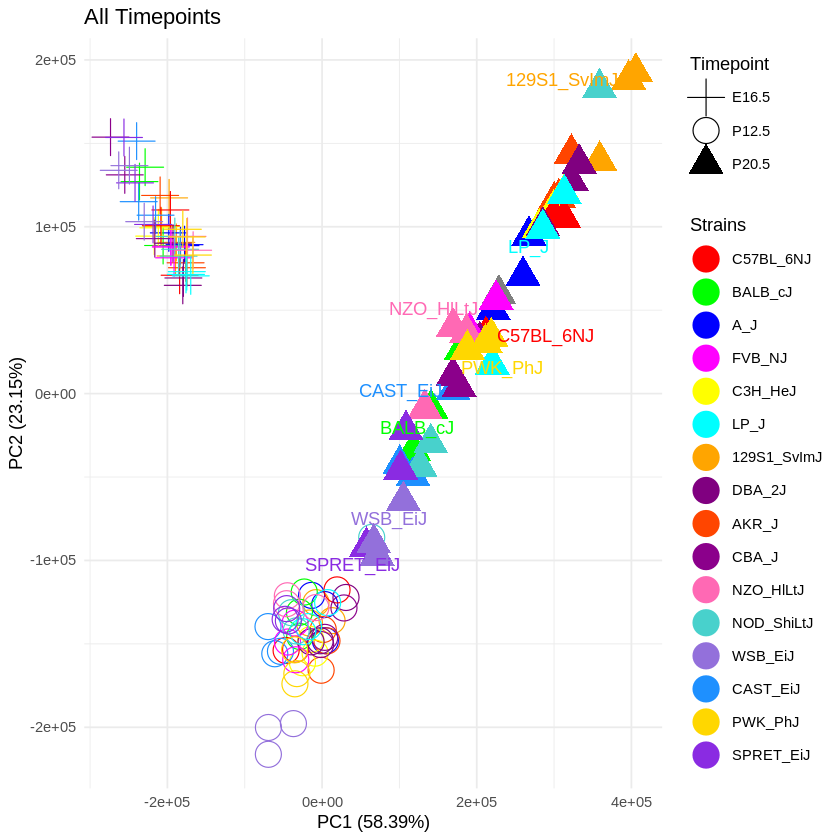

In [ ]:

library(ggforce)
# Create the PCA plot
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point(size = 7) +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + 
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains") 

# Filter the data for specific unique strain values
selected_strains <- c("SPRET_EiJ", "C57BL_6NJ", "WSB_EiJ", "CAST_EiJ", "PWK_PhJ", '129S1_SvImJ', 'BALB_cJ','LP_J','NZO_HlLtJ')
filtered_data <- pca_data %>%
  filter(Shape == "P20.5", Unique_Strains %in% selected_strains)



# Adjust the jitter parameters for better label spacing
jitter_amount <- 4
pca_plot_pc1_pc2 <- pca_plot_pc1_pc2 +
  geom_text_repel(
    data = filtered_data %>% distinct(Unique_Strains, .keep_all = TRUE),
    aes(label = Unique_Strains, color = Unique_Strains),
    nudge_x = 0, nudge_y = 0,  # No need for nudge with jitter
    segment.color = "black",
    segment.size = 0.5,
    #arrow = arrow(type = "closed", angle = 90, length = unit(1, "inches")),
    box.padding = unit(0.4, "lines"),  # Adjust padding around labels
    point.padding = unit(0.2, "lines"),  # Adjust padding around points
    force = 2
  )

# Print the modified PCA plot
print(pca_plot_pc1_pc2)
ggsave("all_timepoint_PC1_PC2.pdf", plot = pca_plot_pc1_pc2, width = 6, height = 7)

TableGrob (3 x 1) "arrange": 3 grobs
  z     cells    name           grob
1 1 (1-1,1-1) arrange gtable[layout]
2 2 (2-2,1-1) arrange gtable[layout]
3 3 (3-3,1-1) arrange gtable[layout]


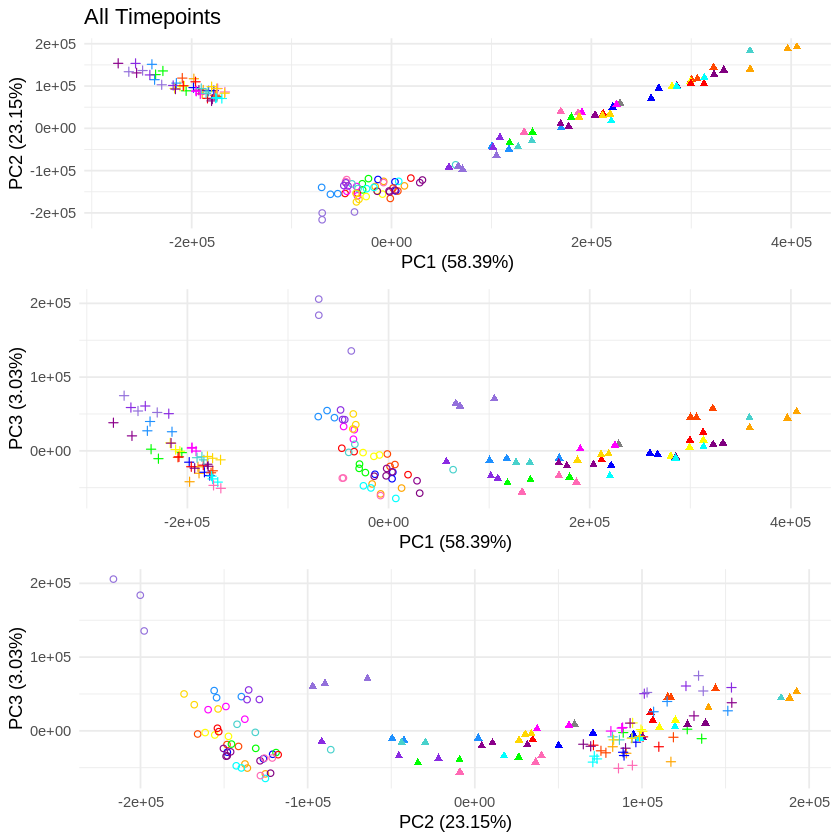

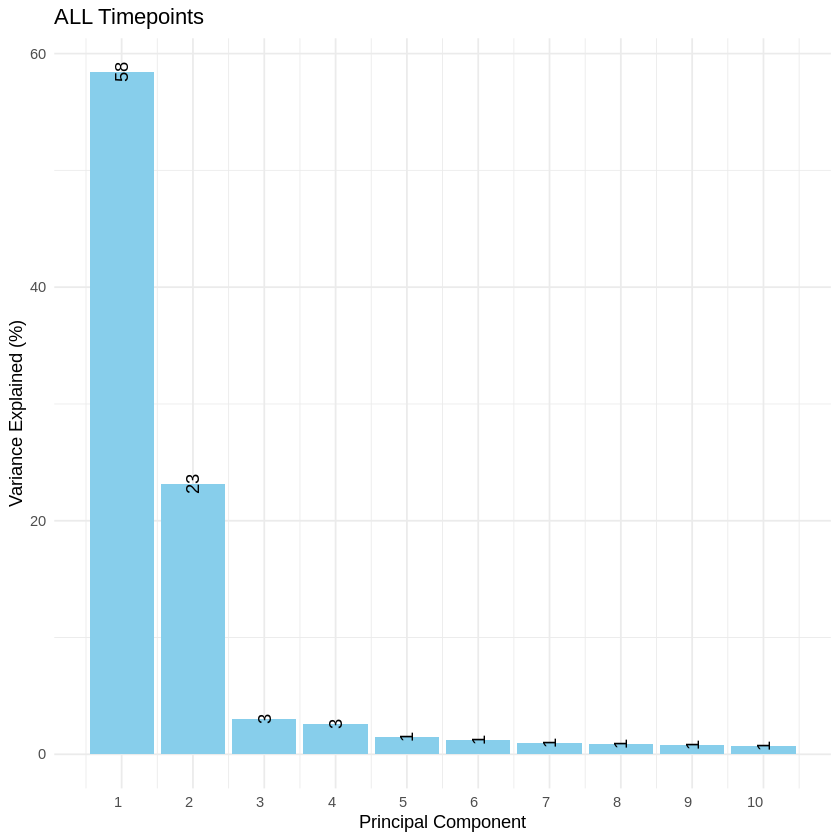

In [ ]:



# Create individual PCA plots with unique colors and shapes for the legend
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  theme(legend.position = "none") 

pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  theme_minimal() +scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  labs(shape = "Timepoint") +
         labs(color = "Strains")  +  theme(legend.position = "none") 



pca_plot_pc2_pc3 <- ggplot(pca_data, aes(x = PC2, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  theme_minimal() +scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  theme(legend.position = "none") 





# Create a custom layout matrix for vertical arrangement
layout_mat <- rbind(c(1), c(2), c(3))
# Define custom widths for each plot
custom_widths <- c(15, 15, 15)  # Adjust these values as needed
custom_heights <- c(3, 3, 3) 

# Create the grid of PCA plots
grid <- grid.arrange(pca_plot_pc1_pc2, pca_plot_pc1_pc3, pca_plot_pc2_pc3,
                     nrow = 3, ncol = 1, layout_matrix = layout_mat, widths = c(0.5), heights = custom_heights)

# Show the grid
print(grid)
# Save the grid as a PDF file
ggsave("All_timepoints_deseq_PCA.pdf", grid, width = 3, height = 5, units = "in")

# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Create a data frame for variance explained by first 10 PCs
variance_df <- data.frame(PC = 1:10, VarianceExplained = variance_explained[1:10])

# Create a bar plot with labels on bars and sky blue color
variance_bar_plot <- ggplot(variance_df, aes(x = PC, y = VarianceExplained, label = round(VarianceExplained, 2))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  geom_text(aes(label = paste(round(VarianceExplained))),vjust = 0.5 , angle = 90, parse = TRUE) +  # Add text labels above the bars
  labs(title = "ALL Timepoints",
       x = "Principal Component", y = "Variance Explained (%)") +
  theme_minimal() +
  scale_x_continuous(breaks = 1:10) +  # Set custom x-axis breaks
  theme(axis.text.x = element_text(angle = 0, hjust = 1))  # Rotate and allow overlap


# Show the bar plot
print(variance_bar_plot)
# Save the bar plot as a PDF file
ggsave("ALL_timepoints_variance_explained_bar_plot.pdf", variance_bar_plot, width = 2, height = 2, units = "in")

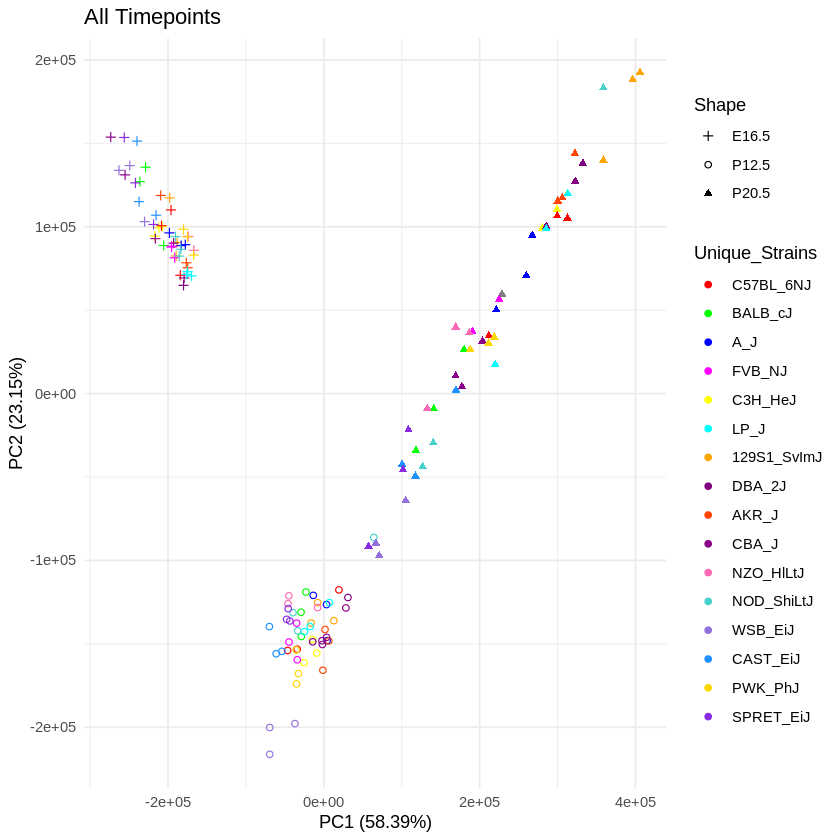

In [ ]:
# Create individual PCA plots with unique colors and shapes for the legend
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) 
pca_plot_pc1_pc2

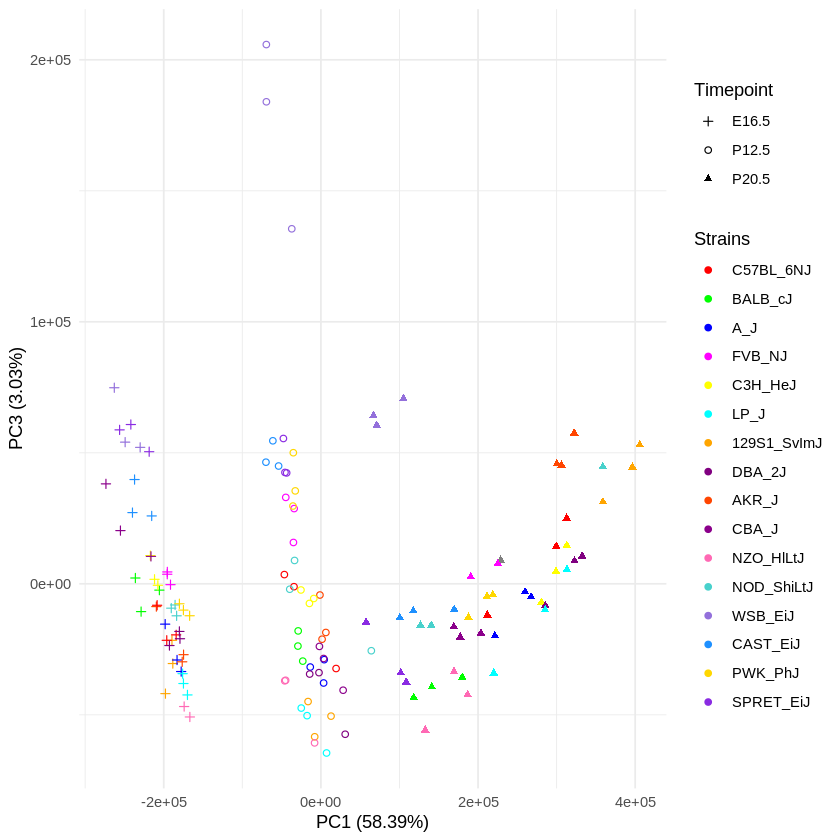

In [ ]:
pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  theme_minimal() +scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  labs(shape = "Timepoint") +
         labs(color = "Strains") 
pca_plot_pc1_pc3 

,Variable
,<chr>
0610007P14Rik,0610007P14Rik
0610009B22Rik,0610009B22Rik
0610010F05Rik,0610010F05Rik
0610010K14Rik,0610010K14Rik
0610037L13Rik,0610037L13Rik
0610040J01Rik,0610040J01Rik
1110002E22Rik,1110002E22Rik
1110004F10Rik,1110004F10Rik
1110008F13Rik,1110008F13Rik


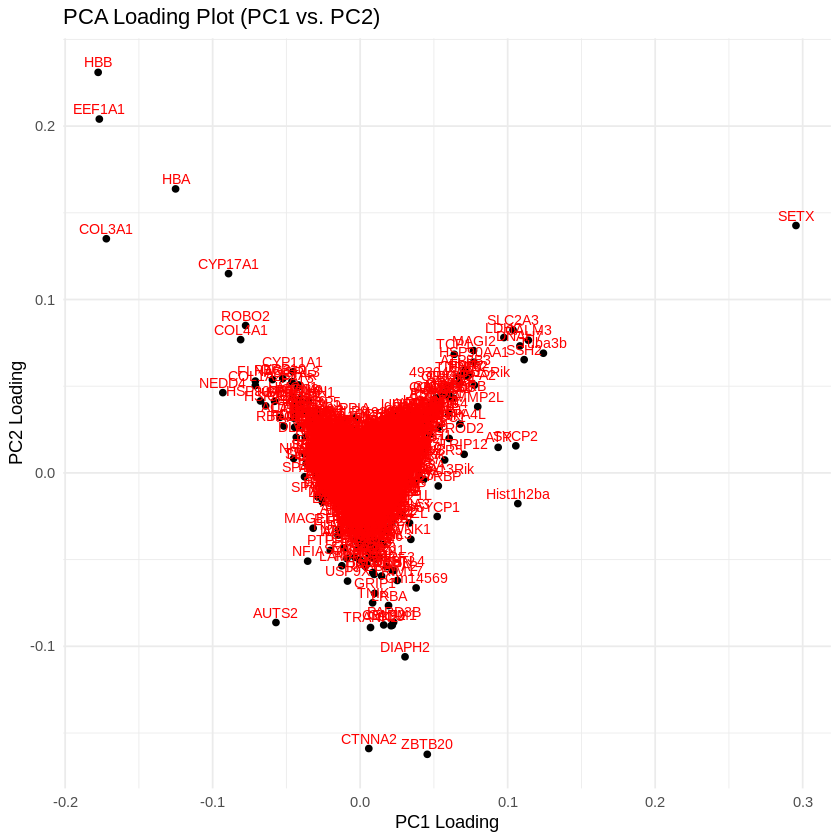

In [ ]:
# Load required libraries
library(ggplot2)



# Perform PCA
pca_result <-  prcomp(t(norm_counts))

# Extract the loadings
loadings <- pca_result$rotation
write.csv(loadings, "all_sample_PCA_loading.csv", row.names=TRUE)
# Calculate the ranking of loadings for each PC
rankings <- apply(loadings, 2, rank)

# Create a data frame for plotting
loadings_df <- data.frame(
  Variable = rownames(loadings),
  PC1 = loadings[, 1],
  PC2 = loadings[, 2],
  Ranking_PC1 = rankings[, 1],
  Ranking_PC2 = rankings[, 2]
)
loadings_df['Variable']
# Sort the data frame by absolute values of PC1 loadings
loadings_df_pc1 <- loadings_df[order(abs(loadings_df$PC1), decreasing = TRUE),]



# Create a scatter plot of PC1 vs. PC2 loadings
ggplot(data = loadings_df, aes(x = PC1, y = PC2, label = Variable)) +
  geom_point() +
  geom_text(vjust = -0.5, size = 3, color = "red") +
  labs(title = "PCA Loading Plot (PC1 vs. PC2)", x = "PC1 Loading", y = "PC2 Loading") +
  theme_minimal()

,Variable
,<chr>
0610007P14Rik,0610007P14Rik
0610009B22Rik,0610009B22Rik
0610010F05Rik,0610010F05Rik
0610010K14Rik,0610010K14Rik
0610037L13Rik,0610037L13Rik
0610040J01Rik,0610040J01Rik
1110002E22Rik,1110002E22Rik
1110004F10Rik,1110004F10Rik
1110008F13Rik,1110008F13Rik


Warning message:
“ggrepel: 17523 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 17494 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


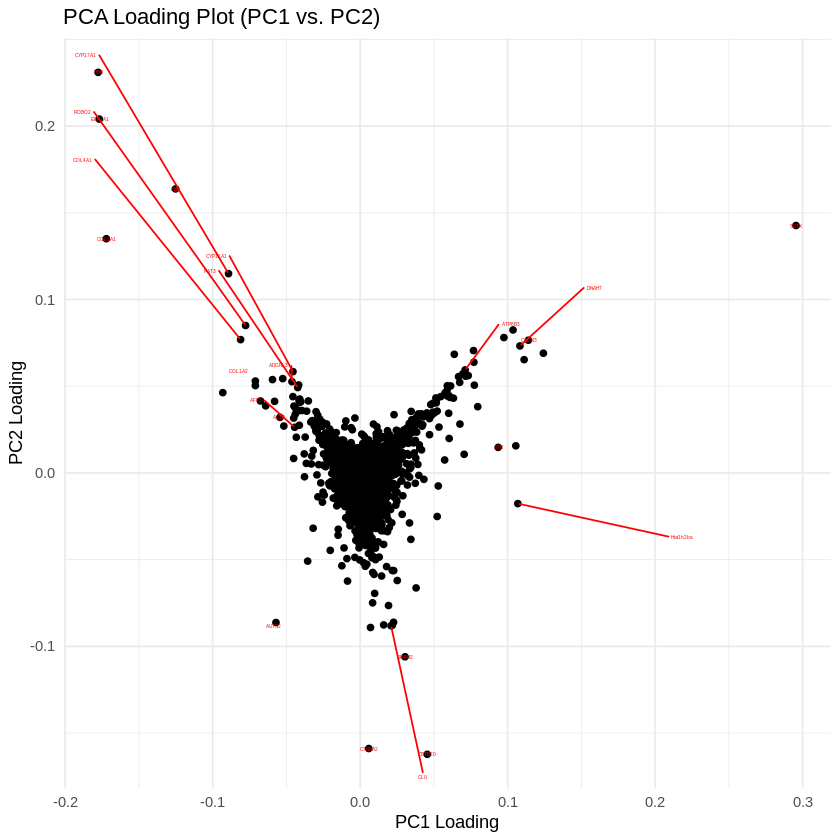

In [ ]:
library(ggrepel)

# Load required libraries
library(ggplot2)



# Perform PCA
pca_result <-  prcomp(t(norm_counts))

# Extract the loadings
loadings <- pca_result$rotation

# Calculate the ranking of loadings for each PC
rankings <- apply(loadings, 2, rank)

# Create a data frame for plotting
loadings_df <- data.frame(
  Variable = rownames(loadings),
  PC1 = loadings[, 1],
  PC2 = loadings[, 2],
  Ranking_PC1 = rankings[, 1],
  Ranking_PC2 = rankings[, 2]
)

loadings_df['Variable']
# Create the scatter plot
plot <- ggplot(data = loadings_df, aes(x = PC1, y = PC2, label = Variable)) +
  geom_point() +
  geom_text_repel(
    size = 1,
    color = "red",
    box.padding = 0.1,
    force = 0.05  # Adjust the force parameter to control label dispersion
  ) +
  labs(title = "PCA Loading Plot (PC1 vs. PC2)", x = "PC1 Loading", y = "PC2 Loading") +
  theme_minimal()
plot
ggsave("all_timepoint_PC1_PC2_loading_full_scale.pdf", plot, width = 10, height =10 , units = "in")

In [ ]:




selected_vars <- c('CTNNA2','SETX','HBB','Dnmt1','Sycp3','Dnmt3a','Dnmt3b','Dnmt3c','Dnmt3l','Meiob','Nanos2','Nanos3','Piwil1', 'Piwil2', 'Piwil4',
'Ddx4','Mael','Gtsf1','Mybl1','Mov10l1','Pld6','Asz1','Henmt1','Tdrd1','Tdrd5','Tdrd6','Tdrd9','Tdrd12', 'Tdrkh','Gpat2','Rnf17','Tcfl5','Tex15','Tex19.1','Tex19.2','Spocd1','Fkbp6')

# Extract loading scores for selected variables
selected_loading_df <- loadings_df[tolower(loadings_df$Variable) %in% tolower(selected_vars), ]
#selected_loading_df <- var.coord 

# Define the groups and their corresponding colors
group_colors <- c(
  'Marker Genes' = "#FF5733",  # Bright Orange
  'Piwi Genes' = "#7C36A3",  # Rich Purple
  'Piwi Pathways Genes' = "#3FA33F"   # Lively Green
)

# Create a new column in the data frame to indicate the group each variable belongs to
selected_loading_df$Group <- NA
selected_loading_df$Group[tolower(selected_loading_df$Variable) %in% tolower(c('Dnmt1','Sycp3','Dnmt3a','Dnmt3b','Dnmt3c','Dnmt3l','Meiob','Nanos2','Nanos3'))] <- 'Marker Genes'
selected_loading_df$Group[tolower(selected_loading_df$Variable) %in% tolower(c('Piwil1', 'Piwil2', 'Piwil4'))] <- 'Piwi Genes'
selected_loading_df$Group[tolower(selected_loading_df$Variable) %in% tolower(c('Ddx4','Mael','Gtsf1','Mybl1','Mov10l1','Pld6','Asz1','Henmt1','Tdrd1','Tdrd5','Tdrd6','Tdrd9','Tdrd12', 'Tdrkh','Gpat2','Rnf17','Tcfl5','Tex15','Tex19.1','Tex19.2','Spocd1','Fkbp6'))] <- 'Piwi Pathways Genes'

# Create the scatter plot with labels and colored groups
plot<- ggplot(data = selected_loading_df, aes(x = PC1, y = PC2, label = Variable, color = Group)) +
  geom_point() +
  geom_text_repel(
    size = 3,
    box.padding = 0.5,
    force = 5,
    segment.color = "black"
  ) +
  labs(title = "PCA Loading Plot (PC1 vs. PC2)", x = "PC1 Loading", y = "PC2 Loading") +
  scale_color_manual(values = group_colors) +  # Set custom colors for groups
  theme_minimal()
ggsave("all_timepoint_PC1_PC2_loading_piwi_full_scale.pdf", plot, width = 10, height =6 , units = "in")

Warning message:
“ggrepel: 29 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


In [ ]:

selected_vars <- c('Dnmt1','Sycp3','Dnmt3a','Dnmt3b','Dnmt3c','Dnmt3l','Meiob','Nanos2','Nanos3','Piwil1', 'Piwil2', 'Piwil4',
'Ddx4','Mael','Gtsf1','Mybl1','Mov10l1','Pld6','Asz1','Henmt1','Tdrd1','Tdrd5','Tdrd6','Tdrd9','Tdrd12', 'Tdrkh','Gpat2','Rnf17','Tcfl5','Tex15','Tex19.1','Tex19.2','Spocd1','Fkbp6')
# Extract loading scores for selected variables
selected_loading_df <- loadings_df[tolower(loadings_df$Variable) %in% tolower(selected_vars), ]
#selected_loading_df <- var.coord 

# Define the groups and their corresponding colors
group_colors <- c(
  'Marker Genes' = "#FF5733",  # Bright Orange
  'Piwi Genes' = "#7C36A3",  # Rich Purple
  'Piwi Pathways Genes' = "#3FA33F"   # Lively Green
)

# Create a new column in the data frame to indicate the group each variable belongs to
selected_loading_df$Group <- NA
selected_loading_df$Group[tolower(selected_loading_df$Variable) %in% tolower(c('Dnmt1','Sycp3','Dnmt3a','Dnmt3b','Dnmt3c','Dnmt3l','Meiob','Nanos2','Nanos3'))] <- 'Marker Genes'
selected_loading_df$Group[tolower(selected_loading_df$Variable) %in% tolower(c('Piwil1', 'Piwil2', 'Piwil4'))] <- 'Piwi Genes'
selected_loading_df$Group[tolower(selected_loading_df$Variable) %in% tolower(c('Ddx4','Mael','Gtsf1','Mybl1','Mov10l1','Pld6','Asz1','Henmt1','Tdrd1','Tdrd5','Tdrd6','Tdrd9','Tdrd12', 'Tdrkh','Gpat2','Rnf17','Tcfl5','Tex15','Tex19.1','Tex19.2','Spocd1','Fkbp6'))] <- 'Piwi Pathways Genes'

# Create the scatter plot with labels and colored groups
plot <- ggplot(data = selected_loading_df, aes(x = PC1, y = PC2, label = Variable, color = Group)) +
  geom_point() +
  geom_text_repel(
    size = 3,
    box.padding = 0.5,
    force = 5,
    segment.color = "black"
  ) +
  labs(title = "PCA Loading Plot (PC1 vs. PC2)", x = "PC1 Loading", y = "PC2 Loading") +
  scale_color_manual(values = group_colors) +  # Set custom colors for groups
  theme_minimal()
ggsave("all_timepoint_PC1_PC2_loading_piwi.pdf", plot, width = 10, height = 6, units = "in")


Warning message:
“ggrepel: 9 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


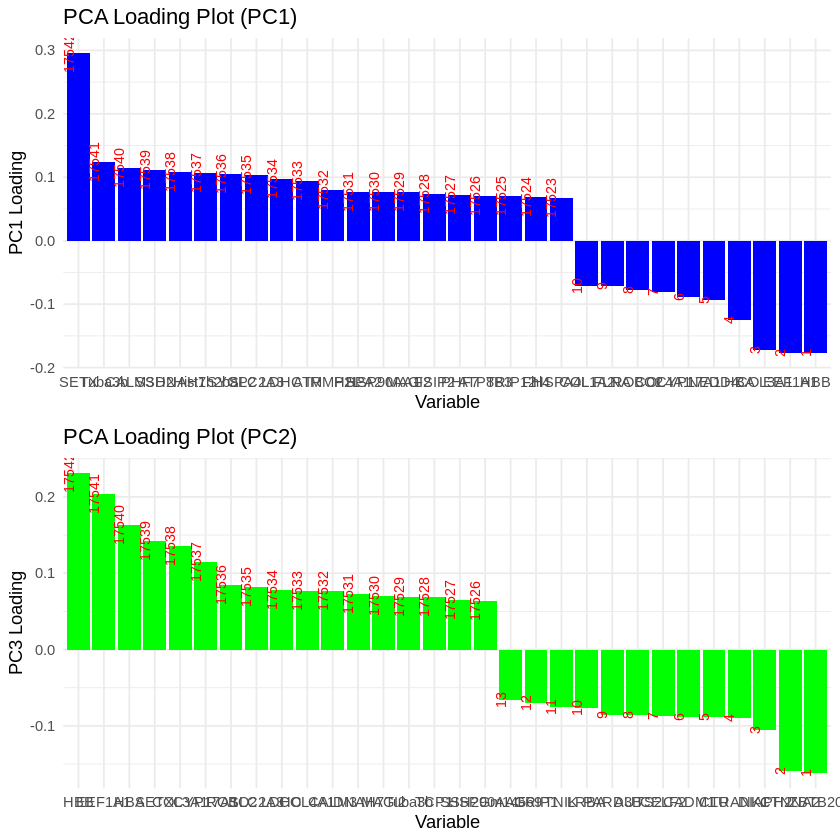

In [ ]:
library(ggplot2)

# Perform PCA
pca_result <-  prcomp(t(norm_counts))

# Extract the loadings
loadings <- pca_result$rotation

# Calculate the ranking of loadings for each PC
rankings <- apply(loadings, 2, rank)

# Create a data frame for plotting
loadings_df <- data.frame(
  Variable = rownames(loadings),
  PC1 = loadings[, 1],
  PC2 = loadings[, 2],
  Ranking_PC1 = rankings[, 1],
  Ranking_PC2 = rankings[, 2]
)
# Sort the data frame by absolute values of PC1 loadings
loadings_df_pc1 <- loadings_df[order(abs(loadings_df$PC1), decreasing = TRUE),]

# Select the top 30 variables for PC1
loadings_df_pc1 <- head(loadings_df_pc1, 30)

# Create a bar plot for PC1 loadings with ranking
plot_pc1 <- ggplot(data = loadings_df_pc1, aes(x = reorder(Variable, -PC1), y = PC1)) +
  geom_bar(stat = "identity", fill = "blue") +
  geom_text(aes(x = Variable, y = PC1, label = Ranking_PC1), vjust = -0.5,angle = 90, size = 3, color = "red") +
  labs(title = "PCA Loading Plot (PC1)", x = "Variable", y = "PC1 Loading") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal()

# Sort the data frame by absolute values of PC2 loadings
loadings_df_pc2 <- loadings_df[order(abs(loadings_df$PC2), decreasing = TRUE),]

# Select the top 30 variables for PC2
loadings_df_pc2 <- head(loadings_df_pc2, 30)

# Create a bar plot for PC2 loadings with ranking
plot_pc2 <- ggplot(data = loadings_df_pc2, aes(x = reorder(Variable, -PC2), y = PC2)) +
  geom_bar(stat = "identity", fill = "green") +
  geom_text(aes(x = Variable, y = PC2, label = Ranking_PC2),angle = 90, vjust = -0.5, size = 3, color = "red") +
  labs(title = "PCA Loading Plot (PC2)", x = "Variable", y = "PC3 Loading") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))+
  theme_minimal()

# Combine the two plots using grid.arrange
grid.arrange(plot_pc1, plot_pc2, ncol = 1)


In [ ]:
# Create individual PCA plots with unique colors and shapes for the legend
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color =Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains") 
ggsave("ALL_timepoints_P1_vs_PC2.pdf", pca_plot_pc1_pc2, width = 10, height = 10, units = "in")

Warning message in geom_text_repel(data = filtered_data %>% distinct(Unique_Strains, :
“Ignoring unknown parameters: `jitter`”


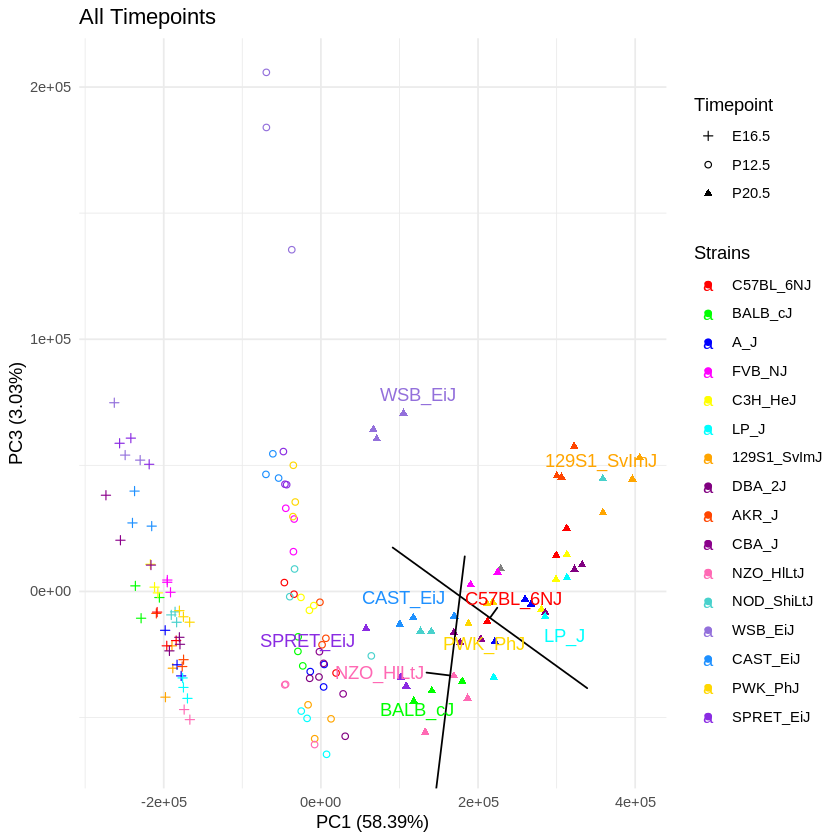

In [ ]:
library(dplyr)


pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
 geom_point() +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  theme_minimal() + 
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains") 

# Filter the data for specific unique strain values
selected_strains <- c("SPRET_EiJ", "C57BL_6NJ", "WSB_EiJ", "CAST_EiJ", "PWK_PhJ", '129S1_SvImJ', 'BALB_cJ','LP_J','NZO_HlLtJ')
filtered_data <- pca_data %>%
  filter(Shape == "P20.5", Unique_Strains %in% selected_strains)



# Adjust the jitter parameters for better label spacing
jitter_amount <- 4

pca_plot_pc1_pc3 <- pca_plot_pc1_pc3 +geom_text_repel(
    data = filtered_data %>% distinct(Unique_Strains, .keep_all = TRUE),
    aes(label = Unique_Strains, color = Unique_Strains),
    nudge_x = 5, nudge_y = 5,  # No need for nudge with jitter
    segment.color = "black",
    segment.size = 0.5,
    arrow = arrow(type = "closed", angle = 90, length = unit(1, "inches")),
    box.padding = unit(0.4, "lines"),  # Adjust padding around labels
    point.padding = unit(0.2, "lines"),  # Adjust padding around points
    jitter = jitter_amount,force=5
  )
pca_plot_pc1_pc3

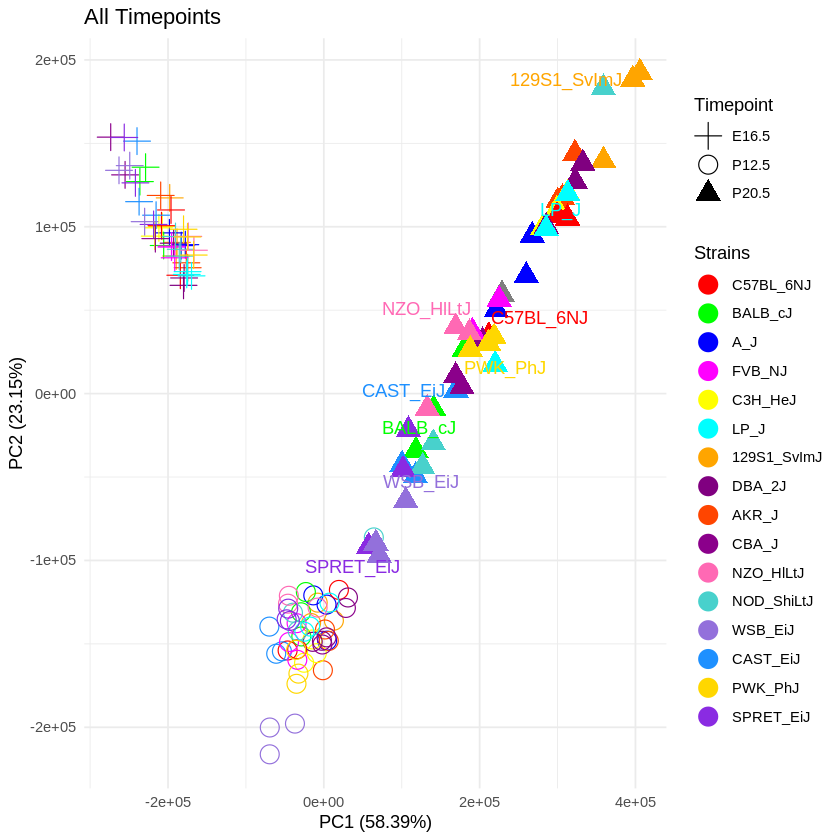

In [ ]:

library(ggforce)
# Create the PCA plot
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point(size = 5) +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + 
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains") 

# Filter the data for specific unique strain values
selected_strains <- c("SPRET_EiJ", "C57BL_6NJ", "WSB_EiJ", "CAST_EiJ", "PWK_PhJ", '129S1_SvImJ', 'BALB_cJ','LP_J','NZO_HlLtJ')
filtered_data <- pca_data %>%
  filter(Shape == "P20.5", Unique_Strains %in% selected_strains)



# Adjust the jitter parameters for better label spacing
jitter_amount <- 4
pca_plot_pc1_pc2 <- pca_plot_pc1_pc2 +
  geom_text_repel(
    data = filtered_data %>% distinct(Unique_Strains, .keep_all = TRUE),
    aes(label = Unique_Strains, color = Unique_Strains),
    nudge_x = 0, nudge_y = 0,  # No need for nudge with jitter
    segment.color = "black",
    segment.size = 0.5,
    #arrow = arrow(type = "closed", angle = 90, length = unit(1, "inches")),
    box.padding = unit(0.4, "lines"),  # Adjust padding around labels
    point.padding = unit(0.2, "lines"),  # Adjust padding around points
    force = 10
  )

# Print the modified PCA plot
print(pca_plot_pc1_pc2)
ggsave("all_timepoint_PC1_PC2.pdf", plot = pca_plot_pc1_pc2, width = 20, height = 20)

Warning message in geom_label_repel(data = filtered_data %>% distinct(Unique_Strains, :
“Ignoring unknown parameters: `label.box`”


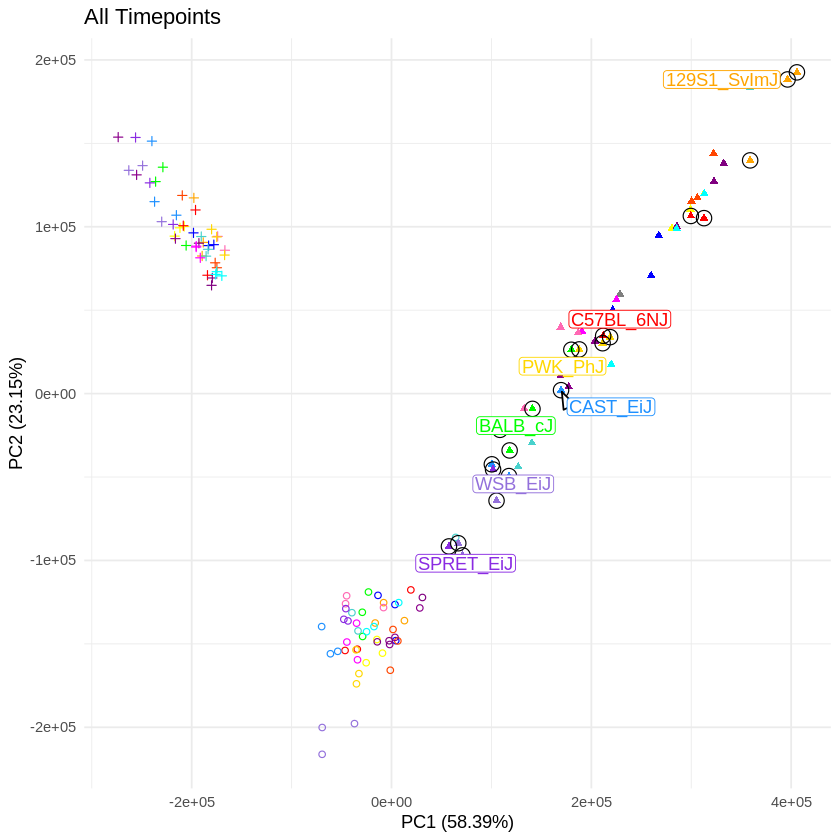

In [ ]:
# Create the PCA plot
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + 
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains") + 
  theme(legend.position = "none") 

# Filter the data for specific unique strain values
selected_strains <- c("SPRET_EiJ", "C57BL_6NJ", "WSB_EiJ", "CAST_EiJ", "PWK_PhJ",'129S1_SvImJ','BALB_cJ')
filtered_data <- pca_data %>%
  filter(Shape == "P20.5", Unique_Strains %in% selected_strains)

# Create the PCA plot with labeled selected strains and wrapped labels
pca_plot_pc1_pc2 <- pca_plot_pc1_pc2 +
  geom_point(data = filtered_data, shape = 1, size = 4, color = "black") +
  geom_label_repel(
    data = filtered_data %>% distinct(Unique_Strains, .keep_all = TRUE),  # Keep only one instance of each strain
    aes(label = Unique_Strains),
    nudge_x = 0.4,  # Adjust the label positions slightly
    segment.color = "black", 
    arrow = arrow(type = "closed", angle = 20, length = unit(0.15, "inches")),
    label.padding = unit(0.1, "lines"),  # Adjust the padding around the label
    label.box = "bottom"  # Place the label in a box below the point
  ) +
  guides(values = guide_legend(override.aes = list(values = 1)))

# Print the modified PCA plot
print(pca_plot_pc1_pc2)


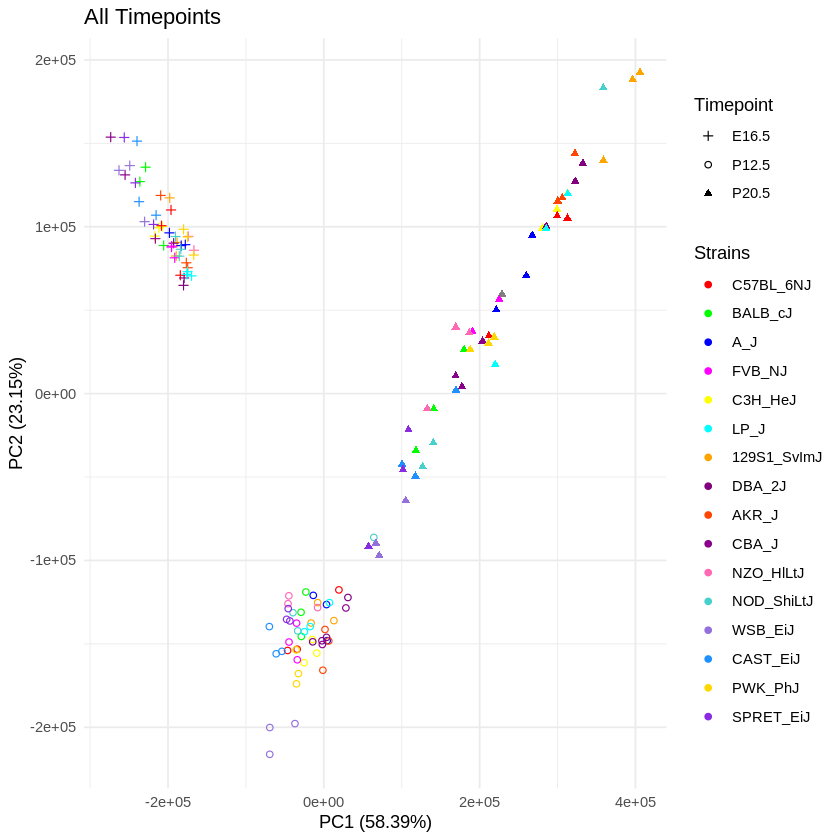

In [ ]:
library(ggplot2)
# Create individual PCA plots with unique colors and shapes for the legend
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  labs(shape = "Timepoint") +
         labs(color = "Strains") 
pca_plot_pc1_pc2

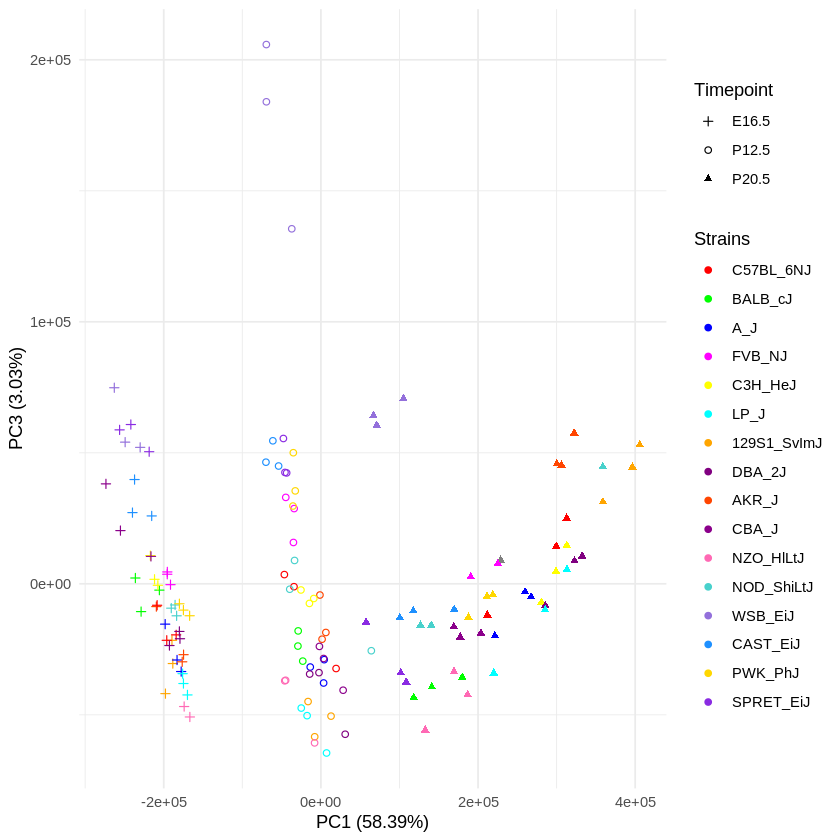

In [ ]:
pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
       scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  labs(shape = "Timepoint") +
         labs(color = "Strains") +
      theme_minimal() 
pca_plot_pc1_pc3

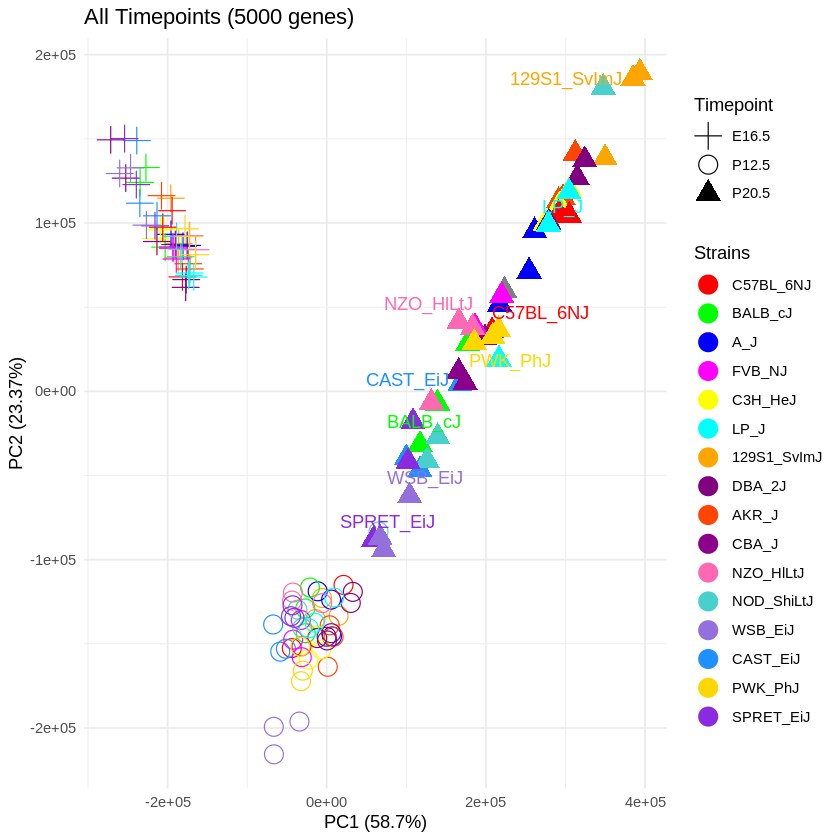

In [ ]:
library(edgeR)
library(ggplot2)
library(gridExtra)

# Calculate the row-wise variance and order rows by variance
#row_variances <- apply(norm_counts, 1, var)
#top_variants <- names(sort(row_variances, decreasing = TRUE))[1:500] #top 500 
#subset_norm_counts <- norm_counts[top_variants, ]


# Calculate the row-wise sum and order rows by sum
row_sums <- apply(norm_counts, 1, sum)
top_sums <- names(sort(row_sums, decreasing = TRUE))[1:5000] #top 500 
subset_norm_counts <- norm_counts[top_sums, ]
# Perform PCA on the subsetted data
pca <- prcomp(t(subset_norm_counts))

# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100






# Create a data frame for PCA results and variance explained
pca_data <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], PC3 = pca$x[, 3], Strains = samplenames,
                       Variance_PC1 = variance_explained[1], Variance_PC2 = variance_explained[2], Variance_PC3 = variance_explained[3])

# Create individual PCA plots with unique colors
  # Create a new column 'Shape' based on the sample names
pca_data$Shape <- ifelse(grepl("12.5", pca_data$Strains ), "P12.5",
            ifelse(grepl("16.5", pca_data$Strains ), "E16.5",
                   ifelse(grepl("20.5", pca_data$Strains ), "P20.5", "D")))
# Extract unique strain names from the "Strains" column
pca_data$Unique_Strains <- sapply(strsplit(pca_data$Strains, "-"), function(x) x[1])


library(ggforce)
# Create the PCA plot
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point(size = 5) +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints (5000 genes)", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + 
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains") 

# Filter the data for specific unique strain values
selected_strains <- c("SPRET_EiJ", "C57BL_6NJ", "WSB_EiJ", "CAST_EiJ", "PWK_PhJ", '129S1_SvImJ', 'BALB_cJ','LP_J','NZO_HlLtJ')
filtered_data <- pca_data %>%
  filter(Shape == "P20.5", Unique_Strains %in% selected_strains)



# Adjust the jitter parameters for better label spacing
jitter_amount <- 4
pca_plot_pc1_pc2 <- pca_plot_pc1_pc2 +
  geom_text_repel(
    data = filtered_data %>% distinct(Unique_Strains, .keep_all = TRUE),
    aes(label = Unique_Strains, color = Unique_Strains),
    nudge_x = 0, nudge_y = 0,  # No need for nudge with jitter
    segment.color = "black",
    segment.size = 0.5,
    #arrow = arrow(type = "closed", angle = 90, length = unit(1, "inches")),
    box.padding = unit(0.4, "lines"),  # Adjust padding around labels
    point.padding = unit(0.2, "lines"),  # Adjust padding around points
    force = 10
  )

# Print the modified PCA plot
print(pca_plot_pc1_pc2)
ggsave("all_timepoint_PC1_PC2_1000_expresed.pdf", plot = pca_plot_pc1_pc2, width = 6, height = 6)

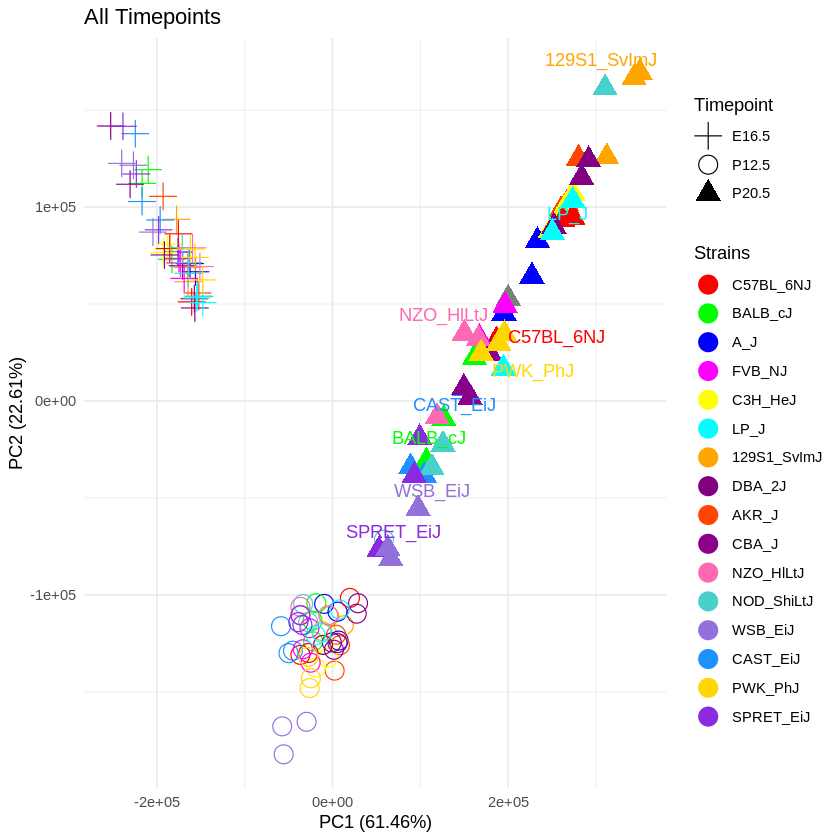

In [ ]:
library(edgeR)
library(ggplot2)
library(gridExtra)

# Calculate the row-wise variance and order rows by variance
row_variances <- apply(norm_counts, 1, var)
top_variants <- names(sort(row_variances, decreasing = TRUE))[1:500] #top 500 
subset_norm_counts <- norm_counts[top_variants, ]


# Calculate the row-wise sum and order rows by sum
#row_sums <- apply(norm_counts, 1, sum)
#top_sums <- names(sort(row_sums, decreasing = TRUE))[1:500] #top 500 
#subset_norm_counts <- norm_counts[top_sums, ]
# Perform PCA on the subsetted data
pca <- prcomp(t(subset_norm_counts))

# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100






# Create a data frame for PCA results and variance explained
pca_data <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], PC3 = pca$x[, 3], Strains = samplenames,
                       Variance_PC1 = variance_explained[1], Variance_PC2 = variance_explained[2], Variance_PC3 = variance_explained[3])

# Create individual PCA plots with unique colors
  # Create a new column 'Shape' based on the sample names
pca_data$Shape <- ifelse(grepl("12.5", pca_data$Strains ), "P12.5",
            ifelse(grepl("16.5", pca_data$Strains ), "E16.5",
                   ifelse(grepl("20.5", pca_data$Strains ), "P20.5", "D")))
# Extract unique strain names from the "Strains" column
pca_data$Unique_Strains <- sapply(strsplit(pca_data$Strains, "-"), function(x) x[1])


library(ggforce)
# Create the PCA plot
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point(size = 5) +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + 
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains") 

# Filter the data for specific unique strain values
selected_strains <- c("SPRET_EiJ", "C57BL_6NJ", "WSB_EiJ", "CAST_EiJ", "PWK_PhJ", '129S1_SvImJ', 'BALB_cJ','LP_J','NZO_HlLtJ')
filtered_data <- pca_data %>%
  filter(Shape == "P20.5", Unique_Strains %in% selected_strains)



# Adjust the jitter parameters for better label spacing
jitter_amount <- 4
pca_plot_pc1_pc2 <- pca_plot_pc1_pc2 +
  geom_text_repel(
    data = filtered_data %>% distinct(Unique_Strains, .keep_all = TRUE),
    aes(label = Unique_Strains, color = Unique_Strains),
    nudge_x = 0, nudge_y = 0,  # No need for nudge with jitter
    segment.color = "black",
    segment.size = 0.5,
    #arrow = arrow(type = "closed", angle = 90, length = unit(1, "inches")),
    box.padding = unit(0.4, "lines"),  # Adjust padding around labels
    point.padding = unit(0.2, "lines"),  # Adjust padding around points
    force = 10
  )

# Print the modified PCA plot
print(pca_plot_pc1_pc2)
ggsave("all_timepoint_PC1_PC2_500_var.pdf", plot = pca_plot_pc1_pc2, width = 10, height = 10)

TableGrob (3 x 1) "arrange": 3 grobs
  z     cells    name           grob
1 1 (1-1,1-1) arrange gtable[layout]
2 2 (2-2,1-1) arrange gtable[layout]
3 3 (3-3,1-1) arrange gtable[layout]


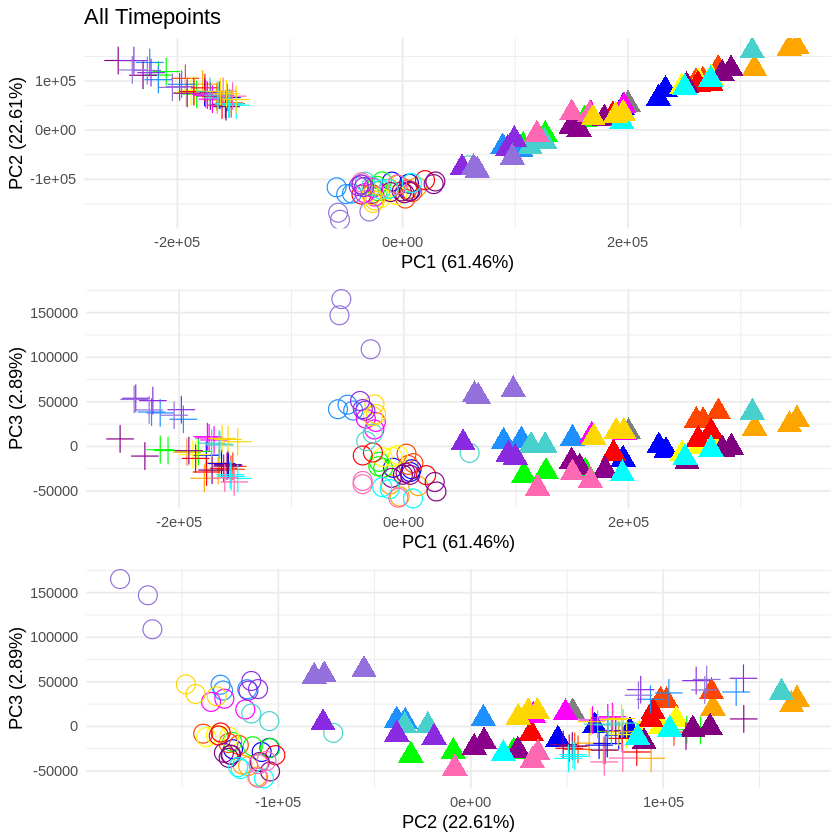

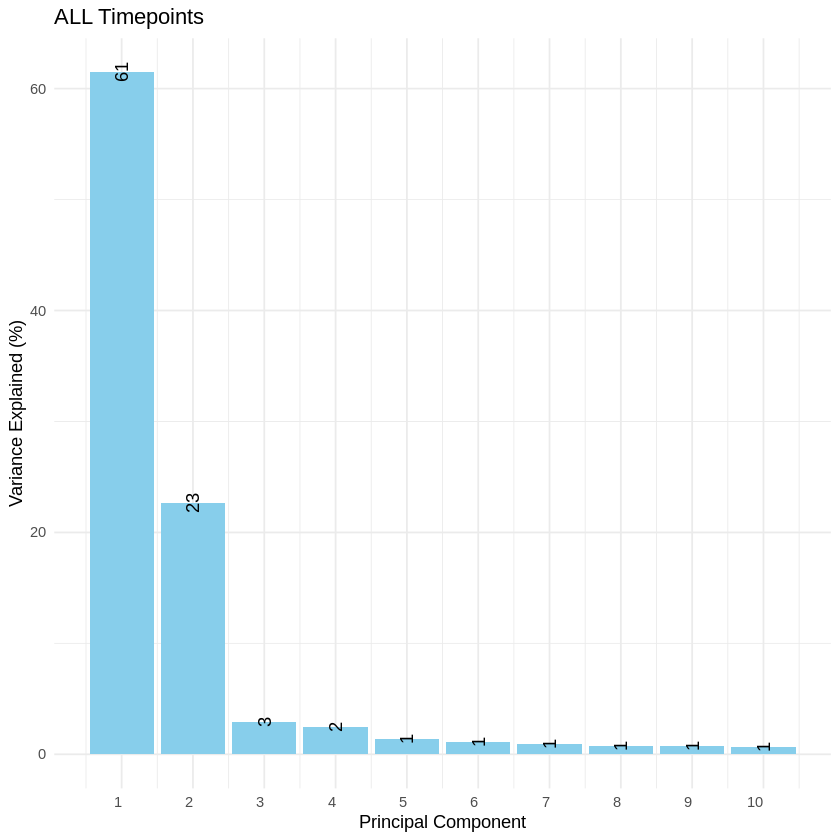

In [ ]:



# Create individual PCA plots with unique colors and shapes for the legend
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point(size = 5) +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  theme(legend.position = "none") 

pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point(size = 5) +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  theme_minimal() +scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  theme(legend.position = "none") 


pca_plot_pc2_pc3 <- ggplot(pca_data, aes(x = PC2, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point(size = 5) +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  theme_minimal() +scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  theme(legend.position = "none") 



# Create a custom layout matrix for vertical arrangement
layout_mat <- rbind(c(1), c(2), c(3))
# Define custom widths for each plot
custom_widths <- c(15, 15, 15)  # Adjust these values as needed
custom_heights <- c(3, 3, 3) 

# Create the grid of PCA plots
grid <- grid.arrange(pca_plot_pc1_pc2, pca_plot_pc1_pc3, pca_plot_pc2_pc3,
                     nrow = 3, ncol = 1, layout_matrix = layout_mat, widths = c(0.5), heights = custom_heights)

# Show the grid
print(grid)
# Save the grid as a PDF file
ggsave("All_timepoints_edgeR_PCA_500.pdf", grid, width = 3, height = 5, units = "in")

# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Create a data frame for variance explained by first 10 PCs
variance_df <- data.frame(PC = 1:10, VarianceExplained = variance_explained[1:10])

# Create a bar plot with labels on bars and sky blue color
variance_bar_plot <- ggplot(variance_df, aes(x = PC, y = VarianceExplained, label = round(VarianceExplained, 2))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  geom_text(aes(label = paste(round(VarianceExplained))),vjust = 0.5 , angle = 90, parse = TRUE) +  # Add text labels above the bars
  labs(title = "ALL Timepoints",
       x = "Principal Component", y = "Variance Explained (%)") +
  theme_minimal() +
  scale_x_continuous(breaks = 1:10) +  # Set custom x-axis breaks
  theme(axis.text.x = element_text(angle = 0, hjust = 1))  # Rotate and allow overlap


# Show the bar plot
print(variance_bar_plot)
# Save the bar plot as a PDF file
ggsave("ALL_timepoints_variance_explained_bar_plot_500.pdf", variance_bar_plot, width = 3, height = 4, units = "in")

In [ ]:
colnames(rawdata_copy$counts)

[1] "129S1_SvImJ-P12.5.1" "129S1_SvImJ-P12.5.2" "129S1_SvImJ-P12.5.3"
  [4] "129S1_SvImJ-E16.5.1" "129S1_SvImJ-E16.5.2" "129S1_SvImJ-E16.5.3"
  [7] "129S1_SvImJ-P20.5.1" "129S1_SvImJ-P20.5.2" "129S1_SvImJ-P20.5.3"
 [10] "A_J-P12.5.1"         "A_J-P12.5.2"         "A_J-P12.5.3"        
 [13] "A_J-E16.5.1"         "A_J-E16.5.2"         "A_J-E16.5.3"        
 [16] "A_J-P20.5.1"         "A_J-P20.5.2"         "A_J-P20.5.3"        
 [19] "AKR_J-P12.5.1"       "AKR_J-P12.5.2"       "AKR_J-P12.5.3"      
 [22] "AKR_J-E16.5.1"       "AKR_J-E16.5.2"       "AKR_J-E16.5.3"      
 [25] "AKR_J-P20.5.1"       "AKR_J-P20.5.2"       "AKR_J-P20.5.3"      
 [28] "BALB_cJ-P12.5.1"     "BALB_cJ-P12.5.2"     "BALB_cJ-P12.5.3"    
 [31] "BALB_cJ-E16.5.1"     "BALB_cJ-E16.5.2"     "BALB_cJ-E16.5.3"    
 [34] "BALB_cJ-P20.5.1"     "BALB_cJ-P20.5.2"     "BALB_cJ-P20.5.3"    
 [37] "C3H_HeJ-P12.5.1"     "C3H_HeJ-P12.5.2"     "C3H_HeJ-P12.5.3"    
 [40] "C3H_HeJ-E16.5.1"     "C3H_HeJ-E16.5.2"     "C3H_HeJ-E16.5.3"    
 [43] "C3H_HeJ-P20.5.1"     "C3H_HeJ-P20.5.2"     "C3H_HeJ-P20.5.3"    
 [46] "C57BL_6NJ-P12.5.1"   "C57BL_6NJ-P12.5.2"   "C57BL_6NJ-P12.5.3"  
 [49] "C57BL_6NJ-E16.5.1"   "C57BL_6NJ-E16.5.2"   "C57BL_6NJ-E16.5.3"  
 [52] "C57BL_6NJ-P20.5.1"   "C57BL_6NJ-P20.5.2"   "C57BL_6NJ-P20.5.3"  
 [55] "CAST_EiJ-P12.5.1"    "CAST_EiJ-P12.5.2"    "CAST_EiJ-P12.5.3"   
 [58] "CAST_EiJ-E16.5.1"    "CAST_EiJ-E16.5.2"    "CAST_EiJ-E16.5.3"   
 [61] "CAST_EiJ-P20.5.1"    "CAST_EiJ-P20.5.2"    "CAST_EiJ-P20.5.3"   
 [64] "CBA_J-P12.5.1"       "CBA_J-P12.5.2"       "CBA_J-P12.5.3"      
 [67] "CBA_J-E16.5.1"       "CBA_J-E16.5.2"       "CBA_J-E16.5.3"      
 [70] "CBA_J-P20.5.1"       "CBA_J-P20.5.2"       "CBA_J-P20.5.3"      
 [73] "DBA_2J-P12.5.1"      "DBA_2J-P12.5.2"      "DBA_2J-P12.5.3"     
 [76] "DBA_2J-E16.5.1"      "DBA_2J-E16.5.2"      "DBA_2J-E16.5.3"     
 [79] "DBA_2J-P20.5.1"      "DBA_2J-P20.5.2"      "DBA_2J-P20.5.3"     
 [82] "FVB_NJ-P12.5.1"      "FVB_NJ-P12.5.2"      "FVB_NJ-P12.5.3"     
 [85] "FVB_NJ-E16.5.1"      "FVB_NJ-E16.5.2"      "FVB_NJ-E16.5.3"     
 [88] "FVB_NJ-P20.5.1"      "FVB_NJ-P20.5.2"      "FVB_NJ-P20.5.3"     
 [91] "LP_J-P12.5.1"        "LP_J-P12.5.2"        "LP_J-P12.5.3"       
 [94] "LP_J-E16.5.1"        "LP_J-E16.5.2"        "LP_J-E16.5.3"       
 [97] "LP_J-P20.5.1"        "LP_J-P20.5.2"        "LP_J-P20.5.3"       
[100] "NOD_ShiLtJ-P12.5.1"  "NOD_ShiLtJ-P12.5.2"  "NOD_ShiLtJ-P12.5.3" 
[103] "NOD_ShiLtJ-E16.5.1"  "NOD_ShiLtJ-E16.5.2"  "NOD_ShiLtJ-E16.5.3" 
[106] "NOD_ShiLtJ-P20.5.1"  "NOD_ShiLtJ-P20.5.2"  "NOD_ShiLtJ-P20.5.3" 
[109] "NZO_HlLtJ-P12.5.1"   "NZO_HlLtJ-P12.5.2"   "NZO_HlLtJ-P12.5.3"  
[112] "NZO_HlLtJ-E16.5.1"   "NZO_HlLtJ-E16.5.3"   "NZO_HlLtJ-P20.5.1"  
[115] "NZO_HlLtJ-P20.5.2"   "NZO_HlLtJ-P20.5.3"   "PWK_PhJ-P12.5.1"    
[118] "PWK_PhJ-P12.5.2"     "PWK_PhJ-P12.5.3"     "PWK_PhJ-E16.5.1"    
[121] "PWK_PhJ-E16.5.2"     "PWK_PhJ-E16.5.3"     "PWK_PhJ-P20.5.1"    
[124] "PWK_PhJ-P20.5.2"     "PWK_PhJ-P20.5.3"     "SPRET_EiJ-P12.5.1"  
[127] "SPRET_EiJ-P12.5.2"   "SPRET_EiJ-P12.5.3"   "SPRET_EiJ-E16.5.1"  
[130] "SPRET_EiJ-E16.5.2"   "SPRET_EiJ-E16.5.3"   "SPRET_EiJ-P20.5.1"  
[133] "SPRET_EiJ-P20.5.2"   "SPRET_EiJ-P20.5.3"   "WSB_EiJ-P12.5.1"    
[136] "WSB_EiJ-P12.5.2"     "WSB_EiJ-P12.5.3"     "WSB_EiJ-E16.5.1"    
[139] "WSB_EiJ-E16.5.2"     "WSB_EiJ-E16.5.3"     "WSB_EiJ-P20.5.1"    
[142] "WSB_EiJ-P20.5.2"     "WSB_EiJ-P20.5.3"

In [ ]:


pairwise_combinations <- list(
  # E16.5 vs P12.5
  c('sample', 'C57BL_6NJ-E16.5', 'C57BL_6NJ-P12.5'),
  c('sample', 'BALB_cJ-E16.5', 'BALB_cJ-P12.5'),
  c('sample', 'A_J-E16.5', 'A_J-P12.5'),
  c('sample', 'FVB_NJ-E16.5', 'FVB_NJ-P12.5'),
  c('sample', 'C3H_HeJ-E16.5', 'C3H_HeJ-P12.5'),
  c('sample', 'LP_J-E16.5', 'LP_J-P12.5'),
  c('sample', '129S1_SvImJ-E16.5', '129S1_SvImJ-P12.5'),
  c('sample', 'DBA_2J-E16.5', 'DBA_2J-P12.5'),
  c('sample', 'AKR_J-E16.5', 'AKR_J-P12.5'),
  c('sample', 'CBA_J-E16.5', 'CBA_J-P12.5'),
  c('sample', 'NZO_HlLtJ-E16.5', 'NZO_HlLtJ-P12.5'),
  c('sample', 'NOD_ShiLtJ-E16.5', 'NOD_ShiLtJ-P12.5'),
  c('sample', 'WSB_EiJ-E16.5', 'WSB_EiJ-P12.5'),
  c('sample', 'CAST_EiJ-E16.5', 'CAST_EiJ-P12.5'),
  c('sample', 'PWK_PhJ-E16.5', 'PWK_PhJ-P12.5'),
  c('sample', 'SPRET_EiJ-E16.5', 'SPRET_EiJ-P12.5'),
  
  # P12.5 vs P20.5
  c('sample', 'C57BL_6NJ-P12.5', 'C57BL_6NJ-P20.5'),
  c('sample', 'BALB_cJ-P12.5', 'BALB_cJ-P20.5'),
  c('sample', 'A_J-P12.5', 'A_J-P20.5'),
  c('sample', 'FVB_NJ-P12.5', 'FVB_NJ-P20.5'),
  c('sample', 'C3H_HeJ-P12.5', 'C3H_HeJ-P20.5'),
  c('sample', 'LP_J-P12.5', 'LP_J-P20.5'),
  c('sample', '129S1_SvImJ-P12.5', '129S1_SvImJ-P20.5'),
  c('sample', 'DBA_2J-P12.5', 'DBA_2J-P20.5'),
  c('sample', 'AKR_J-P12.5', 'AKR_J-P20.5'),
  c('sample', 'CBA_J-P12.5', 'CBA_J-P20.5'),
  c('sample', 'NZO_HlLtJ-P12.5', 'NZO_HlLtJ-P20.5'),
  c('sample', 'NOD_ShiLtJ-P12.5', 'NOD_ShiLtJ-P20.5'),
  c('sample', 'WSB_EiJ-P12.5', 'WSB_EiJ-P20.5'),
  c('sample', 'CAST_EiJ-P12.5', 'CAST_EiJ-P20.5'),
  c('sample', 'PWK_PhJ-P12.5', 'PWK_PhJ-P20.5'),
  c('sample', 'SPRET_EiJ-P12.5', 'SPRET_EiJ-P20.5')
)

# Load required libraries
library(foreach)
library(doParallel)
library(EnhancedVolcano)  # Make sure you have this package installed

# Create a directory to save the plots
if (!dir.exists("volcano_plots")) {
    dir.create("volcano_plots")
}
# Combine results from all comparisons

library(edgeR)
library(EnhancedVolcano)
library(tidyverse)
library(DESeq2)
library(ggrepel)
library(kableExtra)

# Combine results from all comparisons
all_results <- data.frame()

# Loop through pairwise combinations
for (pair in pairwise_combinations) {
  condition1 <- pair[2]
  condition2 <- pair[3]
  
res <- results(cds, contrast = pair)
#res <- results(cds, contrast = c('sample', 'C57BL_6NJ-P20.5', 'BALB_cJ-P20.5'))
res

data <- data.frame(Genes = rownames(res),
                    logFC = res$log2FoldChange,
                     FDR = res$padj,
                     PValue = res$pvalue)

data <- data %>% 
    mutate(
      Expression = case_when(logFC >= log(2) & FDR <= 0.01 ~ "Up-regulated",
                            logFC <= -log(2) & FDR <= 0.01 ~ "Down-regulated",
                            TRUE ~ "Unchanged")
      )
data <- data %>% 
      mutate(
        Significance = case_when(
          abs(logFC) >= log(2) & FDR <= 0.05 & FDR > 0.01 ~ "FDR 0.05", 
          abs(logFC) >= log(2) & FDR <= 0.01 & FDR > 0.01 ~ "FDR 0.01",
          abs(logFC) >= log(2) & FDR <= 0.01 ~ "FDR 0.01", 
          TRUE ~ "Unchanged")
      )


all_genes <- bind_rows(
      data %>% 
        filter(Expression == 'Up-regulated') %>% 
        arrange(FDR, desc(abs(logFC))),
      data %>% 
        filter(Expression == 'Down-regulated') %>% 
        arrange(FDR, desc(abs(logFC))) 
    )


comparison_name <- paste(condition1, "_vs_", condition2, sep = "")
all_results <- rbind(all_results, data.frame(Comparison = comparison_name,
                                                Expression = all_genes$Expression,
                                                Significance = all_genes$Significance,
                                                Genes = all_genes$Genes))
p2 <- ggplot(data, aes(logFC, -log(FDR,10))) +
      geom_point(aes(color = Expression), size = 2/5) +
      xlab(expression("log"[2]*"FC")) + 
      ylab(expression("-log"[10]*"FDR")) +
      scale_color_manual(values = c("dodgerblue3", "gray50", "firebrick3")) +
      guides(colour = guide_legend(override.aes = list(size=1.5)))  + theme_minimal()
p2 <-  p2 +
      geom_label_repel(
    data = all_genes[1:5,],
    mapping = aes(logFC, -log(FDR, 10), label = Genes),
    size = 2,
    box.padding = 0.2,
    point.padding = 0.5,
    segment.color = "grey50",
    segment.size = 0.5,
    box.draw = FALSE,  # Remove the box around labels
    label.size = NA,  # Show only the label text without background
    label.background = aes(fill = NA)  # Set the label background to transparent
  ) +
  theme(plot.title = element_text(hjust = 0.7))  +  # Center the plot title
  ggtitle(paste("vs", condition2))
 # Save the plot as a PDF file
    pdf(paste("volcano_plots/", condition1, "_vs_", condition2, "_up_down_volcano_plot.pdf", sep = ""), width = 3, height = 3)  # Adjust width and height as needed
    print(p2)
    dev.off()  # Close the PDF device

p3 <- ggplot(data, aes(logFC, -log(FDR,10))) +
      geom_point(aes(color = Significance), size = 2/5) +
      xlab(expression("log"[2]*"FC")) + 
      ylab(expression("-log"[10]*"FDR")) +
      scale_color_viridis_d() +
      guides(colour = guide_legend(override.aes = list(size=1.5))) +theme_minimal()
p3 <- p3 +
  geom_label_repel(
    data = all_genes[1:5,],
    mapping = aes(logFC, -log(FDR, 10), label = Genes),
    size = 2,
    box.padding = 0.2,
    point.padding = 0.5,
    segment.color = "grey50",
    segment.size = 0.5,
    box.draw = FALSE,  # Remove the box around labels
    label.size = NA,  # Show only the label text without background
    label.background = aes(fill = NA)  # Set the label background to transparent
  ) +
  theme(plot.title = element_text(hjust = 0.7))  +  # Center the plot title
  ggtitle(paste("vs", condition2))
    # Save the plot as a PDF file
    pdf(paste("volcano_plots/", condition1, "_vs_", condition2, "_singnificant_volcano_plot.pdf", sep = ""), width = 3, height = 3)  # Adjust width and height as needed
    print(p3)
    dev.off() 



}



Attaching package: ‘foreach’


The following objects are masked from ‘package:purrr’:

    accumulate, when


Loading required package: iterators

Loading required package: parallel


Attaching package: ‘kableExtra’


The following object is masked from ‘package:dplyr’:

    group_rows


Warning message in geom_label_repel(data = all_genes[1:5, ], mapping = aes(logFC, :
“Ignoring unknown parameters: `box.draw` and `label.background`”
Warning message:
“Removed 14 rows containing missing values (`geom_point()`).”
Warning message in geom_label_repel(data = all_genes[1:5, ], mapping = aes(logFC, :
“Ignoring unknown parameters: `box.draw` and `label.background`”
Warning message:
“Removed 14 rows containing missing values (`geom_point()`).”


Warning message in geom_label_repel(data = all_genes[1:5, ], mapping = aes(logFC, :
“Ignoring unknown parameters: `box.draw` and `label.background`”
Warning message:
“Removed 14 rows containing missing values (`geom_point()`).”
Warning message in geom_label_repel(data = all_genes[1:5, ], mapping = aes(logFC, :
“Ignoring unknown parameters: `box.draw` and `label.background`”
Warning message:
“Removed 14 rows containing missing values (`geom_point()`).”
Warning message in geom_label_repel(data = all_genes[1:5, ], mapping = aes(logFC, :
“Ignoring unknown parameters: `box.draw` and `label.background`”
Warning message:
“Removed 14 rows containing missing values (`geom_point()`).”
Warning message in geom_label_repel(data = all_genes[1:5, ], mapping = aes(logFC, :
“Ignoring unknown parameters: `box.draw` and `label.background`”
Warning message:
“Removed 14 rows containing missing values (`geom_point()`).”
Warning message in geom_label_repel(data = all_genes[1:5, ], mapping = aes(logFC, :
“Ign

In [ ]:
# Combine top_genes data from all comparisons
combined_top_genes <-  all_results
combined_top_genes



Comparison,Expression,Significance,Genes
<chr>,<chr>,<chr>,<chr>
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.01,MEST
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.01,FNDC4
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.01,TRPM5
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.01,VSTM2B
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.01,TINAGL1
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.01,CAND2
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.01,NRN1
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.01,KANK4
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.01,CXCL12


In [ ]:
library(ggplot2)
library(patchwork)

pair_sets <- c(
  "C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5",
  "BALB_cJ-E16.5_vs_BALB_cJ-P12.5",
  "A_J-E16.5_vs_A_J-P12.5",
  "FVB_NJ-E16.5_vs_FVB_NJ-P12.5",
  "C3H_HeJ-E16.5_vs_C3H_HeJ-P12.5",
  'LP_J-E16.5_vs_LP_J-P12.5',
  "129S1_SvImJ-E16.5_vs_129S1_SvImJ-P12.5",
  "DBA_2J-E16.5_vs_DBA_2J-P12.5",
  "AKR_J-E16.5_vs_AKR_J-P12.5",
  "CBA_J-E16.5_vs_CBA_J-P12.5",
  'NZO_HlLtJ-E16.5_vs_NZO_HlLtJ-P12.5',
  "NOD_ShiLtJ-E16.5_vs_NOD_ShiLtJ-P12.5",
  "WSB_EiJ-E16.5_vs_WSB_EiJ-P12.5",
  "CAST_EiJ-E16.5_vs_CAST_EiJ-P12.5",
  "PWK_PhJ-E16.5_vs_PWK_PhJ-P12.5",
  "SPRET_EiJ-E16.5_vs_SPRET_EiJ-P12.5",
  "C57BL_6NJ-P12.5_vs_C57BL_6NJ-P20.5",
  "BALB_cJ-P12.5_vs_BALB_cJ-P20.5",
  "A_J-P12.5_vs_A_J-P20.5",
  "FVB_NJ-P12.5_vs_FVB_NJ-P20.5",
  "C3H_HeJ-P12.5_vs_C3H_HeJ-P20.5",
  'LP_J-P12.5_vs_LP_J-P20.5',
  "129S1_SvImJ-P12.5_vs_129S1_SvImJ-P20.5",
  "DBA_2J-P12.5_vs_DBA_2J-P20.5",
  "AKR_J-P12.5_vs_AKR_J-P20.5",
  "CBA_J-P12.5_vs_CBA_J-P20.5",
  'NZO_HlLtJ-P12.5_vs_NZO_HlLtJ-P20.5',
  "NOD_ShiLtJ-P12.5_vs_NOD_ShiLtJ-P20.5",
  "WSB_EiJ-P12.5_vs_WSB_EiJ-P20.5",
  "CAST_EiJ-P12.5_vs_CAST_EiJ-P20.5",
  "PWK_PhJ-P12.5_vs_PWK_PhJ-P20.5",
  "SPRET_EiJ-P12.5_vs_SPRET_EiJ-P20.5"
)


# Summarize the data for plotting
summary_data <- all_results %>%
  group_by(Comparison, Expression) %>%
  tally() %>%
  spread(key = Expression, value = n, fill = 0)
summary_data
# Create separate plots for upregulated and downregulated genes
upregulated_plot <- ggplot(summary_data, aes(x = factor(Comparison, levels = pair_sets), y = `Up-regulated`, fill = "Up-regulated")) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("Up-regulated" = "blue")) +
  xlab("Pair Comparison") +
  ylab("#  Genes") +
  ggtitle("# of Significant Up-regulated Genes") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1),
        legend.title = element_blank(),
        legend.position = "bottom")+
  geom_text(aes(y = `Up-regulated`, label = `Up-regulated`),angle = 90, vjust = 0.5,hjust=-0.1, size = 3, color = "black",nudge_y = 5)

downregulated_plot <- ggplot(summary_data, aes(x = factor(Comparison, levels = pair_sets), y = `Down-regulated`, fill = "Down-regulated")) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("Down-regulated" = "red")) +
  xlab("Pair Comparison") +
  ylab("# Genes") +
  ggtitle("# of Significant Down-regulated Genes") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1),
        legend.title = element_blank(),
        legend.position = "bottom") +
  geom_text(aes(y = `Down-regulated`, label = `Down-regulated`),angle = 90, vjust = 0.5,hjust=-0.1, size = 3, color = "black",nudge_y = 5)



# Print the separate plots
# Open a PDF device to save the plot
pdf("All_timepoint_upreglated_count_bar_plot.pdf", width = 15, height = 6)  # Adjust width and height as needed
print(upregulated_plot)
dev.off()
pdf("All_timepoint_downreglated_count_bar_plot.pdf", width = 15, height = 6)  # Adjust width and height as needed
print(downregulated_plot)
dev.off()


y_range <- range(0,8000)

# Apply the same y-axis range to both plots
upregulated_plot <- upregulated_plot +
  coord_cartesian(ylim = y_range)

downregulated_plot <- downregulated_plot +
  coord_cartesian(ylim = y_range)

# Remove legends from both plots
upregulated_plot_no_legend <- upregulated_plot +
  theme(legend.position = "none")

downregulated_plot_no_legend <- downregulated_plot +
  theme(legend.position = "none",
        axis.title.x = element_blank(),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank())

# Combine both plots side by side
combined_plots <-  downregulated_plot_no_legend + upregulated_plot_no_legend + plot_layout(ncol = 1)

# Save the combined plot to a PDF device
pdf("All_timepoint_up_down_combined_plots.pdf", width = 6, height = 6)  # Adjust width and height as needed
print(combined_plots)
dev.off()


Comparison,Down-regulated,Up-regulated
<chr>,<dbl>,<dbl>
129S1_SvImJ-E16.5_vs_129S1_SvImJ-P12.5,2874,4220
129S1_SvImJ-P12.5_vs_129S1_SvImJ-P20.5,4389,4481
A_J-E16.5_vs_A_J-P12.5,2875,4012
A_J-P12.5_vs_A_J-P20.5,3234,3196
AKR_J-E16.5_vs_AKR_J-P12.5,3009,4086
AKR_J-P12.5_vs_AKR_J-P20.5,4297,3548
BALB_cJ-E16.5_vs_BALB_cJ-P12.5,2471,4478
BALB_cJ-P12.5_vs_BALB_cJ-P20.5,2375,1834
C3H_HeJ-E16.5_vs_C3H_HeJ-P12.5,3103,3485


png 
  2

png 
  2

png 
  2

In [ ]:
unique(combined_top_genes$Comparison)

[1] "C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5"    
 [2] "BALB_cJ-E16.5_vs_BALB_cJ-P12.5"        
 [3] "A_J-E16.5_vs_A_J-P12.5"                
 [4] "FVB_NJ-E16.5_vs_FVB_NJ-P12.5"          
 [5] "C3H_HeJ-E16.5_vs_C3H_HeJ-P12.5"        
 [6] "LP_J-E16.5_vs_LP_J-P12.5"              
 [7] "129S1_SvImJ-E16.5_vs_129S1_SvImJ-P12.5"
 [8] "DBA_2J-E16.5_vs_DBA_2J-P12.5"          
 [9] "AKR_J-E16.5_vs_AKR_J-P12.5"            
[10] "CBA_J-E16.5_vs_CBA_J-P12.5"            
[11] "NZO_HlLtJ-E16.5_vs_NZO_HlLtJ-P12.5"    
[12] "NOD_ShiLtJ-E16.5_vs_NOD_ShiLtJ-P12.5"  
[13] "WSB_EiJ-E16.5_vs_WSB_EiJ-P12.5"        
[14] "CAST_EiJ-E16.5_vs_CAST_EiJ-P12.5"      
[15] "PWK_PhJ-E16.5_vs_PWK_PhJ-P12.5"        
[16] "SPRET_EiJ-E16.5_vs_SPRET_EiJ-P12.5"    
[17] "C57BL_6NJ-P12.5_vs_C57BL_6NJ-P20.5"    
[18] "BALB_cJ-P12.5_vs_BALB_cJ-P20.5"        
[19] "A_J-P12.5_vs_A_J-P20.5"                
[20] "FVB_NJ-P12.5_vs_FVB_NJ-P20.5"          
[21] "C3H_HeJ-P12.5_vs_C3H_HeJ-P20.5"        
[22] "LP_J-P12.5_vs_LP_J-P20.5"              
[23] "129S1_SvImJ-P12.5_vs_129S1_SvImJ-P20.5"
[24] "DBA_2J-P12.5_vs_DBA_2J-P20.5"          
[25] "AKR_J-P12.5_vs_AKR_J-P20.5"            
[26] "CBA_J-P12.5_vs_CBA_J-P20.5"            
[27] "NZO_HlLtJ-P12.5_vs_NZO_HlLtJ-P20.5"    
[28] "NOD_ShiLtJ-P12.5_vs_NOD_ShiLtJ-P20.5"  
[29] "WSB_EiJ-P12.5_vs_WSB_EiJ-P20.5"        
[30] "CAST_EiJ-P12.5_vs_CAST_EiJ-P20.5"      
[31] "PWK_PhJ-P12.5_vs_PWK_PhJ-P20.5"        
[32] "SPRET_EiJ-P12.5_vs_SPRET_EiJ-P20.5"

In [ ]:
# Load required libraries
library(dplyr)
library(tidyr)

# Filter data for common upregulated and downregulated genes
common_upregulated <- combined_top_genes %>%
  filter(Expression == "Up-regulated")

# Group by comparison and create a binary column for each gene
binary_data <- common_upregulated  %>%
  select(Comparison, Genes) %>%
  group_by(Comparison) %>%
  mutate(present = 1) %>%
  ungroup() %>%
  pivot_wider(names_from = Comparison, values_from = present, values_fill = 0)


# Convert to a data frame
binary_data <- as.data.frame(binary_data)
# Remove the 'Genes' column
rownames(binary_data) <- binary_data$Genes
binary_data$Genes <- NULL

library(UpSetR)


pair_set_P12_5 <- c(  "C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5",
  "BALB_cJ-E16.5_vs_BALB_cJ-P12.5",
  "A_J-E16.5_vs_A_J-P12.5",
  "FVB_NJ-E16.5_vs_FVB_NJ-P12.5",
  "C3H_HeJ-E16.5_vs_C3H_HeJ-P12.5",
  "LP_J-E16.5_vs_LP_J-P12.5",
  "129S1_SvImJ-E16.5_vs_129S1_SvImJ-P12.5",
  "DBA_2J-E16.5_vs_DBA_2J-P12.5",
  "AKR_J-E16.5_vs_AKR_J-P12.5",
  "CBA_J-E16.5_vs_CBA_J-P12.5",
  "NZO_HlLtJ-E16.5_vs_NZO_HlLtJ-P12.5",
  "NOD_ShiLtJ-E16.5_vs_NOD_ShiLtJ-P12.5",
  "WSB_EiJ-E16.5_vs_WSB_EiJ-P12.5",
  "CAST_EiJ-E16.5_vs_CAST_EiJ-P12.5",
  "PWK_PhJ-E16.5_vs_PWK_PhJ-P12.5",
  "SPRET_EiJ-E16.5_vs_SPRET_EiJ-P12.5")

pair_set_P20_5 <- c("C57BL_6NJ-P12.5_vs_C57BL_6NJ-P20.5",
  "BALB_cJ-P12.5_vs_BALB_cJ-P20.5",
  "A_J-P12.5_vs_A_J-P20.5",
  "FVB_NJ-P12.5_vs_FVB_NJ-P20.5",
  "C3H_HeJ-P12.5_vs_C3H_HeJ-P20.5",
  "LP_J-P12.5_vs_LP_J-P20.5",
  "129S1_SvImJ-P12.5_vs_129S1_SvImJ-P20.5",
  "DBA_2J-P12.5_vs_DBA_2J-P20.5",
  "AKR_J-P12.5_vs_AKR_J-P20.5",
  "CBA_J-P12.5_vs_CBA_J-P20.5",
  "NZO_HlLtJ-P12.5_vs_NZO_HlLtJ-P20.5",
  "NOD_ShiLtJ-P12.5_vs_NOD_ShiLtJ-P20.5",
  "WSB_EiJ-P12.5_vs_WSB_EiJ-P20.5",
  "CAST_EiJ-P12.5_vs_CAST_EiJ-P20.5",
  "PWK_PhJ-P12.5_vs_PWK_PhJ-P20.5",
  "SPRET_EiJ-P12.5_vs_SPRET_EiJ-P20.5")




# Open a PDF device to save the plot
pdf("All_timepoints_P12_5_upregulated_upset_plot.pdf", width = 10, height = 6)  # Adjust width and height as needed

# Create the UpSet plot
upset_plot <- upset(binary_data, sets = pair_set_P12_5 ,nsets = 16,point.size = 2,mb.ratio = c(0.60, 0.40), line.size = 1, keep.order = TRUE,order.by = "freq",
    mainbar.y.label = "Genes Intersections (Significant-Up-regulated)", sets.x.label = "# of Genes",cutoff = 3) # Adjust the height ratio)
# Display the UpSet plot
print(upset_plot)
# Save and close the PDF device
dev.off()


# Open a PDF device to save the plot
pdf("All_timepoints_P20_5_upregulated_upset_plot.pdf", width = 10, height = 6)  # Adjust width and height as needed

# Create the UpSet plot
upset_plot <- upset(binary_data, sets = pair_set_P20_5 ,nsets = 16,point.size = 2,mb.ratio = c(0.60, 0.40), line.size = 1, keep.order = TRUE,order.by = "freq",
    mainbar.y.label = "Genes Intersections (Significant-Up-regulated)", sets.x.label = "# of Genes",cutoff = 3) # Adjust the height ratio)
# Display the UpSet plot
print(upset_plot)
# Save and close the PDF device
dev.off()


png 
  2

png 
  2

In [ ]:
# Load required libraries
library(dplyr)
library(tidyr)

# Filter data for common upregulated and downregulated genes
common_downregulated <- combined_top_genes %>%
  filter(Expression == "Down-regulated")

# Group by comparison and create a binary column for each gene
binary_data <- common_downregulated  %>%
  select(Comparison, Genes) %>%
  group_by(Comparison) %>%
  mutate(present = 1) %>%
  ungroup() %>%
  pivot_wider(names_from = Comparison, values_from = present, values_fill = 0)


# Convert to a data frame
binary_data <- as.data.frame(binary_data)
# Remove the 'Genes' column
rownames(binary_data) <- binary_data$Genes
binary_data$Genes <- NULL



library(UpSetR)

# Open a PDF device to save the plot
pdf("ALL_timepoints_P12_5_downreglated_upset_plot.pdf", width = 10, height = 6)  # Adjust width and height as needed

# Create the UpSet plot
upset_plot <- upset(binary_data, sets = pair_set_P12_5 ,nsets = 16,point.size = 2, mb.ratio = c(0.60, 0.40),line.size = 1, keep.order = TRUE,order.by = "freq",
    mainbar.y.label = "Genes Intersections (Significant-Down-regulated)", sets.x.label = "# of Genes",cutoff = 3) # Adjust the height ratio)
# Display the UpSet plot
print(upset_plot)
# Save and close the PDF device
dev.off()


# Open a PDF device to save the plot
pdf("ALL_timepoints_P20_5_downreglated_upset_plot.pdf", width = 10, height = 6)  # Adjust width and height as needed

# Create the UpSet plot
upset_plot <- upset(binary_data, sets = pair_set_P20_5 ,nsets = 16,point.size = 2, mb.ratio = c(0.60, 0.40), line.size = 1, keep.order = TRUE,order.by = "freq",
    mainbar.y.label = "Genes Intersections (Significant-Down-regulated)", sets.x.label = "# of Genes",cutoff = 3) # Adjust the height ratio)
# Display the UpSet plot
print(upset_plot)
# Save and close the PDF device
dev.off()

png 
  2

png 
  2

In [ ]:
common_upregulated 

Comparison,Expression,Significance,Genes
<chr>,<chr>,<chr>,<chr>
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.01,MEST
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.01,FNDC4
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.01,TRPM5
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.01,VSTM2B
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.01,TINAGL1
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.01,CAND2
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.01,NRN1
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.01,KANK4
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.01,CXCL12


In [ ]:
library(GOSemSim)
library(clusterProfiler)

simplifyGO <- function(enrichResult, cutoff = 0.7, by = "p.adjust", select_fun = min) {

  library(GOSemSim)
  library(clusterProfiler)
  # Validate input
  if (!inherits(enrichResult, "enrichResult")) {
    stop("The input should be an 'enrichResult' object.")
  }
  
  # Obtain GO terms and compute the semantic similarity matrix
  go_ids <- as.character(enrichResult$ID)
  semSimMatrix <- godata(OrgDb = enrichResult$ORGANISM, ont = "BP", computeIC = TRUE)
  simMatrix <- mgoSim(go_ids, semData = semSimMatrix, measure = "Wang", combine = "BMA")
  
  # Cluster GO terms based on similarity
  groups <- cutree(as.hclust(as.dist(1 - simMatrix)), h = 1 - cutoff)
  
  # Select representative terms for each cluster
  representatives <- sapply(unique(groups), function(group) {
    group_terms <- go_ids[groups == group]
    scores <- enrichResult[match(group_terms, enrichResult$ID), by]
    group_terms[which(select_fun(scores) == scores)[1]]
  })
  
  # Filter the enrichResult to keep only representative terms
  simplifiedEnrichResult <- enrichResult[enrichResult$ID %in% representatives, ]
  
  return(simplifiedEnrichResult)
}


In [ ]:
# Filter data for common upregulated and downregulated genes
common_upregulated <- combined_top_genes %>%
  filter(Expression == "Up-regulated")

common_upregulated <-common_upregulated %>%
  filter(Comparison %in% pair_set_P12_5)

up_gene_list <- data.frame(gene=unique(common_upregulated$Genes))

upregulated_int <- lapply(up_gene_list$gene,function(x){
  # pull the name of the intersections
  intersection <- common_upregulated %>% 
    dplyr::filter(Genes==x) %>% 
    arrange(Comparison) %>% 
    pull("Comparison") %>% 
    paste0(collapse = "|")
      # build the dataframe
  data.frame(Genes = x,int = intersection)
}) %>% 
  bind_rows()
top_30_intersections <- upregulated_int %>%
  group_by(int) %>%
  summarise(num_genes = n()) %>%
  arrange(desc(num_genes)) 
  
genes_by_top_intersections <- upregulated_int %>%
  filter(int %in% top_30_intersections$int) %>%
  group_by(int) %>%
  summarise(gene_list = paste(Genes, collapse = ', '))


# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)

# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = genes_by_top_intersections$int) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  # Filter data for common upregulated and downregulated genes
  DEGs <- unlist(strsplit(genes_by_top_intersections[genes_by_top_intersections$int == pair, ]$gene_list, ", "))
  enrichResult <- enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", # BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)

  simplifyGO(enrichResult)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing


# Now go_enrichment_list contains the results from the parallel computation
library(dplyr)
library(tidyr)
library(ggplot2)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots_upset")) {
  dir.create("go-ontology-plots_upset")
}
# Iterate through the pairwise combinations sequentially
for (i in 1:length(genes_by_top_intersections$int)) {
  comparison_name <- paste(genes_by_top_intersections$int[i])
    if(!is.null(go_enrichment_list[[i]]$p.adjust)){
    # Write the data frame to a CSV file
  csv_filename <- paste0("GO_Enrichment_Result_intersection_upregulated_P12.5", i, ".csv")
  write.csv(as.data.frame(go_enrichment_list[[i]]), csv_filename, row.names = FALSE)

   # Append the comparison_name at the end of the file on a new line
  cat(comparison_name, file = csv_filename, append = TRUE, sep = "\n")

  # Plot the top enriched terms (let's say top 20)
  top_terms <- go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]

  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = -log10(pvalue), y = reorder(Description, -log10(pvalue)))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = comparison_name,
       x = "log10(pValue)",
       y = "Enriched Terms (Significant-up-Regulated)") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1))+ theme(plot.title = element_text(size = 2))

  # Save the plot
  filename <- paste0("go-ontology-plots_upset/", gsub("\\|", "_", i), "_P12.5_up_regulated_barplot.pdf")
  ggsave(filename, plot = p, device = "pdf", height = 4, width = 8)
}}

ERROR: Error in {: task 1 failed - "undefined columns selected"


In [ ]:
genes_by_top_intersections$int[5]

: 

In [ ]:
go_enrichment_list[[5]]

: 

In [ ]:
# Filter data for common upregulated and downregulated genes
common_upregulated <- combined_top_genes %>%
  filter(Expression == "Down-regulated")

common_upregulated <-common_upregulated %>%
  filter(Comparison %in% pair_set_P12_5)

up_gene_list <- data.frame(gene=unique(common_upregulated$Genes))

upregulated_int <- lapply(up_gene_list$gene,function(x){
  # pull the name of the intersections
  intersection <- common_upregulated %>% 
    dplyr::filter(Genes==x) %>% 
    arrange(Comparison) %>% 
    pull("Comparison") %>% 
    paste0(collapse = "|")
      # build the dataframe
  data.frame(Genes = x,int = intersection)
}) %>% 
  bind_rows()
top_30_intersections <- upregulated_int %>%
  group_by(int) %>%
  summarise(num_genes = n()) %>%
  arrange(desc(num_genes)) 

genes_by_top_intersections <- upregulated_int %>%
  filter(int %in% top_30_intersections$int) %>%
  group_by(int) %>%
  summarise(gene_list = paste(Genes, collapse = ', '))


# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)



# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# Set up parallel processing
num_cores <- 30  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)

# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = genes_by_top_intersections$int) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  # Filter data for common upregulated and downregulated genes
  DEGs <- unlist(strsplit(genes_by_top_intersections[genes_by_top_intersections$int == pair, ]$gene_list, ", "))
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", # BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Use the generic GO slim set from GO.db
goslim_generic <- unique(GOBPCHILDREN[["GO:0008150"]]@offspring)  # For Biological Process
# Initialize a list to store GO slimming results
go_slim_results <- list()

for (name in names(go_enrichment_list)) {
  # Extract GO IDs from the enrichment result
  go_ids <- as.character(go_enrichment_list[[name]]$ID)
  
  # Perform GO slimming
  slimmed <- goSlim(go_ids, slimCollection = goslim_generic, ontology = "BP", OrgDb = org.Mm.eg.db, keyType = "GOID")
  
  # Store the slimmed results with the name of the gene set as the key
  go_slim_results[[name]] <- slimmed
}

# Combine all results into one data frame
all_slim_results <- rbindlist(lapply(names(go_slim_results), function(name) {
  cbind(GeneSet = name, go_slim_results[[name]])
}), fill = TRUE)

# Save the combined GO slim results to a CSV file
write.csv(all_slim_results, "go_slim_resultsintersection_downregulated_P12.5.csv", row.names = FALSE)


# Now go_enrichment_list contains the results from the parallel computation
library(dplyr)
library(tidyr)
library(ggplot2)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots_upset")) {
  dir.create("go-ontology-plots_upset")
}
# Iterate through the pairwise combinations sequentially
for (i in 1:length(genes_by_top_intersections$int)) {
  comparison_name <- paste(genes_by_top_intersections$int[i])
    if(!is.null(go_enrichment_list[[i]]$p.adjust)){
    # Write the data frame to a CSV file
  csv_filename <- paste0("GO_Enrichment_Result_intersection_downregulated_P12.5", i, ".csv")
  write.csv(as.data.frame(go_enrichment_list[[i]]), csv_filename, row.names = FALSE)

   # Append the comparison_name at the end of the file on a new line
  cat(comparison_name, file = csv_filename, append = TRUE, sep = "\n")

  # Plot the top enriched terms (let's say top 20)
  top_terms <- go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]

  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = -log10(pvalue), y = reorder(Description, -log10(pvalue)))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = comparison_name,
       x = "log10(pValue)",
       y = "Enriched Terms (Significant-Down-Regulated)") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1))+ theme(plot.title = element_text(size = 2))

  # Save the plot
  filename <- paste0("go-ontology-plots_upset/", gsub("\\|", "_", i), "_P12.5_Down_regulated_barplot.pdf")
  ggsave(filename, plot = p, device = "pdf", height = 4, width = 8)
}}

: 

In [ ]:

# Filter data for common upregulated and downregulated genes
common_upregulated <- combined_top_genes %>%
  filter(Expression == "Up-regulated")

common_upregulated <-common_upregulated %>%
  filter(Comparison %in% pair_set_P20_5)

up_gene_list <- data.frame(gene=unique(common_upregulated$Genes))

upregulated_int <- lapply(up_gene_list$gene,function(x){
  # pull the name of the intersections
  intersection <- common_upregulated %>% 
    dplyr::filter(Genes==x) %>% 
    arrange(Comparison) %>% 
    pull("Comparison") %>% 
    paste0(collapse = "|")
      # build the dataframe
  data.frame(Genes = x,int = intersection)
}) %>% 
  bind_rows()
top_30_intersections <- upregulated_int %>%
  group_by(int) %>%
  summarise(num_genes = n()) %>%
  arrange(desc(num_genes)) %>%
  head(30)

genes_by_top_intersections <- upregulated_int %>%
  filter(int %in% top_30_intersections$int) %>%
  group_by(int) %>%
  summarise(gene_list = paste(Genes, collapse = ', '))


# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'



# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# Set up parallel processing
num_cores <- 30  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)

# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = genes_by_top_intersections$int) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  # Filter data for common upregulated and downregulated genes
  DEGs <- unlist(strsplit(genes_by_top_intersections[genes_by_top_intersections$int == pair, ]$gene_list, ", "))
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", # BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing


# Use the generic GO slim set from GO.db
goslim_generic <- unique(GOBPCHILDREN[["GO:0008150"]]@offspring)  # For Biological Process
# Initialize a list to store GO slimming results
go_slim_results <- list()

for (name in names(go_enrichment_list)) {
  # Extract GO IDs from the enrichment result
  go_ids <- as.character(go_enrichment_list[[name]]$ID)
  
  # Perform GO slimming
  slimmed <- goSlim(go_ids, slimCollection = goslim_generic, ontology = "BP", OrgDb = org.Mm.eg.db, keyType = "GOID")
  
  # Store the slimmed results with the name of the gene set as the key
  go_slim_results[[name]] <- slimmed
}

# Combine all results into one data frame
all_slim_results <- rbindlist(lapply(names(go_slim_results), function(name) {
  cbind(GeneSet = name, go_slim_results[[name]])
}), fill = TRUE)

# Save the combined GO slim results to a CSV file
write.csv(all_slim_results, "go_slim_resultsintersection_UPregulated_P12.5.csv", row.names = FALSE)


# Now go_enrichment_list contains the results from the parallel computation
library(dplyr)
library(tidyr)
library(ggplot2)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots_upset")) {
  dir.create("go-ontology-plots_upset")
}
# Iterate through the pairwise combinations sequentially
for (i in 1:length(genes_by_top_intersections$int)) {
  comparison_name <- paste(genes_by_top_intersections$int[i])
  csv_filename <- paste0("GO_Enrichment_Result_intersection_UPregulated_P20.5", i, ".csv")
  write.csv(as.data.frame(go_enrichment_list[[i]]), csv_filename, row.names = FALSE)

   # Append the comparison_name at the end of the file on a new line
  cat(comparison_name, file = csv_filename, append = TRUE, sep = "\n")

    if(!is.null(go_enrichment_list[[i]]$p.adjust)){
  # Plot the top enriched terms (let's say top 20)
  
  top_terms <- go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]

  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = -log10(pvalue), y = reorder(Description, -log10(pvalue)))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = comparison_name,
       x = "log10(pValue)",
       y = "Enriched Terms (Significant-Up-Regulated)") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1))+ theme(plot.title = element_text(size = 2))

  # Save the plot
  filename <- paste0("go-ontology-plots_upset/", gsub("\\|", "_", i), "_P20.5_up_regulated_barplot.pdf")
  ggsave(filename, plot = p, device = "pdf", height = 4, width = 8)
}}

: 

In [ ]:

# Filter data for common upregulated and downregulated genes
common_upregulated <- combined_top_genes %>%
  filter(Expression == "Down-regulated")

common_upregulated <-common_upregulated %>%
  filter(Comparison %in% pair_set_P20_5)

up_gene_list <- data.frame(gene=unique(common_upregulated$Genes))

upregulated_int <- lapply(up_gene_list$gene,function(x){
  # pull the name of the intersections
  intersection <- common_upregulated %>% 
    dplyr::filter(Genes==x) %>% 
    arrange(Comparison) %>% 
    pull("Comparison") %>% 
    paste0(collapse = "|")
      # build the dataframe
  data.frame(Genes = x,int = intersection)
}) %>% 
  bind_rows()
top_30_intersections <- upregulated_int %>%
  group_by(int) %>%
  summarise(num_genes = n()) %>%
  arrange(desc(num_genes))

genes_by_top_intersections <- upregulated_int %>%
  filter(int %in% top_30_intersections$int) %>%
  group_by(int) %>%
  summarise(gene_list = paste(Genes, collapse = ', '))


# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'



# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# Set up parallel processing
num_cores <- 30  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)

# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = genes_by_top_intersections$int) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  # Filter data for common upregulated and downregulated genes
  DEGs <- unlist(strsplit(genes_by_top_intersections[genes_by_top_intersections$int == pair, ]$gene_list, ", "))
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", # BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

goslim_generic <- unique(GOBPCHILDREN[["GO:0008150"]]@offspring)  # For Biological Process
# Initialize a list to store GO slimming results
go_slim_results <- list()

for (name in names(go_enrichment_list)) {
  # Extract GO IDs from the enrichment result
  go_ids <- as.character(go_enrichment_list[[name]]$ID)
  
  # Perform GO slimming
  slimmed <- goSlim(go_ids, slimCollection = goslim_generic, ontology = "BP", OrgDb = org.Mm.eg.db, keyType = "GOID")
  
  # Store the slimmed results with the name of the gene set as the key
  go_slim_results[[name]] <- slimmed
}

# Combine all results into one data frame
all_slim_results <- rbindlist(lapply(names(go_slim_results), function(name) {
  cbind(GeneSet = name, go_slim_results[[name]])
}), fill = TRUE)

# Save the combined GO slim results to a CSV file
write.csv(all_slim_results, "go_slim_resultsintersection_downregulatedP20.5.csv", row.names = FALSE)


# Now go_enrichment_list contains the results from the parallel computation
library(dplyr)
library(tidyr)
library(ggplot2)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots_upset")) {
  dir.create("go-ontology-plots_upset")
}
# Iterate through the pairwise combinations sequentially
for (i in 1:length(genes_by_top_intersections$int)) {
  comparison_name <- paste(genes_by_top_intersections$int[i])
  csv_filename <- paste0("GO_Enrichment_Result_intersection_downregulated_P20.5_", i, ".csv")
  write.csv(as.data.frame(go_enrichment_list[[i]]), csv_filename, row.names = FALSE)

   # Append the comparison_name at the end of the file on a new line
  cat(comparison_name, file = csv_filename, append = TRUE, sep = "\n")
  if(!is.null(go_enrichment_list[[i]]$p.adjust)){
  # Plot the top enriched terms (let's say top 20)
  top_terms <- go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]

  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = -log10(pvalue), y = reorder(Description, -log10(pvalue)))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = comparison_name,
       x = "log10(pValue)",
       y = "Enriched Terms (Significant-Down-Regulated)") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1))+ theme(plot.title = element_text(size = 2))

  # Save the plot
  filename <- paste0("go-ontology-plots_upset/", gsub("\\|", "_", i), "_P20.5_Down_regulated_barplot.pdf")
  ggsave(filename, plot = p, device = "pdf", height = 4, width = 8)
}}

: 

In [ ]:
# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# List of contrasts for different conditions
pairwise_combinations <- list(

     # E16.5 vs P12.5
  c( 'C57BL_6NJ-E16.5', 'C57BL_6NJ-P12.5'),
  c( 'BALB_cJ-E16.5', 'BALB_cJ-P12.5'),
  c( 'A_J-E16.5', 'A_J-P12.5'),
  c( 'FVB_NJ-E16.5', 'FVB_NJ-P12.5'),
  c( 'C3H_HeJ-E16.5', 'C3H_HeJ-P12.5'),
  c('LP_J-E16.5','LP_J-P12.5'),
  c( '129S1_SvImJ-E16.5', '129S1_SvImJ-P12.5'),
  c( 'DBA_2J-E16.5', 'DBA_2J-P12.5'),
  c( 'AKR_J-E16.5', 'AKR_J-P12.5'),
  c( 'CBA_J-E16.5', 'CBA_J-P12.5'),
  c('NZO_HlLtJ-E16.5','NZO_HlLtJ-P12.5'),
  c( 'NOD_ShiLtJ-E16.5', 'NOD_ShiLtJ-P12.5'),
  c( 'WSB_EiJ-E16.5', 'WSB_EiJ-P12.5'),
  c( 'CAST_EiJ-E16.5', 'CAST_EiJ-P12.5'),
  c( 'PWK_PhJ-E16.5', 'PWK_PhJ-P12.5'),
  c( 'SPRET_EiJ-E16.5', 'SPRET_EiJ-P12.5'),
  
  # P12.5 vs P20.5
  c( 'C57BL_6NJ-P12.5', 'C57BL_6NJ-P20.5'),
  c( 'BALB_cJ-P12.5', 'BALB_cJ-P20.5'),
  c( 'A_J-P12.5', 'A_J-P20.5'),
  c( 'FVB_NJ-P12.5', 'FVB_NJ-P20.5'),
  c( 'C3H_HeJ-P12.5', 'C3H_HeJ-P20.5'),
  c('LP_J-P12.5','LP_J-P20.5'),
  c( '129S1_SvImJ-P12.5', '129S1_SvImJ-P20.5'),
  c( 'DBA_2J-P12.5', 'DBA_2J-P20.5'),
  c( 'AKR_J-P12.5', 'AKR_J-P20.5'),
  c( 'CBA_J-P12.5', 'CBA_J-P20.5'),
  c('NZO_HlLtJ-P12.5','NZO_HlLtJ-P20.5' ),
  c( 'NOD_ShiLtJ-P12.5', 'NOD_ShiLtJ-P20.5'),
  c( 'WSB_EiJ-P12.5', 'WSB_EiJ-P20.5'),
  c( 'CAST_EiJ-P12.5', 'CAST_EiJ-P20.5'),
  c( 'PWK_PhJ-P12.5', 'PWK_PhJ-P20.5'),
  c( 'SPRET_EiJ-P12.5', 'SPRET_EiJ-P20.5')
    #clusters found
  # Add more contrasts here if needed
)




# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)



# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = pairwise_combinations) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  condition1 <- pair[1]
  condition2 <- pair[2]
  comparison_name <- paste(condition1, "_vs_", condition2, sep = "")
  # Filter data for common upregulated and downregulated genes
  common_upregulated <- combined_top_genes %>%
      filter(Expression == "Up-regulated" & Comparison == comparison_name )
  DEGs <- common_upregulated$Genes
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", #BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)

}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Now go_enrichment_list contains the results from the parallel computation




: 

In [ ]:
library(dplyr)
library(tidyr)
library(ggplot2)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots")) {
  dir.create("go-ontology-plots")
}

# Combine the results from all pairwise combinations
# all_enrichment_results <- do.call("rbind", go_enrichment_list)
# all_enrichment_results <- go_enrichment_list

# Iterate through the pairwise combinations sequentially
for (i in 1:length(pairwise_combinations)) {
  pair <- pairwise_combinations[[i]]
  condition1 <- pair[1]
  condition2 <- pair[2]
  comparison_name <- paste(condition1, "_vs_", condition2, sep = "")

  # Filter the enrichment results for the specific comparison
  # comparison_results <- all_enrichment_results[[i]]
  csv_filename <- paste0("GO_Enrichment_Result_upregulated_", comparison_name, ".csv")
  write.csv(as.data.frame(go_enrichment_list[[i]]), csv_filename, row.names = FALSE)

   # Append the comparison_name at the end of the file on a new line
  #cat(comparison_name, file = csv_filename, append = TRUE, sep = "\n")
  # Sort the results by adjusted p-value
  # sorted_results <- comparison_results[order(comparison_results$p.adjust), ]
  if(!is.null(go_enrichment_list[[i]]$p.adjust)){
  # Plot the top enriched terms (let's say top 20)
  
  top_terms <- go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]

  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = -log10(pvalue), y = reorder(Description, -log10(pvalue)))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = comparison_name,
       x = "log10(pValue)",
       y = "Enriched Terms (Significant-Up-Regulated)") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1))

  # Save the plot
  filename <- paste0("go-ontology-plots/", comparison_name, "_up_regulated_barplot.pdf")
  ggsave(filename, plot = p, device = "pdf", height = 4, width = 8)
}}


: 

In [ ]:
# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'



# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)



# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = pairwise_combinations) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  condition1 <- pair[1]
  condition2 <- pair[2]
  comparison_name <- paste(condition1, "_vs_", condition2, sep = "")
  # Filter data for common upregulated and downregulated genes
  common_upregulated <- combined_top_genes %>%
      filter(Expression == "Down-regulated" & Comparison == comparison_name )
  DEGs <- common_upregulated$Genes
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", #BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)       
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Now go_enrichment_list contains the results from the parallel computation

goslim_generic <- unique(GOBPCHILDREN[["GO:0008150"]]@offspring)  # For Biological Process
# Initialize a list to store GO slimming results
go_slim_results <- list()

for (name in names(go_enrichment_list)) {
  # Extract GO IDs from the enrichment result
  go_ids <- as.character(go_enrichment_list[[name]]$ID)
  
  # Perform GO slimming
  slimmed <- goSlim(go_ids, slimCollection = goslim_generic, ontology = "BP", OrgDb = org.Mm.eg.db, keyType = "GOID")
  
  # Store the slimmed results with the name of the gene set as the key
  go_slim_results[[name]] <- slimmed
}

# Combine all results into one data frame
all_slim_results <- rbindlist(lapply(names(go_slim_results), function(name) {
  cbind(GeneSet = name, go_slim_results[[name]])
}), fill = TRUE)

# Save the combined GO slim results to a CSV file
write.csv(all_slim_results, "go_slim_resultsintersection_downregulated.csv", row.names = FALSE)



: 

In [ ]:

library(dplyr)
library(tidyr)
library(ggplot2)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots")) {
  dir.create("go-ontology-plots")
}

# Combine the results from all pairwise combinations
# all_enrichment_results <- do.call("rbind", go_enrichment_list)
# all_enrichment_results <- go_enrichment_list

# Iterate through the pairwise combinations sequentially
for (i in 1:length(pairwise_combinations)) {
  pair <- pairwise_combinations[[i]]
  condition1 <- pair[1]
  condition2 <- pair[2]
  comparison_name <- paste(condition1, "_vs_", condition2, sep = "")

  # Filter the enrichment results for the specific comparison
  # comparison_results <- all_enrichment_results[[i]]
  csv_filename <- paste0("GO_Enrichment_Result_downregulated_", comparison_name, ".csv")
  write.csv(as.data.frame(go_enrichment_list[[i]]), csv_filename, row.names = FALSE)

  # Sort the results by adjusted p-value
  # sorted_results <- comparison_results[order(comparison_results$p.adjust), ]
  if(!is.null(go_enrichment_list[[i]]$p.adjust)){
  # Plot the top enriched terms (let's say top 20)
  #write.csv(as.data.frame(go_enrichment_list[[i]]), paste0("GO_Enrichment_Result_downregulated_", comparison_name, ".csv"), row.names = FALSE)
  top_terms <- go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]

  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = -log10(pvalue), y = reorder(Description, -log10(pvalue)))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = comparison_name,
       x = "log10(pValue)",
       y = "Enriched Terms (Down-Regulated)") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1))

  # Save the plot
  filename <- paste0("go-ontology-plots/", comparison_name, "_down_regulated_barplot.pdf")
  ggsave(filename, plot = p, device = "pdf", height = 4, width = 8)
}}




: 